# Plots / tables summarizing dataset status - available data, number of outliers removed, etc.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import glob, os
import matplotlib.pyplot as plt
import cartopy.crs as ccr
import datetime
from multiprocessing import Pool
import scipy.stats as stats
from tqdm import tqdm
import cartopy
import io 
from datetime import datetime
# import functions.flag_sensor_info as fl_flags 
import cartopy.crs as ccrs
import cartopy.feature as cfeature


## Read in directories

In [2]:
lines=[]

plot_ver = '_V2026_03'

# base_dir = "/Users/smb-uh/"
base_dir = "/Users/sethbushinsky/"

data_dir = base_dir + "UHM_Ocean_BGC_Group Dropbox/Datasets/"
main_argo_dir = data_dir + 'Data_Products/BGC_ARGO_GLOBAL/2025_01_24/'
home_dir = base_dir + "UHM_Ocean_BGC_Group Dropbox/Seth Bushinsky/Work/"


# with open('../path_file.txt') as f:
#     lines = f.readlines()
    
# count = 0
# for line in lines:
#     count += 1
#     index = line.find("=")
#     #print(f'line {count}: {line}')
#     #print(index)
#     #print(line[0:index])
#     line = line.rstrip()
#     if line[0:index].find("argo")>=0:
#         sprof_path=line[index+1:]
#     # elif line[0:index].find("liar")>=0:
#     #     liar_dir=line[index+1:]
#     elif line[0:index].find("matlab")>=0:
#         matlab_dir=line[index+1:]
        
# Set the path for the processed files
# main_argo_dir = sprof_path + '../'
output_dir = main_argo_dir + 'processed/'

group_outlier_dir = main_argo_dir + 'outlier_file_collection/'
processed_fig_dir = output_dir + 'Processed_Figures/'


manuscript_dir = home_dir + "Manuscripts/2025_01 BGC Argo Plus Dataset Creation/"
manuscript_figs = manuscript_dir + "Figures/"
group_manuscript_fig_dir = manuscript_dir + "Dataset paper group folder/Figures/"

website_dir = home_dir + "Projects/2023_10 UHM_BGC_float_processing/BGC-Argo-Plus/"

outlier_fp = data_dir + "Data_Products/BGC_ARGO_GLOBAL/2025_01_24/outlier_file_collection/"

print('Plotting version: ' + plot_ver)


Plotting version: _V2026_03


## Create a markdown page for each float:

In [3]:
# create a markdown page for each float:
outlier_removal_copy = False
argolist = []
for file in os.listdir(output_dir):
    if file.endswith('filtered.nc'):
        argolist.append(file)
argolist = np.sort(argolist)

print(str(len(argolist)) + ' files found')

# search for a "processed" figure
processed_fig_list = []
for file in os.listdir(processed_fig_dir):
        if file.endswith('processed_v2.png'):
            processed_fig_list.append(file)
processed_fig_list = np.sort(processed_fig_list)


processed_fig_df = pd.read_csv(io.StringIO('\n'.join(processed_fig_list)), delimiter='_', header=None)
processed_fig_df.rename(columns={0: 'wmo'}, inplace=True)

# make a page for each float w/ a filtered file 
for idx, filt_file in enumerate(tqdm(argolist)):
    
    # check for a matching figure: 
    wmo_n = int(filt_file[0:7])
    matched_df = processed_fig_df.where(processed_fig_df['wmo']==wmo_n).dropna(how='all')
    matched_file_list = processed_fig_list[matched_df.index]
    
    # copy matching figure into a folder made for this figure: 
    #first check if the folder exists, then make it if not

    float_web_figure_dir= website_dir + 'assets/images/float_figures/' + str(wmo_n) + '/'
    if not os.path.isdir(float_web_figure_dir):
        os.mkdir(float_web_figure_dir)


    # copy matching figure into this directory if the file exists:
    if len(matched_file_list)>0:
        os.popen('cp ' + '"' + processed_fig_dir + matched_file_list[0] + '"'  + ' ' + '"' +  float_web_figure_dir + matched_file_list[0] + '"' ) 

    if outlier_removal_copy:
        # find matching figures from the outlier removals
        float_outlier_fig_directory = group_outlier_dir + '/' + str(wmo_n) + '/'
        if os.path.isdir(float_outlier_fig_directory):
            # get a list of all figures here
            figure_list = []
            for file in os.listdir(float_outlier_fig_directory):

                if file.endswith('.png'):
                    figure_list.append(file)

            # copy figures into float's figure directory
            for fig_file in figure_list:
                os.popen('cp ' + '"' + float_outlier_fig_directory + fig_file + '"'  + ' ' + '"' +  float_web_figure_dir + '"' ) 

    # make the markdown page 
    filename = website_dir + '_pages/float_pages/' + str(wmo_n) + '.md'

    # now make the markdown page
    lines = ['---', 'layout: splash', 'permalink: /float_pages/' + str(wmo_n) + '/', 'title: "' + str(wmo_n) + '"', 'author_profile: false', 'last_modified_at: '+ \
             datetime.today().strftime('%Y-%m-%d'), 'toc: false', '---', ' ']

    column_set_up = ['<table id="my-table">', '  <thead>', '    <tr>']
    column_end = ['    </tr>', '  </thead>', '  <tbody>']

    with open(filename, 'w') as f:
        # write the page header
        for line in lines:
            f.write(line)
            f.write('\n')

        f.write(str(wmo_n))
        f.write('\n')

        # check if a processed figure is present and start with that:
        if os.path.isfile(float_web_figure_dir + str(wmo_n) + '_Sprof_processed_v2.png'):
            # print('true')
            f.write('![img-png]({{ site.url }}{{ site.baseurl }}/assets/images/float_figures/' + str(wmo_n) + '/' + str(wmo_n) + '_Sprof_processed_v2.png)')
        # else:
        #     print('false ' + str(wmo_n))
        #     break
    

2429 files found


100%|██████████| 2429/2429 [00:28<00:00, 86.59it/s] 


# Reading in outliers

## Create Float Metadata Dataframe

In [49]:
def count_profile_type(argo_n):
    # Count number of delayed mode, real time, and real time adjusted
    # sometimes parameters are missing from profiles - 
    # need to loop through all profiles and check which parameters are present
    # assumes that mode applies to all levels of a profile
    parameter_array = argo_n.STATION_PARAMETERS.values.astype(str)

    for idx in range(len(parameter_array)): # loop through all profiles, idx is profile index 
        prof_parameters = parameter_array[idx] # get parameters present for each profile 
        # print(prof_parameters)

        # loop through each paramter in the profile 
        for var in prof_parameters:
            var_str = var.strip()

            # if np.logical_or(len(var_str)==0, var_str=='PRES'): # only proceed if the variable exists and is not pressure
            #     continue
            # if np.logical_or(var_str=='TEMP', var_str=='PSAL'): # don't set TEMP or PSAL to nan for non-delayed mode data
            #     continue
            if var_str + '_D_Profiles' not in argo_n: # if profile removed count has not been initialized, do so here 
                argo_n[var_str + '_D_Profiles'] = 0
            if var_str + '_R_Profiles' not in argo_n: # if profile removed count has not been initialized, do so here 
                argo_n[var_str + '_R_Profiles'] = 0
            if var_str + '_A_Profiles' not in argo_n: # if profile removed count has not been initialized, do so here 
                argo_n[var_str + '_A_Profiles'] = 0
            var_ind = [idx for idx, s in enumerate(prof_parameters) if s.strip()== var_str]
            # print(var_ind)

            # get parameter data mode values for that profile / variable
            var_data_mode = argo_n.PARAMETER_DATA_MODE[idx,var_ind].values
            # print(var_data_mode)

            decoded_arr = np.array([elem.decode() if isinstance(elem, bytes) else np.nan for elem in var_data_mode.flatten()])
            # print(decoded_arr)
            result = np.where(decoded_arr == 'D', True, False) # true if delayed
            result_a = np.where(decoded_arr == 'A', True, False) # true if Adjusted
            result_r = np.where(decoded_arr == 'R', True, False) # true if Real Time

            # print(result)
            if result:
                # argo_n[var_str +'_ADJUSTED_RO'][idx,:] = np.nan
                argo_n[var_str + '_D_Profiles']+=1 # count the number of profiles removed b/c mode does not equal "D"
            elif result_a:
                argo_n[var_str + '_A_Profiles']+=1 # count the number of profiles removed b/c mode does not equal "D"
            elif result_r:
                argo_n[var_str + '_R_Profiles']+=1 # count the number of profiles removed b/c mode does not equal "D"
    return argo_n

In [11]:
dict_var_list = ["Float Number", "Project", "Deployment_Date", "Dep_Lat", "Dep_Lon", "Last_Date", "Data_Centre", \
                 "N_PROF", "DOXY_MODEL", "NITRATE_MODEL", "PH_MODEL"]
float_meta_dict = {}

for key in dict_var_list:
    float_meta_dict[key] = []

prof_A_D_R = ['TEMP', 'PSAL', 'DOXY', 'NITRATE', 'PH_IN_SITU_TOTAL']

for key in prof_A_D_R:
    float_meta_dict[key + '_mode_R'] = []
    float_meta_dict[key + '_mode_A'] = []
    float_meta_dict[key + '_mode_D'] = []


argolist = []
for file in os.listdir(output_dir):
    if file.endswith('filtered.nc'):
        argolist.append(file)
# argolist = np.sort(argolist)

print(str(len(argolist)) + ' files found')

# vars_prof = ['TEMP', 'PSAL']
# total = 0
# for file in glob.glob(output_dir + "*processed.nc"):
#     total = total + 1
# count=0


for idx, file in enumerate(tqdm(argolist)):
    argo_n = xr.open_dataset(output_dir + file)
    try:
        file_wmo = str(argo_n['WMO_ID'].values)
    except:
        continue
    
    # argo_n = count_profile_type(argo_n)
    float_deployment_date = argo_n.JULD[0].values
    deployment_lat = argo_n['LATITUDE'][0].values
    deployment_lon = argo_n['LONGITUDE'][0].values
    last_profile_date = argo_n.JULD[-1].values
    project_name = argo_n['PROJECT_NAME'].values[0].decode('utf-8').strip()
    data_centre = argo_n['DATA_CENTRE'].values[0].decode('utf-8').strip()
    n_prof = len(argo_n['N_PROF'])
    if 'DOXY' in argo_n.keys():
        for key in argo_n.keys(): # find the correct variable
            if key.endswith("DOXY_model"):
                key_name = key
                if key_name in argo_n.keys():
                    doxy_model = str(argo_n[key_name].values)
                else:
                    doxy_model = 'None'
                break
    else:
        doxy_model = 'None'

    if 'NITRATE' in argo_n.keys():
        for key in argo_n.keys(): # find the correct variable
            if key.endswith("NITRATE_model"):
                key_name = key
        nitrate_model = str(argo_n[key_name].values)
    else:
        nitrate_model = 'None'

    if 'PH_IN_SITU_TOTAL' in argo_n.keys():
        for key in argo_n.keys(): # find the correct variable
            if key.endswith("PH_model"):
                key_name = key
        pH_model = str(argo_n[key_name].values)
    else:
        pH_model = 'None'
    
    float_meta_dict["Float Number"].append(file_wmo)
    float_meta_dict["Project"].append(project_name)
    float_meta_dict["Deployment_Date"].append(float_deployment_date)
    float_meta_dict["Dep_Lat"].append(np.round(deployment_lat,4))
    float_meta_dict["Dep_Lon"].append(np.round(deployment_lon,4))
    float_meta_dict["Last_Date"].append(last_profile_date)
    float_meta_dict["Data_Centre"].append(data_centre)
    float_meta_dict["N_PROF"].append(n_prof)
    float_meta_dict["DOXY_MODEL"].append(doxy_model)
    float_meta_dict["NITRATE_MODEL"].append(nitrate_model)
    float_meta_dict["PH_MODEL"].append(pH_model)

    for var in prof_A_D_R:
        if var in argo_n.keys():
            for pp in ['R', 'A', 'D']:
                temp_ = argo_n[var + '_profile_mode'].values
                if pp=='R':
                    mode_n = np.nansum(temp_==0)
                elif pp=='A':
                    mode_n = np.nansum(temp_==1)
                elif pp=='D':
                    mode_n = np.nansum(temp_==2)
                float_meta_dict[var + '_mode_' + pp].append(mode_n)

        else:
            for pp in ['R', 'A', 'D']:
                float_meta_dict[var + '_mode_' + pp].append(np.nan)

            # 
            # else:
            #     temp_ = np.nan
            # float_meta_dict[var + '_Prof_' + pp].append(temp_)

    #     # temp_a = argo_n[var + '_Prof_A'].values
    #     # temp_d = argo_n[var + '_Prof_D'].values
    # break
    # if 'NITRATE' in argo_n.keys():
    #     break
    # if 'PH_IN_SITU_TOTAL' in argo_n.keys():
    #     break
    argo_n.close()
    # if idx>10:
    #     break
float_meta_df = pd.DataFrame.from_dict(float_meta_dict)
# float_meta.to_csv("float_outlier_meta.csv")


2229 files found


100%|██████████| 2229/2229 [02:35<00:00, 14.37it/s]


In [14]:
float_meta_df

,Float Number,Project,Deployment_Date,Dep_Lat,Dep_Lon,Last_Date,Data_Centre,N_PROF,DOXY_MODEL,NITRATE_MODEL,...,PSAL_mode_D,DOXY_mode_R,DOXY_mode_A,DOXY_mode_D,NITRATE_mode_R,NITRATE_mode_A,NITRATE_mode_D,PH_IN_SITU_TOTAL_mode_R,PH_IN_SITU_TOTAL_mode_A,PH_IN_SITU_TOTAL_mode_D
0,5906043,"UW, TPOS, Argo eqivalent",2019-10-08 02:51:47.000288768,4.9850,-139.8730,2022-07-10 16:41:15.001776128,AO,200,AANDERAA_OPTODE_4330,None,...,200,0.0,0.0,200.0,NaN,NaN,NaN,0.0,0.0,200.0
1,2901557,CHINA ARGO EQUIVALENT,2014-03-27 02:54:02.000000512,29.4530,147.6960,2015-06-08 02:57:02.000000000,HZ,431,AANDERAA_OPTODE_4330,None,...,0,0.0,0.0,431.0,NaN,NaN,NaN,NaN,NaN,NaN
2,1902594,NAOS,2023-06-15 22:15:56.999995904,5.3364,79.9727,2024-12-17 20:11:38.003614720,IF,66,AANDERAA_OPTODE_4330,None,...,0,0.0,61.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,5906524,"UW, SOCCOM",2022-05-20 10:11:50.001088512,-41.9080,27.7680,2024-11-02 23:33:50.002515456,AO,84,AANDERAA_OPTODE_4330,ISUS,...,78,0.0,0.0,84.0,0.0,0.0,84.0,0.0,0.0,84.0
4,5901450,US ARGO PROJECT,2007-09-25 13:06:11.001430016,-67.4570,-89.9370,2010-07-17 13:03:10.005111296,AO,145,SBE43F_IDO,None,...,145,0.0,0.0,145.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2224,3902590,Argo France,2024-06-04 12:37:00.000000000,44.9969,-18.4590,2024-12-23 08:57:00.000000000,IF,22,AANDERAA_OPTODE_4330,None,...,0,22.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2225,4902624,Argo Canada,2024-06-30 04:57:00.000000000,NaN,NaN,2024-12-18 13:32:00.000000000,ME,34,AANDERAA_OPTODE_4330,None,...,0,34.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2226,5900958,US ARGO PROJECT,2005-08-06 11:21:13.000714496,21.6270,-157.1560,2005-08-17 13:23:43.003570688,AO,3,SBE43_IDO,None,...,3,0.0,0.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
2227,6902964,CORIOLIS,2020-02-06 01:39:00.000000000,7.9154,-53.5621,2022-07-14 02:21:29.999999744,IF,170,AANDERAA_OPTODE_4330,None,...,160,0.0,170.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
float_meta_df.to_csv(manuscript_dir + "Dataset paper group folder/Data/float_outlier_meta.csv")

In [ ]:
# First step, get all the way to outliers of different types / different depths / different variables by data center, 
# then can add in other comparisons

In [ ]:
# merged_outlier_df = pd.merge(outlier_df, float_meta, on=["Float Number", "N_PROF"])
# # Cleaning Dataframe for duplicates, etc.
# merged_outlier_df = merged_outlier_df.drop_duplicates()
# merged_outlier_df = merged_outlier_df[merged_outlier_df["Deletion reason"] != "Bad bottom oxy"]
# merged_outlier_df["Deletion reason"].mask(merged_outlier_df["Deletion reason"] == 'Surface removal', 'Surface Removal', inplace=True)
# merged_outlier_df["Deletion reason"].mask(merged_outlier_df["Deletion reason"] == 'Density inversion', 'Density Inversion', inplace=True)
# merged_outlier_df["Variable"].mask(merged_outlier_df["Variable"] == 'TEMP_ADJUSTED', 'TEMP_ADJUSTED_RO', inplace=True)
# merged_outlier_df["Pressure (dbar)"] = pd.to_numeric(merged_outlier_df["Pressure (dbar)"], errors='coerce')
# merged_outlier_df

## Read in outlier files

In [4]:
outlier_files = os.listdir(group_outlier_dir)
outlier_list = []
for file in os.listdir(group_outlier_dir):
    if file.endswith('.csv'):
        outlier_list.append(file)
outlier_list = np.sort(outlier_list)
outlier_df = pd.read_csv(io.StringIO('\n'.join(outlier_list)), delimiter='_', header=None)
outlier_df.rename(columns={1: 'wmo', 4:'person', 5:'year', 6:'month', 7:'day', 8:'hour'}, inplace=True)

float_wo_good_bgc = outlier_df.where(outlier_df['person']=='XXX').dropna(how='all')
float_wo_good_bgc
# for each wmo in the float_wo_good_bgc list, remove all outlier files from the outlier_df since we don't want to count these outliers
for idx in float_wo_good_bgc.index:
    wmo_n = float_wo_good_bgc['wmo'][idx]
    outlier_df = outlier_df.where(outlier_df['wmo']!=wmo_n).dropna(how='all')


In [6]:
# read in all outliers into a single dataframe:
outliers = []

for file in outlier_list[outlier_df[:].index]:
    # if the file has initials in the person category, remove any entries with 'Density Inversion' as the Deletion reason - this gets rid of old density inversion removals that are not updated with changing code
    if file.split('_')[4] !='automaticoutliers':
        # check for 'Density Inversion' entries
        temp_df = pd.read_csv(group_outlier_dir + file)
        temp_df = temp_df.where(temp_df['Deletion reason'] != 'Density Inversion').dropna(how='all')
        temp_df = temp_df.where(temp_df['Deletion reason'] != 'Density inversion').dropna(how='all')
    else:
        temp_df = pd.read_csv(group_outlier_dir + file)
    # outliers.append(temp_df)
    
    # Only append non-empty DataFrames to avoid concatenation warnings
    if not temp_df.empty:
        outliers.append(temp_df)



# Create Outlier dataframe
outliers_all_df = pd.concat(outliers, ignore_index=True, verify_integrity=True)

# some old outlier files have different capitalization, changing them here to make filtering easy
# outliers_all_df['Deletion reason'][outliers_all_df['Deletion reason']=='Surface removal']='Surface Removal'
# outliers_all_df['Deletion reason'][outliers_all_df['Deletion reason']=='Density inversion']='Density Inversion'
outliers_all_df.loc[outliers_all_df['Deletion reason']=='Surface removal', "Deletion reason"] ='Surface Removal'
outliers_all_df.loc[outliers_all_df['Deletion reason']=='Density inversion', "Deletion reason"] ='Density Inversion'

# outliers_all_df
# merge 'Float Number' and ' Float Number' columns if both exist, keeping the non-empty values
if ' Float Number' in outliers_all_df.columns:
    outliers_all_df['Float Number'] = outliers_all_df['Float Number'].combine_first(outliers_all_df[' Float Number'])
    outliers_all_df.drop(columns=[' Float Number'], inplace=True)
# remove 'index' and 'Index' columns:
outliers_all_df = outliers_all_df.loc[:, ~outliers_all_df.columns.str.lower().isin(['index'])]
# make a short variable name so that you don't confuse "RO" and 'BGCArgoPlus
outliers_all_df['Variable_short'] = outliers_all_df['Variable'].str.split('_').str[0] + '_' + outliers_all_df['Variable'].str.split('_').str[1]
# fill in any missing Variable_short values with the full Variable name
outliers_all_df.loc[outliers_all_df['Variable_short'].isna(), 'Variable_short'] =  outliers_all_df['Variable']

# Set both profile and time series to the same deletion reason for simplicity of interpretation
outliers_all_df.loc[outliers_all_df['Deletion reason']=='Profile', "Deletion reason"] ='Manual Removal'
outliers_all_df.loc[outliers_all_df['Deletion reason']=='Time series', "Deletion reason"] ='Manual Removal'
outliers_all_df

,Float Number,Variable,N_PROF,Date,N_LEVELS,Pressure (dbar),Deletion reason,Variable_short
0,1900650.0,PSAL_ADJUSTED,74.0,2008-08-09 00:09:20.736,55.0,798.799988,Manual Removal,PSAL_ADJUSTED
1,1900650.0,PSAL_ADJUSTED,74.0,2008-08-09 00:09:20.736,55.0,798.799988,Manual Removal,PSAL_ADJUSTED
2,1900650.0,PSAL_ADJUSTED,74.0,2008-08-09 00:09:20.736,55.0,798.799988,Manual Removal,PSAL_ADJUSTED
3,1900650.0,PSAL_ADJUSTED,74.0,2008-08-09 00:09:20.736,55.0,798.799988,Manual Removal,PSAL_ADJUSTED
4,1900651.0,PSAL_ADJUSTED_RO,41.0,2007-09-01 18:48:46.368,18.0,89.500000,Manual Removal,PSAL_ADJUSTED
...,...,...,...,...,...,...,...,...
612856,7902112.0,TEMP_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,0.0,0.900000,Surface Removal,TEMP_ADJUSTED
612857,7902112.0,TEMP_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,1.0,1.800000,Surface Removal,TEMP_ADJUSTED
612858,7902112.0,PSAL_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,0.0,0.900000,Surface Removal,PSAL_ADJUSTED
612859,7902112.0,PSAL_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,1.0,1.800000,Surface Removal,PSAL_ADJUSTED


In [7]:
# first find entires where the following match: Float Number, N_PROF, N_LEVELS, Variable_short, Deletion reason 
dedup_outlier_df = outliers_all_df.drop_duplicates(subset=['Float Number', 'N_PROF', 'N_LEVELS', 'Variable_short', 'Deletion reason'])
dedup_outlier_df
# if the same data are listed for both an automated check and "Manual Removal", then remove the "Manual Removal" entry
# these are points that were removed before automated checks were instituted to remove ahead of outlier detection
to_remove_indices = []
grouped = dedup_outlier_df.groupby(['Float Number', 'N_PROF', 'N_LEVELS', 'Variable_short'])
for name, group in grouped:
    if len(group) > 1:
        deletion_reasons = group['Deletion reason'].values
        if 'Bottom_Oxygen_Check' in deletion_reasons and 'Manual Removal' in deletion_reasons:
            manual_removal_indices = group.index[group['Deletion reason'] == 'Manual Removal'].tolist()
            to_remove_indices.extend(manual_removal_indices)
        elif 'Surface Removal' in deletion_reasons and 'Manual Removal' in deletion_reasons:
            manual_removal_indices = group.index[group['Deletion reason'] == 'Manual Removal'].tolist()
            to_remove_indices.extend(manual_removal_indices)
        elif 'Density Inversion' in deletion_reasons and 'Manual Removal' in deletion_reasons:
            manual_removal_indices = group.index[group['Deletion reason'] == 'Manual Removal'].tolist()
            to_remove_indices.extend(manual_removal_indices)
        else:
            break
to_remove_indices = list(set(to_remove_indices))  # Remove duplicates
print(f'To remove indices: {to_remove_indices}')
cleaned_outlier_df = dedup_outlier_df.drop(index=to_remove_indices)
cleaned_outlier_df

# create a version of the outliers removed dataframe that removes the 'RO' and 'BGCArgoPlus' suffixes for variable names
cleaned_outlier_df['Variable_base'] = cleaned_outlier_df['Variable']
variables_base = []
for idx, var in enumerate(cleaned_outlier_df['Variable'].values):
    if var.endswith('_RO'):
        var = var[:-3]
        # print(var)
        variables_base.append(var)

    elif var.endswith('_BGCArgoPlus'): 
        var = var[:-12]
        # print(var)
        variables_base.append(var)
    else:
        variables_base.append(var)
cleaned_outlier_df['Variable_base'] = variables_base
cleaned_outlier_df

To remove indices: [475149, 475159, 475167, 475178, 475188, 475198, 475199, 475215, 229470, 475231, 475232, 475244, 475266, 478726, 475282, 478729, 475295, 475310, 475311, 475312, 478735, 478736, 475329, 475346, 475367, 475382, 475392, 475393, 475401, 475410, 475422, 478757, 475435, 475459, 475471, 475514, 478775, 475534, 270737, 475572, 238007, 238008, 238009, 238010, 238011, 238012, 238014, 238016, 238017, 238018, 475586, 238020, 238021, 238023, 238025, 238026, 238027, 238028, 238029, 238031, 238032, 478790, 238034, 238035, 238037, 238038, 475606, 238040, 238041, 238043, 238044, 238045, 238046, 238048, 238049, 238050, 238051, 238052, 238055, 238056, 238057, 238058, 238059, 238061, 238062, 238063, 238064, 238065, 475631, 238067, 238068, 238070, 238071, 238072, 238074, 238075, 475649, 478802, 475664, 475693, 172617, 172621, 172623, 172628, 475735, 475745, 475757, 475769, 475779, 475789, 475820, 475837, 475854, 475896, 475913, 475914, 475936, 475964, 475979, 476033, 241156, 476046, 4760

,Float Number,Variable,N_PROF,Date,N_LEVELS,Pressure (dbar),Deletion reason,Variable_short,Variable_base
0,1900650.0,PSAL_ADJUSTED,74.0,2008-08-09 00:09:20.736,55.0,798.799988,Manual Removal,PSAL_ADJUSTED,PSAL_ADJUSTED
4,1900651.0,PSAL_ADJUSTED_RO,41.0,2007-09-01 18:48:46.368,18.0,89.500000,Manual Removal,PSAL_ADJUSTED,PSAL_ADJUSTED
5,1900651.0,PSAL_ADJUSTED_RO,42.0,2007-09-11 20:19:12.288,13.0,59.400002,Manual Removal,PSAL_ADJUSTED,PSAL_ADJUSTED
6,1900651.0,PSAL_ADJUSTED_RO,91.0,2009-01-13 20:29:51.648,0.0,4.700000,Manual Removal,PSAL_ADJUSTED,PSAL_ADJUSTED
7,1900651.0,PSAL_ADJUSTED_RO,91.0,2009-01-13 20:29:51.648,1.0,6.600000,Manual Removal,PSAL_ADJUSTED,PSAL_ADJUSTED
...,...,...,...,...,...,...,...,...,...
612856,7902112.0,TEMP_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,0.0,0.900000,Surface Removal,TEMP_ADJUSTED,TEMP_ADJUSTED
612857,7902112.0,TEMP_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,1.0,1.800000,Surface Removal,TEMP_ADJUSTED,TEMP_ADJUSTED
612858,7902112.0,PSAL_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,0.0,0.900000,Surface Removal,PSAL_ADJUSTED,PSAL_ADJUSTED
612859,7902112.0,PSAL_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,1.0,1.800000,Surface Removal,PSAL_ADJUSTED,PSAL_ADJUSTED


In [357]:
variables_removed

['DOXY_ADJUSTED',
 'TEMP_ADJUSTED',
 'PSAL_ADJUSTED',
 'NITRATE_ADJUSTED',
 'PH_IN_SITU_TOTAL_ADJUSTED']

# Fig. 6 Plot outlier reasons by sensor type

['Variable', 'Manual Removal', 'Surface Removal', 'Density Inversion', 'Bottom_Oxygen_Check']
['Variable', 'Manual Removal', 'Surface Removal', 'Density Inversion', 'Bottom Oxygen Check']


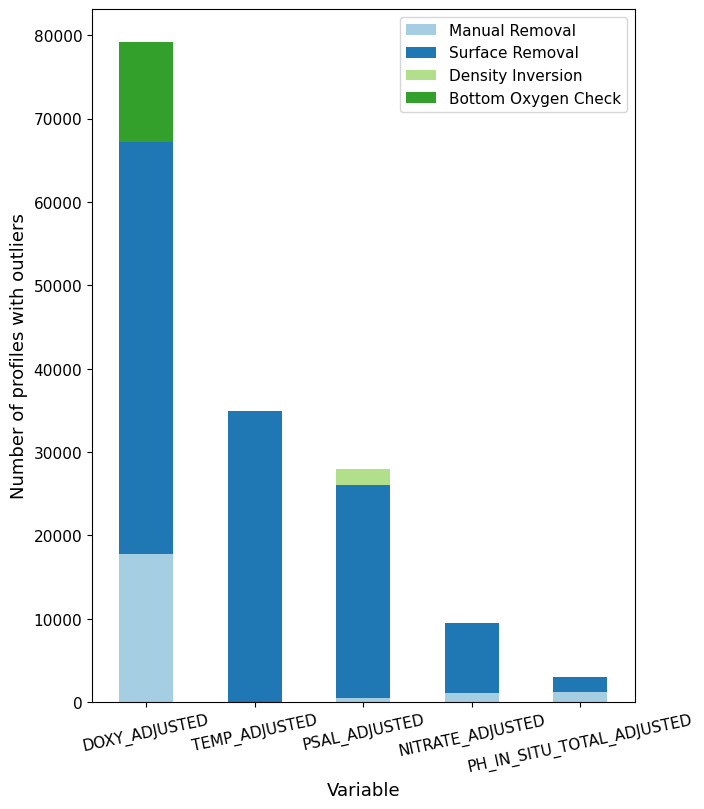

In [ ]:
deletion_reasons = cleaned_outlier_df['Deletion reason'].unique()
color_map = plt.get_cmap('Paired')
colors = [color_map(i) for i in np.arange(0, len(deletion_reasons))]

column_labels = []
column_labels.append('Variable')
for d in range(0, len(deletion_reasons)):
    column_labels.append(deletion_reasons[d])
print(column_labels)

font_size = 11
outliers_grouped_profiles = cleaned_outlier_df.drop_duplicates(['Float Number', 'Variable_base', 'N_PROF', 'Deletion reason'])[['Float Number', 'Variable_base', 'N_PROF', 'Deletion reason']]
fig = plt.figure(figsize=(7,9))
ax = fig.add_subplot(1,1,1)
plt.style.use('default')
data_frame_in = outliers_grouped_profiles
# number of variables removed by reason
total_outlier_counts_by_variable = data_frame_in["Variable_base"].value_counts()

variables_removed = total_outlier_counts_by_variable.keys().tolist()

# don't consider removals of 'TEMP', 'TEMP_ADJUSTED' or 'PSAL' 
variables_removed = [var for var in variables_removed if not (var=='TEMP' or var=='PSAL')]

# variables_removed = np.delete(variables_removed,

deletion_reasons = data_frame_in['Deletion reason'].unique()
reasons = np.zeros((len(variables_removed), len(deletion_reasons)))
for idx, var in enumerate(variables_removed):
    variable_outliers = data_frame_in['Deletion reason'][data_frame_in['Variable_base']==variables_removed[idx]].value_counts()
    outlier_types = variable_outliers.keys()

    for idx_r, reason in enumerate(deletion_reasons):
        if reason in outlier_types:
            reasons[idx, idx_r] = variable_outliers[reason]
    
# # find the index variable deletion_reasons that matches 'Time series'
# time_series_index = np.where(deletion_reasons == 'Time series')[0][0]
# profile_index = np.where(deletion_reasons == 'Profile')[0][0]
# # add the reasons count of time series to that of profile
# original_profile_count = reasons[:, profile_index].copy()
# reasons[:, profile_index] += reasons[:, time_series_index]

# remove the time series column
# reasons = np.delete(reasons, time_series_index, axis=1)
# column_labels = np.delete(column_labels, time_series_index+1) # +1 because the first column is 'Variable'
# column_labels[profile_index+1] = 'Manual removal' # change the name of the profile column to 'Profile' since we added the time series to it
# replace 'Bottom_Oxygen_Check' with 'Bottom Oxygen Check' in column labels
for i in range(len(column_labels)):
    if column_labels[i]=='Bottom_Oxygen_Check':
        column_labels[i] = 'Bottom Oxygen Check'
print(column_labels)

temp = []
temp.append(variables_removed[0])
for i in range(reasons.shape[1]):
    temp.append(reasons[0,i])
df_bar = pd.DataFrame([temp], columns=column_labels)
# pd.concat
for v in range(1, len(variables_removed)):
    temp = []
    temp.append(variables_removed[v])
    for i in range(reasons.shape[1]):
        temp.append(reasons[v,i])
    df_bar_n = pd.DataFrame([temp], columns=column_labels)
    df_bar = pd.concat((df_bar, df_bar_n))
# df_bar.drop(columns=['NaN'], inplace=True)
# df_bar.drop(columns=np.nan, inplace=True)

df_bar.plot(x='Variable', kind='bar', stacked=True, ax=ax, rot=12, color=colors)
# ax.bar(variables_removed, df_bar, stacked=True, rot=12)

# for p, color in zip(ax.patches, colors):
#     p.set_facecolor(color_map(0))
# plt.show()
# increase legend font size
ax.legend(fontsize=font_size)
# set y-axis to log scale
# ax.set_yscale('log')
ax.set_ylabel('Number of profiles with outliers', fontsize=font_size+2)
ax.set_xlabel('Variable', fontsize=font_size+2)
# increase font size
ax.tick_params(axis='both', which='major', labelsize=font_size)
# the figure is saving such that the x axis label is off the 
fig.savefig(group_manuscript_fig_dir + 'Fig_6_variables_removed_by_reason_n_profiles' + plot_ver + '.png', dpi=400)

In [214]:
# For each variable, print out the number of profiles with outliers removed for each reason
for idx, var in enumerate(variables_removed):
    print(f'Variable: {var}')
    variable_outliers = data_frame_in['Deletion reason'][data_frame_in['Variable_base']==variables_removed[idx]].value_counts()
    outlier_types = variable_outliers.keys()

    for idx_r, reason in enumerate(deletion_reasons):
        if reason in outlier_types:
            print(f'  Reason: {reason}, Profiles: {variable_outliers[reason]}')
            float_count = data_frame_in['Float Number'][(data_frame_in['Variable_base']==variables_removed[idx]) & (data_frame_in['Deletion reason']==reason)].nunique()
            print(f'  Reason: {reason}, Floats: {float_count}')

# # for each variable, print out the number of floats with outliers removed for each reason
# for idx, var in enumerate(variables_removed):
#     print(f'Variable: {var}')
#     variable_outliers = data_frame_in['Deletion reason'][data_frame_in['Variable_base']==variables_removed[idx]].value_counts()
#     outlier_types = variable_outliers.keys()

#     for idx_r, reason in enumerate(deletion_reasons):
#         if reason in outlier_types:
#             float_count = data_frame_in['Float Number'][(data_frame_in['Variable_base']==variables_removed[idx]) & (data_frame_in['Deletion reason']==reason)].nunique()
#             print(f'  Reason: {reason}, Floats: {float_count}')

Variable: DOXY_ADJUSTED
  Reason: Manual Removal, Profiles: 15743
  Reason: Manual Removal, Floats: 494
  Reason: Surface Removal, Profiles: 49298
  Reason: Surface Removal, Floats: 459
  Reason: Bottom_Oxygen_Check, Profiles: 11922
  Reason: Bottom_Oxygen_Check, Floats: 252
Variable: TEMP_ADJUSTED
  Reason: Manual Removal, Profiles: 36
  Reason: Manual Removal, Floats: 22
  Reason: Surface Removal, Profiles: 34579
  Reason: Surface Removal, Floats: 320
Variable: PSAL_ADJUSTED
  Reason: Manual Removal, Profiles: 506
  Reason: Manual Removal, Floats: 176
  Reason: Surface Removal, Profiles: 25197
  Reason: Surface Removal, Floats: 254
  Reason: Density Inversion, Profiles: 2004
  Reason: Density Inversion, Floats: 574
Variable: NITRATE_ADJUSTED
  Reason: Manual Removal, Profiles: 1029
  Reason: Manual Removal, Floats: 253
  Reason: Surface Removal, Profiles: 8053
  Reason: Surface Removal, Floats: 80
Variable: PH_IN_SITU_TOTAL_ADJUSTED
  Reason: Manual Removal, Profiles: 919
  Reason: M

# Table 2

In [10]:
# print the same information as in the cell above into a latex formatted table
print(r"\small")
print(r'\begin{center}')
print(r'\begin{table}')
print(r'\caption{Numbers of floats (profiles) with data removed for each variable and reason}')
print(r'\label{tab:floats_profiles_sensors_removal_reasons}')
print('\\begin{tabular}{l' + 'c' * len(deletion_reasons) + '}')
header_row = 'Variable'
for reason in deletion_reasons:
    if '_' in reason:
        reason = reason.replace('_', r' ')
    header_row += ' & ' + reason
header_row += ' \\\\ \\hline'
print(header_row)  

for idx, var in enumerate(variables_removed):
    if '_' in var:
        var = var.replace('_', r'\_')
    row = var
    variable_outliers = data_frame_in['Deletion reason'][data_frame_in['Variable_base']==variables_removed[idx]].value_counts()
    outlier_types = variable_outliers.keys()

    for idx_r, reason in enumerate(deletion_reasons):
        if reason in outlier_types:
            profile_count = variable_outliers[reason]
            float_count = data_frame_in['Float Number'][(data_frame_in['Variable_base']==variables_removed[idx]) & (data_frame_in['Deletion reason']==reason)].nunique()
        else:
            profile_count = 0
            float_count = 0
        row += ' & ' + f"{float_count:,d}" + ' (' + f"{profile_count:,d}" + ')'
    row += ' \\\\'
    print(row)
print(r'\end{tabular}')
print(r'\end{table}')
print(r'\end{center}')

\small
\begin{center}
\begin{table}
\caption{Numbers of floats (profiles) with data removed for each variable and reason}
\label{tab:floats_profiles_sensors_removal_reasons}
\begin{tabular}{lcccc}
Variable & Manual Removal & Surface Removal & Density Inversion & Bottom Oxygen Check \\ \hline
DOXY\_ADJUSTED & 506 (17,829) & 460 (49,422) & 0 (0) & 252 (11,922) \\
TEMP\_ADJUSTED & 22 (36) & 321 (34,933) & 0 (0) & 0 (0) \\
PSAL\_ADJUSTED & 179 (514) & 255 (25,550) & 564 (1,957) & 0 (0) \\
NITRATE\_ADJUSTED & 267 (1,107) & 81 (8,440) & 0 (0) & 0 (0) \\
PH\_IN\_SITU\_TOTAL\_ADJUSTED & 172 (1,231) & 76 (1,780) & 0 (0) & 0 (0) \\
\end{tabular}
\end{table}
\end{center}


## Find how many manual removals are the bottoms of profiles or the first profile


In [23]:
# duplicate manual / auto outliers are already removed, so I can proceed without doing that again
# to find profiles with bottom variables removed (but not entire profiles), I'll want to find variable removals at the bottom of a profile without the entire profile removed
# to do this I will need to either know the true bottom of the profile, or guess based on the pressure... the first will be more accurate, if slower. 
verbose = False

# add a bottom hook removal column to the cleaned_outlier_df of type string and fill with "unknown"
# cleaned_outlier_df['Bottom_hook_removal'] = False
# cleaned_outlier_df['First_profile_removal'] = False
# first, make a dataframe with only manual removals
manual_outlier_df = cleaned_outlier_df[cleaned_outlier_df['Deletion reason']=='Manual Removal']
# removed Temp and PSAL data, less concerned about bottom hooks with those
manual_outlier_df = manual_outlier_df[~manual_outlier_df['Variable_base'].isin(['PSAL_ADJUSTED', 'TEMP_ADJUSTED', 'TEMP', 'PSAL'])]
# manual_outlier_df

removed_wmos = manual_outlier_df['Float Number'].unique()
# removed_wmos
results = []

for idx, wmo_n in enumerate(tqdm(removed_wmos)):
    # wmo_n = removed_wmos[113]

    wmo_outlier_df = manual_outlier_df.where(manual_outlier_df['Float Number']==wmo_n).dropna(how='all')

    variables_needed = [var + '_BGCArgoPlus' for var in wmo_outlier_df['Variable_base'].unique()]
    variables_needed.append('N_LEVELS')
    
    argo_n_orig = xr.open_dataset(output_dir + str(int(wmo_n)) + '_Sprof_filtered.nc')[variables_needed]
    # open the original file for this float to get the pressure levels
    # argo_n_orig = xr.open_dataset(output_dir + str(int(wmo_n)) + '_Sprof_filtered.nc')
    # find the profiles where outliers are removed

    # Calculate all valid levels once per file
    valid_levels_cache = {}
    for var in wmo_outlier_df['Variable_base'].unique():
        var_data = argo_n_orig[var + '_BGCArgoPlus']
        valid_levels_cache[var] = {}
        for prof in range(var_data.shape[0]):
            var_valid = ~np.isnan(var_data[prof, :])
            if np.any(var_valid):
                valid_levels_cache[var][prof] = argo_n_orig['N_LEVELS'][var_valid].values
                
    for var in wmo_outlier_df['Variable_base'].unique():
        var_outliers_n_df = wmo_outlier_df.where(wmo_outlier_df['Variable_base']==var).dropna(how='all')
        profiles_removed = var_outliers_n_df['N_PROF'].unique()
        if verbose:
            print(f'{wmo_n}, {var}, {len(var_outliers_n_df)}, {len(profiles_removed)}')

        for prof_removed in profiles_removed:
            first_profile_removal = False

            n_prof_n = int(prof_removed)    
            if verbose:
                print(n_prof_n)
            
            levels_removed_for_var_profiles = var_outliers_n_df[var_outliers_n_df['N_PROF']==n_prof_n]['N_LEVELS'].values
            # if verbose:
                # print(len(levels_removed_for_var_profiles))
            # var_valid = ~np.isnan(argo_n_orig[var + '_BGCArgoPlus'][n_prof_n,:])
            # valid_var_levels_n = argo_n_orig['N_LEVELS'][var_valid].values
            valid_var_levels_n = valid_levels_cache[var].get(n_prof_n, np.array([]))
            if n_prof_n==0:
                if len(levels_removed_for_var_profiles)==len(valid_var_levels_n):
                    first_profile_removal = True
                    # cleaned_outlier_df.loc[(cleaned_outlier_df['Float Number']==wmo_n.item()) & 
                    #             (cleaned_outlier_df['N_PROF']==n_prof_n) & 
                    #             (cleaned_outlier_df['Variable_base']==var), 'First_profile_removal'] = True
            # check whether the levels listed for that profile are at the end of the profiles valid oxygen levels
            bottom_removed = False
            # for level in levels_removed_for_var_profiles:
            #     removal_mask = valid_var_levels_n==level
            #     if np.any(removal_mask):
            #         if valid_var_levels_n[removal_mask]==valid_var_levels_n[-1]:
            #             bottom_removed=True
            bottom_removed = np.any(np.isin(levels_removed_for_var_profiles, valid_var_levels_n[-1]))
            # if bottom_removed==True, check if all or most of the profile has been removed
            bottom_hook_removal = False
            if bottom_removed:
                if len(levels_removed_for_var_profiles)/len(valid_var_levels_n)<0.5:
                    bottom_hook_removal = True
            
            if np.logical_or(bottom_hook_removal, first_profile_removal):
                 results.append({
                    'Float Number': wmo_n,
                    'N_PROF': n_prof_n, 
                    'Variable_base': var,
                    'Bottom_hook_removal': bottom_hook_removal,
                    'First_profile_removal': first_profile_removal
                })
            # if verbose:
            #     print(bottom_hook_removal)
            # cleaned_outlier_df.loc[(cleaned_outlier_df['Float Number']==wmo_n.item()) & 
            #                     (cleaned_outlier_df['N_PROF']==n_prof_n) & 
            #                     (cleaned_outlier_df['Variable_base']==var), 'Bottom_hook_removal'] = bottom_hook_removal
        # if first_profile_found:
        #     print(wmo_n, var)
    argo_n_orig.close()
    # cleaned_outlier_df[cleaned_outlier_df['Float Number']==wmo_n.item()]

    # if idx>50:
    #     break

bottom_first_results_df = pd.DataFrame(results)
bottom_first_results_df

# if verbose:
#     print('applying updates')
# # Apply all updates at once
# for update in updates:
#     mask = ((cleaned_outlier_df['Float Number'] == update['wmo']) & 
#             (cleaned_outlier_df['N_PROF'] == update['n_prof']) & 
#             (cleaned_outlier_df['Variable_base'] == update['var']))
#     cleaned_outlier_df.loc[mask, 'Bottom_hook_removal'] = update['bottom_hook']
#     cleaned_outlier_df.loc[mask, 'First_profile_removal'] = update['first_profile']

100%|██████████| 746/746 [02:03<00:00,  6.04it/s]


,Float Number,N_PROF,Variable_base,Bottom_hook_removal,First_profile_removal
0,1900652.0,20,DOXY_ADJUSTED,True,False
1,1900652.0,30,DOXY_ADJUSTED,True,False
2,1900652.0,36,DOXY_ADJUSTED,True,False
3,1900652.0,38,DOXY_ADJUSTED,True,False
4,1900652.0,84,DOXY_ADJUSTED,True,False
...,...,...,...,...,...
17028,7901009.0,47,DOXY_ADJUSTED,True,False
17029,7901009.0,48,DOXY_ADJUSTED,True,False
17030,7901009.0,49,DOXY_ADJUSTED,True,False
17031,7901095.0,0,PH_IN_SITU_TOTAL_ADJUSTED,False,True


In [39]:
test = bottom_first_results_df.groupby('First_profile_removal')['Float Number'].unique()
print(bottom_first_results_df.groupby('First_profile_removal')['Float Number'].unique())
print(test)
test[1].size

First_profile_removal
False    [1900652.0, 1900722.0, 1900943.0, 1901134.0, 1...
True     [1902499.0, 1902648.0, 2900126.0, 2900127.0, 2...
Name: Float Number, dtype: object
First_profile_removal
False    [1900652.0, 1900722.0, 1900943.0, 1901134.0, 1...
True     [1902499.0, 1902648.0, 2900126.0, 2900127.0, 2...
Name: Float Number, dtype: object


/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_10187/1372958257.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test[1].size


102

In [24]:
# print numbers of first profiles removed for each variable:
print('Number of first profiles removed for each variable:')
print(bottom_first_results_df.groupby('Variable_base')['First_profile_removal'].sum())

Number of first profiles removed for each variable:
Variable_base
DOXY_ADJUSTED                20
NITRATE_ADJUSTED             53
PH_IN_SITU_TOTAL_ADJUSTED    49
Name: First_profile_removal, dtype: int64


In [40]:
# number of profiles with bottom hook removals for each variable:
print('Number of profiles with bottom hook removals for each variable:')
print(bottom_first_results_df.groupby('Variable_base')['Bottom_hook_removal'].sum())

Number of profiles with bottom hook removals for each variable:
Variable_base
DOXY_ADJUSTED                15978
NITRATE_ADJUSTED                73
PH_IN_SITU_TOTAL_ADJUSTED      860
Name: Bottom_hook_removal, dtype: int64


In [38]:
wmo_outlier_df = manual_outlier_df.where(manual_outlier_df['Float Number']==wmo_n).dropna(how='all')

# open the original file for this float to get the pressure levels
argo_n_orig = xr.open_dataset(output_dir + str(int(wmo_n)) + '_Sprof_filtered.nc')
# find the profiles where outliers are removed
for var in wmo_outlier_df['Variable_base'].values:
    var_outliers_n = wmo_outlier_df.where(wmo_outlier_df['Variable_base']==var).dropna(how='all')
    profiles_removed = var_outliers_n['N_PROF'].unique()
    
    for prof_removed in profiles_removed:
        n_prof_n = int(prof_removed)    
        if verbose:
            print(n_prof_n)
        
            
        levels_removed_for_var_profiles = var_outliers_n[var_outliers_n['N_PROF']==n_prof_n]['N_LEVELS'].values
        if verbose:
            print(levels_removed_for_var_profiles)
        var_valid = ~np.isnan(argo_n_orig[var + '_BGCArgoPlus'][n_prof_n,:])
        valid_var_levels_n = argo_n_orig['N_LEVELS'][var_valid].values
        
        if n_prof_n==0:
            first_profile_found = True
            if len(levels_removed_for_var_profiles)==len(valid_var_levels_n):
                cleaned_outlier_df.loc[(cleaned_outlier_df['Float Number']==wmo_n.item()) & 
                            (cleaned_outlier_df['N_PROF']==n_prof_n) & 
                            (cleaned_outlier_df['Variable_base']==var), 'First_profile_removal'] = True
        # check whether the levels listed for that profile are at the end of the profiles valid oxygen levels
        bottom_removed= False
        for level in levels_removed_for_var_profiles:
            removal_mask = valid_var_levels_n==level
            if np.any(removal_mask):
                if valid_var_levels_n[removal_mask]==valid_var_levels_n[-1]:
                    bottom_removed=True

        # if bottom_removed==True, check if all or most of the profile has been removed
        bottom_hook_removal = False
        if bottom_removed:
            if len(levels_removed_for_var_profiles)/len(valid_var_levels_n)<0.5:
                bottom_hook_removal = True
        if verbose:
            print(bottom_hook_removal)
        cleaned_outlier_df.loc[(cleaned_outlier_df['Float Number']==wmo_n.item()) & 
                            (cleaned_outlier_df['N_PROF']==n_prof_n) & 
                            (cleaned_outlier_df['Variable_base']==var), 'Bottom_hook_removal'] = bottom_hook_removal
    if first_profile_found:
        print(wmo_n, var)
    argo_n_orig.close()

KeyboardInterrupt: 

In [44]:
cleaned_outlier_df.loc[(cleaned_outlier_df['Float Number']==wmo_n.item()) & 
                                (cleaned_outlier_df['N_PROF']==n_prof_n) & 
                                (cleaned_outlier_df['Variable_base']==var), 'First_profile_removal'] = True

,Float Number,Variable,N_PROF,Date,N_LEVELS,Pressure (dbar),Deletion reason,Variable_short,Variable_base,Bottom_hook_removal,First_profile_removal
609735,7902101.0,PH_IN_SITU_TOTAL_ADJUSTED_RO,0.0,2024-06-26 17:05:13.001,0.0,4.160000,Manual Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,False,True
609736,7902101.0,PH_IN_SITU_TOTAL_ADJUSTED_RO,0.0,2024-06-26 17:05:13.001,1.0,5.960000,Manual Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,False,True
609737,7902101.0,PH_IN_SITU_TOTAL_ADJUSTED_RO,0.0,2024-06-26 17:05:13.001,2.0,7.860000,Manual Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,False,True
609738,7902101.0,PH_IN_SITU_TOTAL_ADJUSTED_RO,0.0,2024-06-26 17:05:13.001,3.0,9.960000,Manual Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,False,True
609739,7902101.0,PH_IN_SITU_TOTAL_ADJUSTED_RO,0.0,2024-06-26 17:05:13.001,4.0,12.259999,Manual Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,False,True
...,...,...,...,...,...,...,...,...,...,...,...
610217,7902101.0,PH_IN_SITU_TOTAL_ADJUSTED_RO,0.0,2024-06-26 17:05:13.001,482.0,967.859985,Manual Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,False,True
610218,7902101.0,PH_IN_SITU_TOTAL_ADJUSTED_RO,0.0,2024-06-26 17:05:13.001,483.0,969.859985,Manual Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,False,True
610219,7902101.0,PH_IN_SITU_TOTAL_ADJUSTED_RO,0.0,2024-06-26 17:05:13.001,484.0,971.859985,Manual Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,False,True
610220,7902101.0,PH_IN_SITU_TOTAL_ADJUSTED_RO,0.0,2024-06-26 17:05:13.001,485.0,973.859985,Manual Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,False,True


In [121]:
# check whether the levels listed for that profile are at the end of the profiles valid oxygen levens
bottom_removed= False
for level in levels_removed_for_var_profiles:
    removal_mask = valid_o2_levels_n==level
    if valid_o2_levels_n[removal_mask]==len(valid_o2_levels_n)-1:
        bottom_removed=True

# if bottom_removed==True, check if all or most of the profile has been removed

if bottom_removed:
    if len(levels_removed_for_var_profiles)/len(valid_o2_levels_n)>0.5:
        print('most of the profile removed, likely not a bottom hook removal')
        bottom_hook_removal = False
    else:
        print('only bottom levels removed, likely a bottom hook removal')
        bottom_hook_removal = True
# add bottom_hook_removal_info to original cleaned_outlier_df 


# for idx in cleaned_outlier_df.index:
#     if cleaned_outlier_df['Float Number'][idx]==wmo_n and cleaned_outlier_df['N_PROF'][idx]==n_prof_n and cleaned_outlier_df['Variable_base'][idx]==var:
#         cleaned_outlier_df.loc[idx, 'Bottom_hook_removal'] = bottom_hook_removal


only bottom levels removed, likely a bottom hook removal


In [ ]:
# add a bottom hook removal column to the cleaned_outlier_df of type string and fill with "unknown"
cleaned_outlier_df['Bottom_hook_removal'] = "unknown"

In [124]:
cleaned_outlier_df.loc[(cleaned_outlier_df['Float Number']==wmo_n.item()) & (cleaned_outlier_df['N_PROF']==n_prof_n) & (cleaned_outlier_df['Variable_base']==var), 'Bottom_hook_removal'] = bottom_hook_removal

In [125]:
cleaned_outlier_df[cleaned_outlier_df['Float Number']==wmo_n.item()]

,Float Number,Variable,N_PROF,Date,N_LEVELS,Pressure (dbar),Deletion reason,Variable_short,Variable_base,Bottom_hook_removal
8,1900652.0,DOXY_ADJUSTED_RO,20.0,2007-01-28 21:34:12.864,69.0,1999.699951,Manual Removal,DOXY_ADJUSTED,DOXY_ADJUSTED,True
9,1900652.0,DOXY_ADJUSTED_RO,30.0,2007-05-08 20:46:34.752,70.0,1999.400024,Manual Removal,DOXY_ADJUSTED,DOXY_ADJUSTED,unknown
10,1900652.0,DOXY_ADJUSTED_RO,36.0,2007-07-07 20:40:13.728,70.0,1999.599976,Manual Removal,DOXY_ADJUSTED,DOXY_ADJUSTED,unknown
11,1900652.0,DOXY_ADJUSTED_RO,38.0,2007-07-27 20:30:10.656,64.0,1999.099976,Manual Removal,DOXY_ADJUSTED,DOXY_ADJUSTED,unknown
12,1900652.0,DOXY_ADJUSTED_RO,84.0,2008-11-08 20:19:41.664,70.0,1999.300049,Manual Removal,DOXY_ADJUSTED,DOXY_ADJUSTED,unknown


In [ ]:
removal_mask = valid_o2_levels_n==levels_removed_for_var_profiles
valid_o2_levels_n[removal_mask]==len(valid_o2_levels_n)-1

array([ True])

In [213]:
# sort df_bar by the sum of each row, descending
# sum all rows except the first column
df_bar['Total'] = df_bar.iloc[:, 1:].sum(axis=1)
df_bar = df_bar.sort_values(by='Total', ascending=False)
# df_bar = df_bar.drop(columns=['Total'])
df_bar_plot = df_bar[df_bar['Total']>50]
df_bar_plot

,Project,PSAL_ADJUSTED_RO,DOXY_ADJUSTED_RO,TEMP_ADJUSTED_RO,NITRATE_ADJUSTED_RO,PH_IN_SITU_TOTAL_ADJUSTED_RO,Total
0,US ARGO PROJECT,110.0,3355.0,6.0,64.0,1.0,24752.0
0,Indian ARGO,0.0,2654.0,0.0,0.0,0.0,18578.0
0,Indian Argo,0.0,1360.0,0.0,0.0,0.0,9520.0
0,"UW, SOCCOM, Argo equivalent",70.0,190.0,9.0,358.0,559.0,8302.0
0,Argo Australia,67.0,623.0,3.0,0.0,2.0,4865.0
0,CHINA ARGO EQUIVALENT,5.0,527.0,0.0,0.0,0.0,3724.0
0,SOCLIM,7.0,514.0,4.0,0.0,0.0,3675.0
0,Uk-Bioargo,0.0,481.0,0.0,0.0,0.0,3367.0
0,Argo INDIA,22.0,432.0,1.0,0.0,0.0,3185.0
0,AMOP,0.0,364.0,0.0,0.0,0.0,2548.0


<Axes: xlabel='Project'>

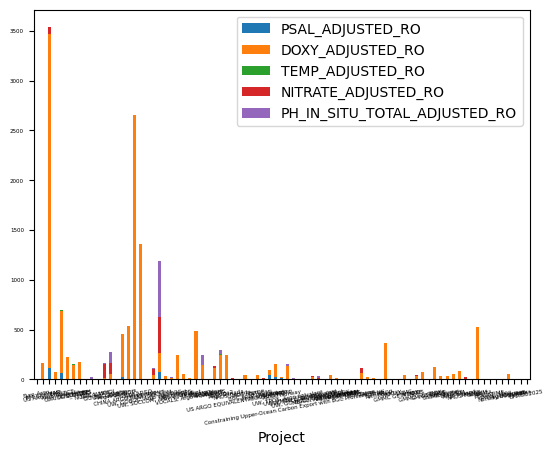

In [192]:
df_bar.plot(x=comparison_column, kind='bar', stacked=True, rot=10, fontsize=4)

In [ ]:
# new_df = outliers_all_df.drop_duplicates(['Float Number', 'N_PROF', 'Pressure (dbar)', 'Deletion reason'])[['Float Number', 'N_PROF', 'Pressure (dbar)', 'Deletion reason']]
deletion_reasons = cleaned_outlier_df['Deletion reason'].unique()

new_df = cleaned_outlier_df

pressure_bins = [-5, 10, 100, 200,300,400, 500, 750, 1000, 1250, 1500, 2000, 2500, 6000]

pressure_bin_labels = {}
for i in range(len(pressure_bins)-1):
    pressure_bin_labels[i] = f"{pressure_bins[i]}-{pressure_bins[i+1]}"
    
# create a new dataframe from new_df that bins the 'Pressure (dbar)' column into the pressure_bins
new_df['Pressure Bin'] = pd.cut(new_df['Pressure (dbar)'], bins=pressure_bins, labels=pressure_bin_labels)
new_df = new_df.drop_duplicates(['Float Number', 'N_PROF', 'Deletion reason', 'Pressure Bin'])[['Float Number', 'N_PROF', 'Deletion reason', 'Pressure Bin']]

# group by 'Pressure Bin' and 'Deletion reason' and count
grouped_df = new_df.groupby(['Pressure Bin', 'Deletion reason']).size().reset_index(name='Count')
grouped_df
# new_df


/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_36435/145854201.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = new_df.groupby(['Pressure Bin', 'Deletion reason']).size().reset_index(name='Count')


,Pressure Bin,Deletion reason,Count
0,0,Bottom_Oxygen_Check,0
1,0,Density Inversion,134
2,0,Manual Removal,1445
3,0,Surface Removal,63465
4,1,Bottom_Oxygen_Check,0
5,1,Density Inversion,1354
6,1,Manual Removal,1840
7,1,Surface Removal,0
8,2,Bottom_Oxygen_Check,160
9,2,Density Inversion,302


In [10]:
deletion_reasons

array(['Bottom_Oxygen_Check', 'Manual Removal'], dtype=object)

2      1445
6      1840
10      753
14     1007
18     1846
22      607
26      870
30     2711
34     1525
38      749
42    10986
46     1800
50       88
Name: Count, dtype: int64
3     63465
7         0
11        0
15        0
19        0
23        0
27        0
31        0
35        0
39        0
43        0
47        0
51        0
Name: Count, dtype: int64
1      134
5     1354
9      302
13     115
17      95
21      63
25      60
29      13
33       1
37       5
41       6
45       0
49       0
Name: Count, dtype: int64
0        0
4        0
8      160
12     177
16     143
20     120
24     201
28    3674
32    1422
36       0
40    5503
44     681
48     629
Name: Count, dtype: int64


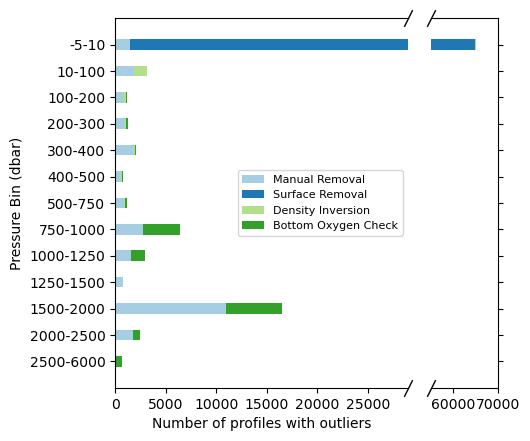

In [17]:
# loop through all deletion reasons and plot horizontal bar charts
# broken axis from: https://matplotlib.org/stable/gallery/subplots_axes_and_figures/broken_axis.html
# fig = plt.figure(figsize=(6,7))
# ax = fig.add_subplot(1,1,1)
color_map = plt.get_cmap('Paired')

colors = [color_map(i) for i in np.arange(0, len(deletion_reasons))]

count = grouped_df.loc[grouped_df['Deletion reason']=='Manual Removal', 'Count']
count.values

fig, (ax, ax2) = plt.subplots(1, 2, sharey=True)
fig.subplots_adjust(hspace=0.05)  # adjust space between Axes
plt.style.use('default')
left = np.zeros(len(count))
for idx, reason in enumerate(deletion_reasons):
    if type(reason)==float:
        continue
    count = grouped_df.loc[grouped_df['Deletion reason']==reason, 'Count']
    print(count)
    if '_' in reason:
        reason = reason.replace('_', ' ')   
    ax.barh(np.arange(0,len(count)), count.values,  height=0.4, label=reason, left=left, orientation='horizontal', color = colors[idx])
    ax2.barh(np.arange(0,len(count)), count.values,  height=0.4, label=reason, left=left, orientation='horizontal', color = colors[idx])

    left = left + count.values

ax.set_ylim(len(count), -1)
ax2.set_ylim(len(count), -1)

# replace y-tick labels with pressure bin labels
ax.set_yticks(np.arange(0,len(count)), pressure_bin_labels.values())
# ax2.set_yticks(np.arange(0,len(count)), pressure_bin_labels.values())

ax.set_xlabel('Number of profiles with outliers')
ax.set_ylabel('Pressure Bin (dbar)')
# shrink ax and increase size of ax1 to match
# make the size of ax larger
box = ax.get_position()
ax.set_position([box.x0+box.width*.2 , box.y0,
                 box.width*1.3, box.height])
# make the size of ax2 smaller
box = ax2.get_position()
ax2.set_position([box.x0+box.width*.4, box.y0,
                 box.width*.3, box.height])
ax.set_xlim(0, 29000)
ax2.set_xlim(55000, 70000)
ax.spines.right.set_visible(False)
ax2.spines.left.set_visible(False)
ax2.yaxis.tick_right()
ax2.tick_params(labelleft=False)  # don't put tick labels at the top
# ax2.yaxis.tick_left()
d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-d, -1), (d, 1)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax.plot([1, 1], [1, 0], transform=ax.transAxes, **kwargs)
ax2.plot([0, 0], [1, 0], transform=ax2.transAxes, **kwargs)


# add a break in the x-axis between 30000 and 70000
ax.legend(loc='right', fontsize=8)
# save figure
fig.savefig(manuscript_figs + 'outliers_by_pressure_bin' + plot_ver + '.png', dpi=300)

## Match outliers and float metadata

In [9]:
float_meta_df = pd.read_csv(manuscript_dir + "Dataset paper group folder/Data/float_outlier_meta.csv")
float_meta_df
# outliers_all_df.loc[outliers_all_df['Deletion reason']=='Profile', "Deletion reason"] ='Manual Removal'
# outliers_all_df.loc[outliers_all_df['Deletion reason']=='Time series', "Deletion reason"] ='Manual Removal'
# outliers_all_df

,Unnamed: 0,Float Number,Project,Deployment_Date,Dep_Lat,Dep_Lon,Last_Date,Data_Centre,N_PROF,DOXY_MODEL,...,PSAL_mode_D,DOXY_mode_R,DOXY_mode_A,DOXY_mode_D,NITRATE_mode_R,NITRATE_mode_A,NITRATE_mode_D,PH_IN_SITU_TOTAL_mode_R,PH_IN_SITU_TOTAL_mode_A,PH_IN_SITU_TOTAL_mode_D
0,0,5906043,"UW, TPOS, Argo eqivalent",2019-10-08 02:51:47.000288768,4.9850,-139.8730,2022-07-10 16:41:15.001776128,AO,200,AANDERAA_OPTODE_4330,...,200,0.0,0.0,200.0,NaN,NaN,NaN,0.0,0.0,200.0
1,1,2901557,CHINA ARGO EQUIVALENT,2014-03-27 02:54:02.000000512,29.4530,147.6960,2015-06-08 02:57:02.000000000,HZ,431,AANDERAA_OPTODE_4330,...,0,0.0,0.0,431.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1902594,NAOS,2023-06-15 22:15:56.999995904,5.3364,79.9727,2024-12-17 20:11:38.003614720,IF,66,AANDERAA_OPTODE_4330,...,0,0.0,61.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,3,5906524,"UW, SOCCOM",2022-05-20 10:11:50.001088512,-41.9080,27.7680,2024-11-02 23:33:50.002515456,AO,84,AANDERAA_OPTODE_4330,...,78,0.0,0.0,84.0,0.0,0.0,84.0,0.0,0.0,84.0
4,4,5901450,US ARGO PROJECT,2007-09-25 13:06:11.001430016,-67.4570,-89.9370,2010-07-17 13:03:10.005111296,AO,145,SBE43F_IDO,...,145,0.0,0.0,145.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2224,2224,3902590,Argo France,2024-06-04 12:37:00.000000000,44.9969,-18.4590,2024-12-23 08:57:00.000000000,IF,22,AANDERAA_OPTODE_4330,...,0,22.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2225,2225,4902624,Argo Canada,2024-06-30 04:57:00.000000000,NaN,NaN,2024-12-18 13:32:00.000000000,ME,34,AANDERAA_OPTODE_4330,...,0,34.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2226,2226,5900958,US ARGO PROJECT,2005-08-06 11:21:13.000714496,21.6270,-157.1560,2005-08-17 13:23:43.003570688,AO,3,SBE43_IDO,...,3,0.0,0.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
2227,2227,6902964,CORIOLIS,2020-02-06 01:39:00.000000000,7.9154,-53.5621,2022-07-14 02:21:29.999999744,IF,170,AANDERAA_OPTODE_4330,...,160,0.0,170.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# outliers of different types vs DACs, float type, etc. Would be nice to know what the deal is with surface removal and bottom oxygen checks
# to do this, need to load float files (processed should have the relevant info) and merge with outlier dataframe
# then can plot outliers by different categories
# use "float_meta_df from above"

# add columns to outliers_all_df for Project, Data_Centre, DOXY_MODEL, NITRATE_MODEL, PH_MODEL, Deployment_Date, Dep_Lat, Dep_Lon, Last_Date
# first create a dataframe from float_meta_df with only the relevant columns
float_meta_reduced = float_meta_df[["Float Number", "Project", "Data_Centre", "DOXY_MODEL", "NITRATE_MODEL", "PH_MODEL", "Deployment_Date", "Dep_Lat", "Dep_Lon", "Last_Date"]]

outliers_meta_df = cleaned_outlier_df.copy()

outliers_meta_df["Float Number"] = outliers_meta_df["Float Number"].astype('Int64')  # pandas nullable integer
float_meta_reduced["Float Number"] = float_meta_reduced["Float Number"].astype('Int64')


outliers_meta_df["Float Number"] = outliers_meta_df["Float Number"].astype(str)
float_meta_reduced["Float Number"] = float_meta_reduced["Float Number"].astype(str)

# outliers_all_df.rename(columns={"Float Number": "Float Number"}, inplace=True)
merged_outlier_df = pd.merge(outliers_meta_df, float_meta_reduced, on=["Float Number"], how='left')
merged_outlier_df   

/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_10502/3551340226.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  float_meta_reduced["Float Number"] = float_meta_reduced["Float Number"].astype('Int64')
/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_10502/3551340226.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  float_meta_reduced["Float Number"] = float_meta_reduced["Float Number"].astype(str)


,Float Number,Variable,N_PROF,Date,N_LEVELS,Pressure (dbar),Deletion reason,Variable_short,Variable_base,Project,Data_Centre,DOXY_MODEL,NITRATE_MODEL,PH_MODEL,Deployment_Date,Dep_Lat,Dep_Lon,Last_Date
0,1900650,PSAL_ADJUSTED,74.0,2008-08-09 00:09:20.736,55.0,798.799988,Manual Removal,PSAL_ADJUSTED,PSAL_ADJUSTED,Euro-Argo,IF,AANDERAA_OPTODE_3830,NaN,NaN,2006-06-20 23:40:01.632000000,3.8920,-34.2760,2010-03-12 00:23:41.280000000
1,1900651,PSAL_ADJUSTED_RO,41.0,2007-09-01 18:48:46.368,18.0,89.500000,Manual Removal,PSAL_ADJUSTED,PSAL_ADJUSTED,IFM-GEOMAR,IF,AANDERAA_OPTODE_3830,NaN,NaN,2006-07-08 20:02:34.368000000,-0.8160,-21.8530,2009-11-19 20:29:42.144000000
2,1900651,PSAL_ADJUSTED_RO,42.0,2007-09-11 20:19:12.288,13.0,59.400002,Manual Removal,PSAL_ADJUSTED,PSAL_ADJUSTED,IFM-GEOMAR,IF,AANDERAA_OPTODE_3830,NaN,NaN,2006-07-08 20:02:34.368000000,-0.8160,-21.8530,2009-11-19 20:29:42.144000000
3,1900651,PSAL_ADJUSTED_RO,91.0,2009-01-13 20:29:51.648,0.0,4.700000,Manual Removal,PSAL_ADJUSTED,PSAL_ADJUSTED,IFM-GEOMAR,IF,AANDERAA_OPTODE_3830,NaN,NaN,2006-07-08 20:02:34.368000000,-0.8160,-21.8530,2009-11-19 20:29:42.144000000
4,1900651,PSAL_ADJUSTED_RO,91.0,2009-01-13 20:29:51.648,1.0,6.600000,Manual Removal,PSAL_ADJUSTED,PSAL_ADJUSTED,IFM-GEOMAR,IF,AANDERAA_OPTODE_3830,NaN,NaN,2006-07-08 20:02:34.368000000,-0.8160,-21.8530,2009-11-19 20:29:42.144000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563987,7902112,TEMP_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,0.0,0.900000,Surface Removal,TEMP_ADJUSTED,TEMP_ADJUSTED,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464
563988,7902112,TEMP_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,1.0,1.800000,Surface Removal,TEMP_ADJUSTED,TEMP_ADJUSTED,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464
563989,7902112,PSAL_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,0.0,0.900000,Surface Removal,PSAL_ADJUSTED,PSAL_ADJUSTED,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464
563990,7902112,PSAL_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,1.0,1.800000,Surface Removal,PSAL_ADJUSTED,PSAL_ADJUSTED,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464


       Float Number                      Variable  N_PROF  \
0           1900650                 PSAL_ADJUSTED    74.0   
4           1900651              PSAL_ADJUSTED_RO    41.0   
5           1900651              PSAL_ADJUSTED_RO    42.0   
6           1900651              PSAL_ADJUSTED_RO    91.0   
8           1900652              DOXY_ADJUSTED_RO    20.0   
...             ...                           ...     ...   
771988      7901095  PH_IN_SITU_TOTAL_ADJUSTED_RO     0.0   
772500      7901097              PSAL_ADJUSTED_RO     3.0   
772513      7901103  PH_IN_SITU_TOTAL_ADJUSTED_RO    13.0   
772558      7902101  PH_IN_SITU_TOTAL_ADJUSTED_RO     0.0   
773441      7902122           NITRATE_ADJUSTED_RO     5.0   

                  DOXY_MODEL  
0       AANDERAA_OPTODE_3830  
4       AANDERAA_OPTODE_3830  
5       AANDERAA_OPTODE_3830  
6       AANDERAA_OPTODE_3830  
8       AANDERAA_OPTODE_3830  
...                      ...  
771988          SBE63_OPTODE  
772500          SBE

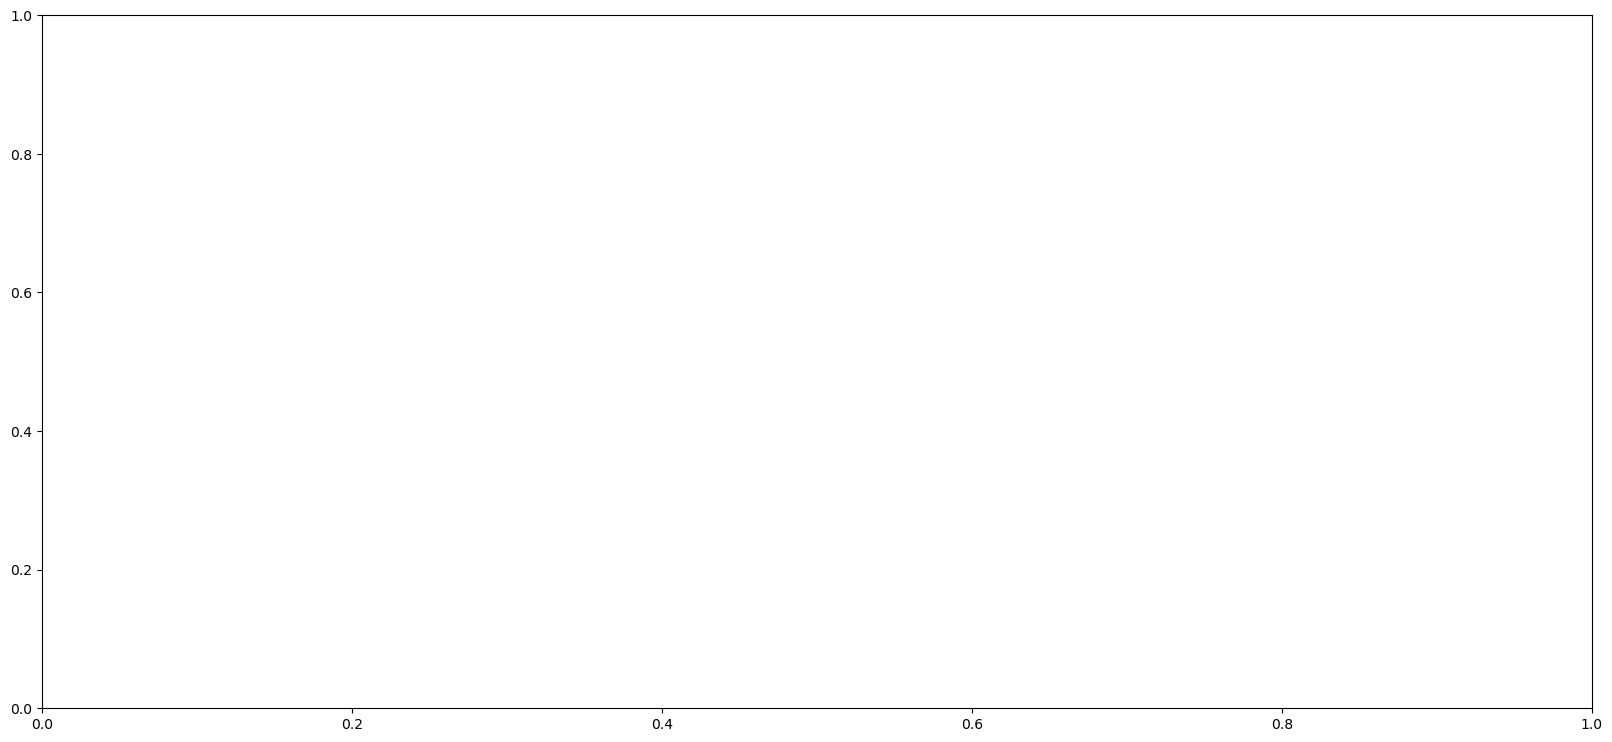

In [ ]:
filter_column = 'Deletion reason'
comparison_column = 'DOXY_MODEL'
# comparison_column = 'Data_Centre'
font_size = 8

merged_outlier_df[filter_column].unique()
n_cutoff = 50
for filter_type in merged_outlier_df[filter_column].unique():
    # if type(filter_type)==float:
    #     continue
    filter_df = merged_outlier_df[merged_outlier_df[filter_column]==filter_type]
    # # plot a bar chart of the number of outliers by deletion reason
    # fig = plt.figure(figsize=(10,6))
    # ax = fig.add_subplot(1,1,1)
    # total_outlier_counts_by_reason = filter_df["Deletion reason"].value_counts()
    # total_outlier_counts_by_reason.plot(kind='bar', title='Number of outliers by deletion reason for ' + filter_column + ': ' + str(project), ax=ax)
    # ax.set_ylabel('Number of outliers')
    # ax.set_xlabel('Deletion reason')
    # plt.xticks(rotation=45, ha='right')
    # plt.tight_layout()
    # fig.savefig(manuscript_figs + 'outliers_by_deletion_reason_' + filter_column + '_' + str(project).replace(' ', '_') + plot_ver + '.png', dpi=300)
    # # plt.close(fig)  
    
    # merged_outlier_df.drop_duplicates(['Float Number', 'Variable', 'N_PROF', 'Deletion reason'])[['Float Number', 'Variable', 'N_PROF', 'Deletion reason']]
    # filter_df

    # variable_list = filter_df['Variable'].unique()
    variable_list = []
    variable_list.append(comparison_column)
    for d in range(0, len(filter_df['Variable'].unique())):
        variable_list.append(filter_df['Variable'].unique()[d])
    # print(variable_list)
    variable_list = [var for var in variable_list if not (var=='TEMP' or var=='TEMP_ADJUSTED' or var=='PSAL' or var=='PSAL_ADJUSTED')]
    # print(variable_list)


    outliers_grouped_profiles = filter_df.drop_duplicates(['Float Number', 'Variable', 'N_PROF', comparison_column])[['Float Number', 'Variable', 'N_PROF', comparison_column]]
    print(outliers_grouped_profiles)
    
    fig = plt.figure(figsize=(20,9))
    ax = fig.add_subplot(1,1,1)
    plt.style.use('default')
    data_frame_in = outliers_grouped_profiles
    # number of variables removed by reason
    # total_outlier_counts_by_comparison = data_frame_in["Variable"].value_counts()

    # variables_removed = total_outlier_counts_by_variable.keys().tolist()

    # # don't consider removals of 'TEMP', 'TEMP_ADJUSTED' or 'PSAL' 
    # variables_removed = [var for var in variables_removed if not (var=='TEMP' or var=='TEMP_ADJUSTED' or var=='PSAL' or var=='PSAL_ADJUSTED')]

    # variables_removed = np.delete(variables_removed,

    comparison_types = data_frame_in[comparison_column].unique()
    comparison_array = np.zeros((len(variable_list), len(comparison_types)))
    for idx, comp in enumerate(comparison_types):
        # variable_outliers = data_frame_in[comparison_column][data_frame_in['Variable']==variables_removed[idx]].value_counts()
        # outlier_types = variable_outliers.keys()
        variable_counts_per_comp = data_frame_in['Variable'][data_frame_in[comparison_column]==comp].value_counts()
        variable_types = variable_counts_per_comp.keys()

        for idx_r, var in enumerate(variable_list):
            if var in variable_types:
                comparison_array[idx_r, idx] = variable_counts_per_comp[var]
    
    # # find the index variable deletion_reasons that matches 'Time series'
    # time_series_index = np.where(deletion_reasons == 'Time series')[0][0]
    # profile_index = np.where(deletion_reasons == 'Profile')[0][0]
    # # add the reasons count of time series to that of profile
    # original_profile_count = reasons[:, profile_index].copy()
    # reasons[:, profile_index] += reasons[:, time_series_index]

    # remove the time series column
    # reasons = np.delete(reasons, time_series_index, axis=1)
    # column_labels = np.delete(column_labels, time_series_index+1) # +1 because the first column is 'Variable'
    # column_labels[profile_index+1] = 'Manual removal' # change the name of the profile column to 'Profile' since we added the time series to it
    print(column_labels)

    # get the data into a dataframe, add the names of the comparison types to the column labels
    temp = []
    if len(comparison_types)==0:
        continue
    temp.append(comparison_types[0])
    for i in range(1, comparison_array.shape[0]):
        temp.append(comparison_array[i,0])
    df_bar = pd.DataFrame([temp], columns=variable_list)
    print(df_bar)
    
    for c in range(1, len(comparison_types)):
        temp = []
        temp.append(comparison_types[c])
        for i in range(1, comparison_array.shape[0]):
            temp.append(comparison_array[i,c])
        df_bar_n = pd.DataFrame([temp], columns=variable_list)
        df_bar = pd.concat((df_bar, df_bar_n))
    # break
    # df_bar.drop(columns=['NaN'], inplace=True)
    # df_bar.drop(columns=np.nan, inplace=True)
    df_bar['Total'] = df_bar.iloc[:, 1:].sum(axis=1)
    df_bar = df_bar.sort_values(by='Total', ascending=False)
    df_bar_plot = df_bar[df_bar['Total']>n_cutoff]

    df_bar_plot = df_bar_plot.drop(columns=['Total'])
    df_bar_plot.plot(x=comparison_column, kind='bar', stacked=True, rot=90, fontsize=4, ax=ax)
    # df_bar.T.plot(x=comparison_column, kind='bar', stacked=True, ax=ax, rot=10, colormap='tab20c')
    # increase legend font size
    ax.legend(fontsize=font_size)
    # set y-axis to log scale
    # ax.set_yscale('log')
    ax.set_ylabel('Number of profiles with outliers', fontsize=font_size+2)
    ax.set_xlabel('Variable Name', fontsize=font_size+2)
    # increase font size
    ax.tick_params(axis='both', which='major', labelsize=font_size)
    ax.set_title(filter_column + ': "' + filter_type + '", only showing ' + comparison_column + ' with > ' + str(n_cutoff) + ' profiles with outliers', fontsize=font_size+2)
    # shift the figure upward so that the x-axis label is not cut off
    plt.subplots_adjust(bottom=0.2)
    filter_name =     filter_type.replace('/', '_')
    
    fig.savefig(manuscript_figs + 'variables_removed_by_' + comparison_column + '_' + filter_column + '_' + str(filter_name).replace(' ', '_') + plot_ver + '.png', dpi=300)
    # break
    plt.close(fig)  

In [246]:
np.datetime64(merged_outlier_df['Date'].values[41696])

numpy.datetime64('2016-03-25T03:42:00.000')

### Outlier bar plots by deployment year

In [245]:
# outliers of each type relative to deployment date
merged_outlier_df['pd Date'] = pd.to_datetime(merged_outlier_df['Deployment_Date'], errors='coerce')
merged_outlier_df

,Float Number,Variable,N_PROF,Date,N_LEVELS,Pressure (dbar),Deletion reason,Variable_short,unique_id,Variable_base,...,Project,Data_Centre,DOXY_MODEL,NITRATE_MODEL,PH_MODEL,Deployment_Date,Dep_Lat,Dep_Lon,Last_Date,pd Date
0,1900650,PSAL_ADJUSTED,74.0,2008-08-09 00:09:20.736,55.0,798.799988,Manual Removal,PSAL_ADJUSTED,1900650.0_PSAL_ADJUSTED_74.0_55.0,PSAL_ADJUSTED,...,Euro-Argo,IF,AANDERAA_OPTODE_3830,NaN,NaN,2006-06-20 23:40:01.632000000,3.8920,-34.2760,2010-03-12 00:23:41.280000000,2006-06-20 23:40:01.632000000
1,1900651,PSAL_ADJUSTED_RO,41.0,2007-09-01 18:48:46.368,18.0,89.500000,Manual Removal,PSAL_ADJUSTED,1900651.0_PSAL_ADJUSTED_41.0_18.0,PSAL_ADJUSTED,...,IFM-GEOMAR,IF,AANDERAA_OPTODE_3830,NaN,NaN,2006-07-08 20:02:34.368000000,-0.8160,-21.8530,2009-11-19 20:29:42.144000000,2006-07-08 20:02:34.368000000
2,1900651,PSAL_ADJUSTED_RO,42.0,2007-09-11 20:19:12.288,13.0,59.400002,Manual Removal,PSAL_ADJUSTED,1900651.0_PSAL_ADJUSTED_42.0_13.0,PSAL_ADJUSTED,...,IFM-GEOMAR,IF,AANDERAA_OPTODE_3830,NaN,NaN,2006-07-08 20:02:34.368000000,-0.8160,-21.8530,2009-11-19 20:29:42.144000000,2006-07-08 20:02:34.368000000
3,1900651,PSAL_ADJUSTED_RO,91.0,2009-01-13 20:29:51.648,0.0,4.700000,Manual Removal,PSAL_ADJUSTED,1900651.0_PSAL_ADJUSTED_91.0_0.0,PSAL_ADJUSTED,...,IFM-GEOMAR,IF,AANDERAA_OPTODE_3830,NaN,NaN,2006-07-08 20:02:34.368000000,-0.8160,-21.8530,2009-11-19 20:29:42.144000000,2006-07-08 20:02:34.368000000
4,1900651,PSAL_ADJUSTED_RO,91.0,2009-01-13 20:29:51.648,1.0,6.600000,Manual Removal,PSAL_ADJUSTED,1900651.0_PSAL_ADJUSTED_91.0_1.0,PSAL_ADJUSTED,...,IFM-GEOMAR,IF,AANDERAA_OPTODE_3830,NaN,NaN,2006-07-08 20:02:34.368000000,-0.8160,-21.8530,2009-11-19 20:29:42.144000000,2006-07-08 20:02:34.368000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552590,7902112,TEMP_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,0.0,0.900000,Surface Removal,TEMP_ADJUSTED,7902112.0_TEMP_ADJUSTED_33.0_0.0,TEMP_ADJUSTED,...,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464,2024-07-10 20:16:44.002168832
552591,7902112,TEMP_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,1.0,1.800000,Surface Removal,TEMP_ADJUSTED,7902112.0_TEMP_ADJUSTED_33.0_1.0,TEMP_ADJUSTED,...,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464,2024-07-10 20:16:44.002168832
552592,7902112,PSAL_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,0.0,0.900000,Surface Removal,PSAL_ADJUSTED,7902112.0_PSAL_ADJUSTED_33.0_0.0,PSAL_ADJUSTED,...,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464,2024-07-10 20:16:44.002168832
552593,7902112,PSAL_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,1.0,1.800000,Surface Removal,PSAL_ADJUSTED,7902112.0_PSAL_ADJUSTED_33.0_1.0,PSAL_ADJUSTED,...,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464,2024-07-10 20:16:44.002168832


PSAL_ADJUSTED
Manual Removal


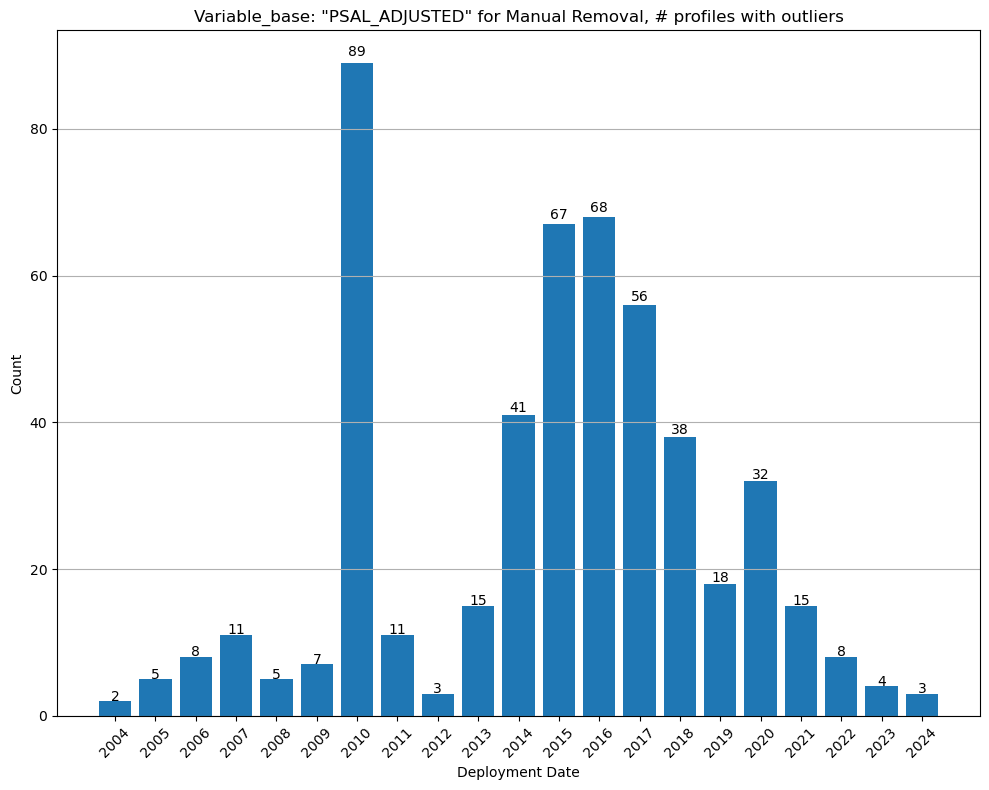

Density Inversion


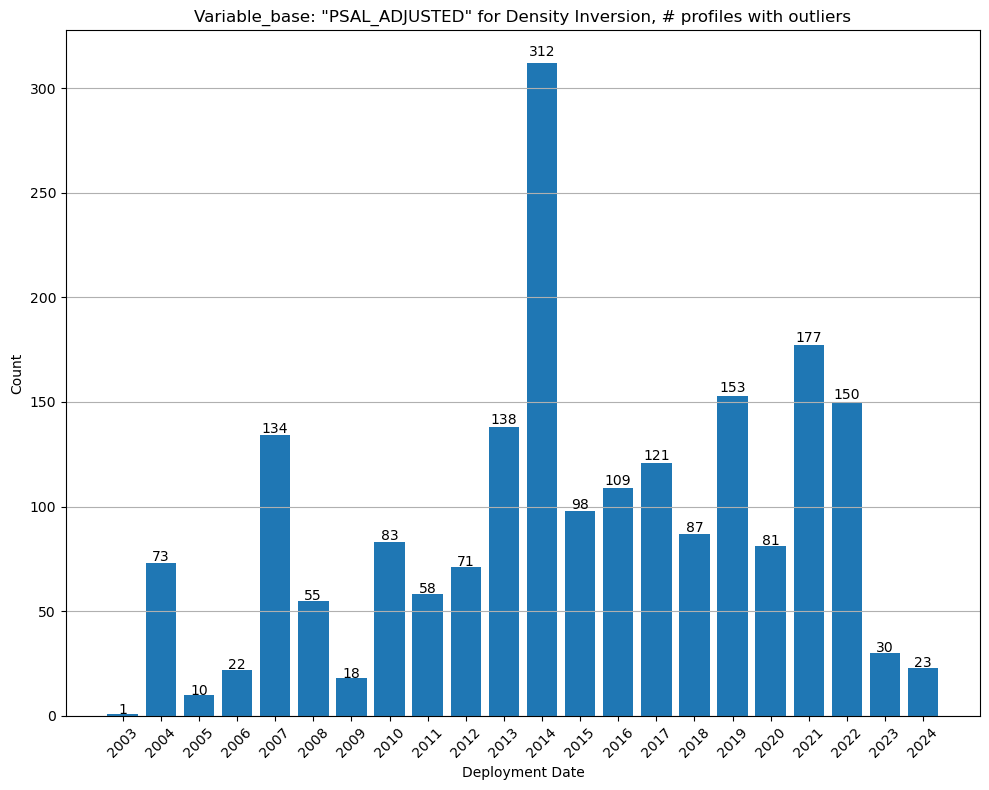

Surface Removal


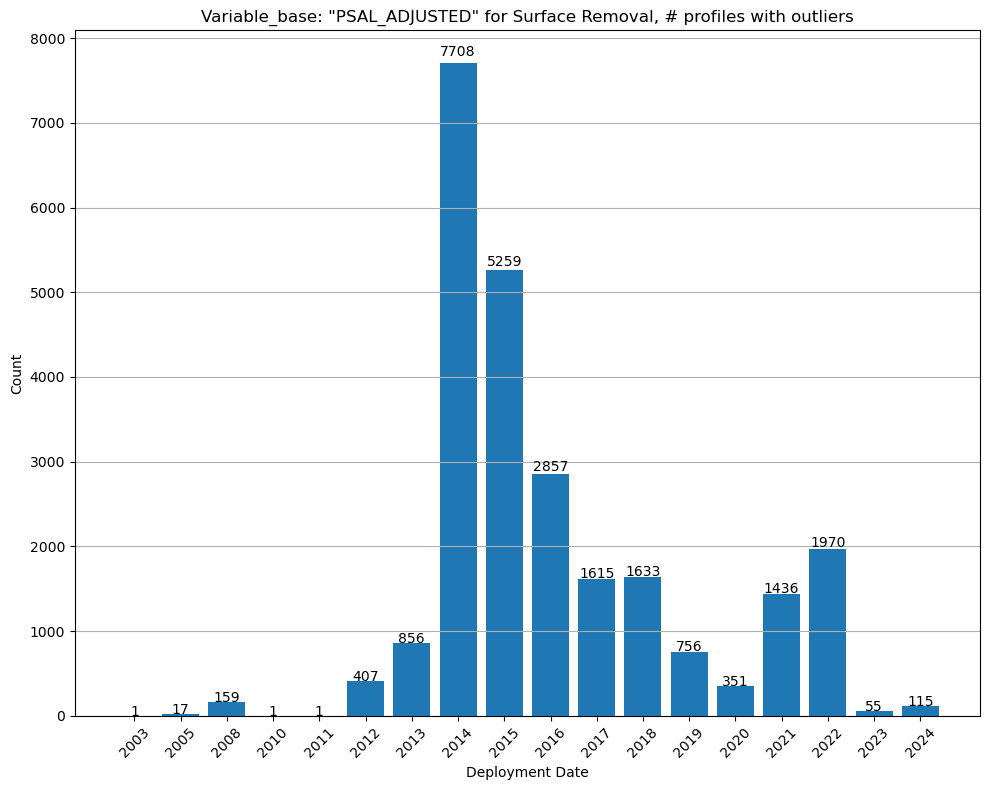

DOXY_ADJUSTED
Manual Removal


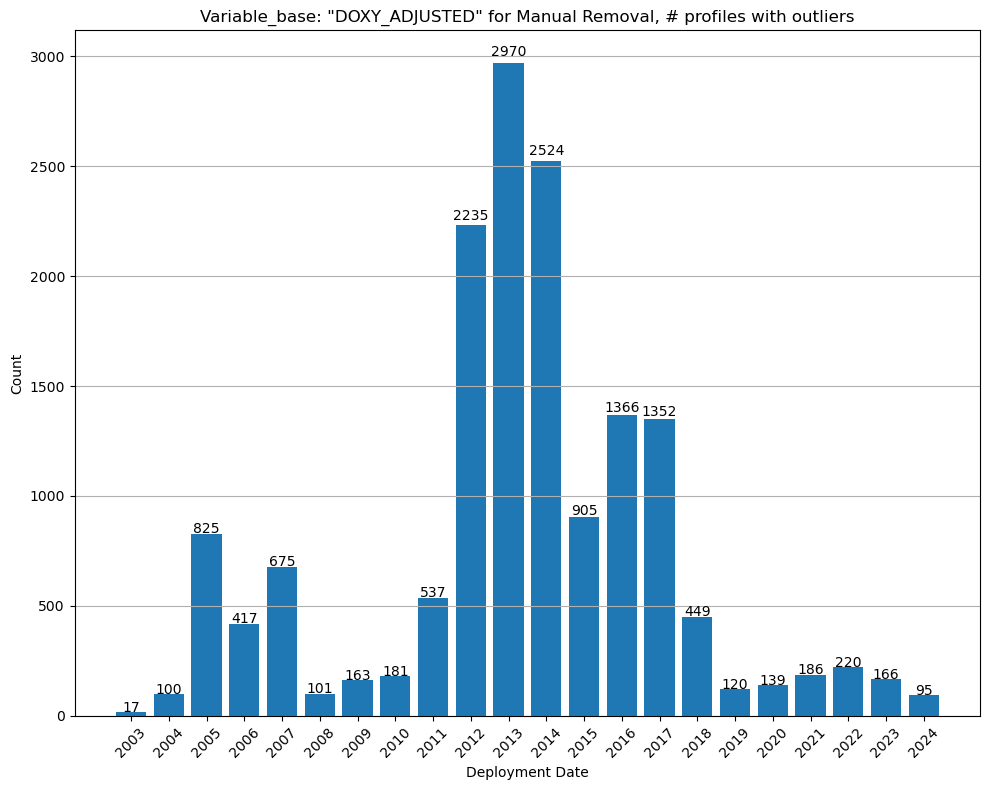

Surface Removal


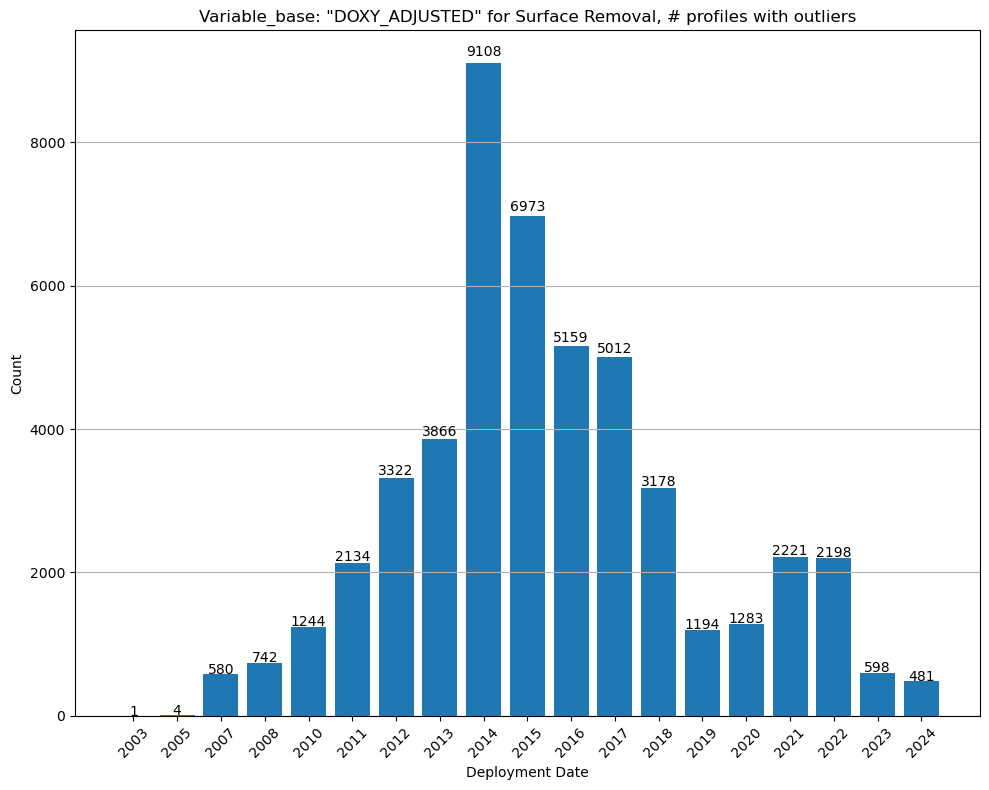

Bottom_Oxygen_Check


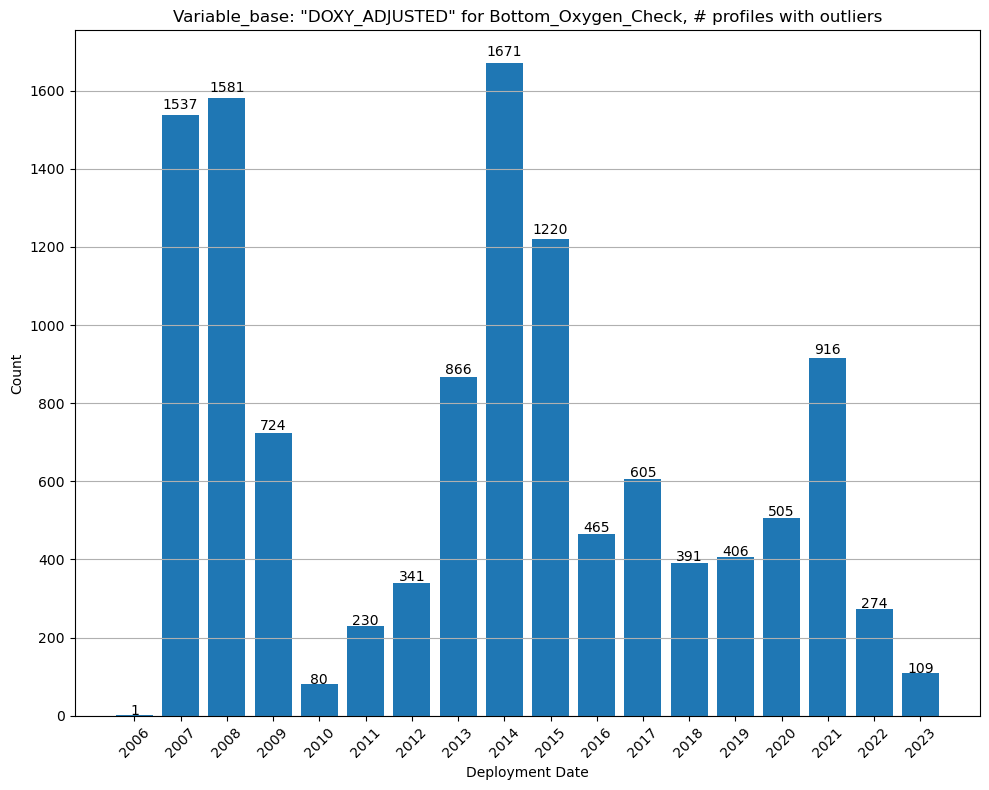

TEMP_ADJUSTED
Manual Removal


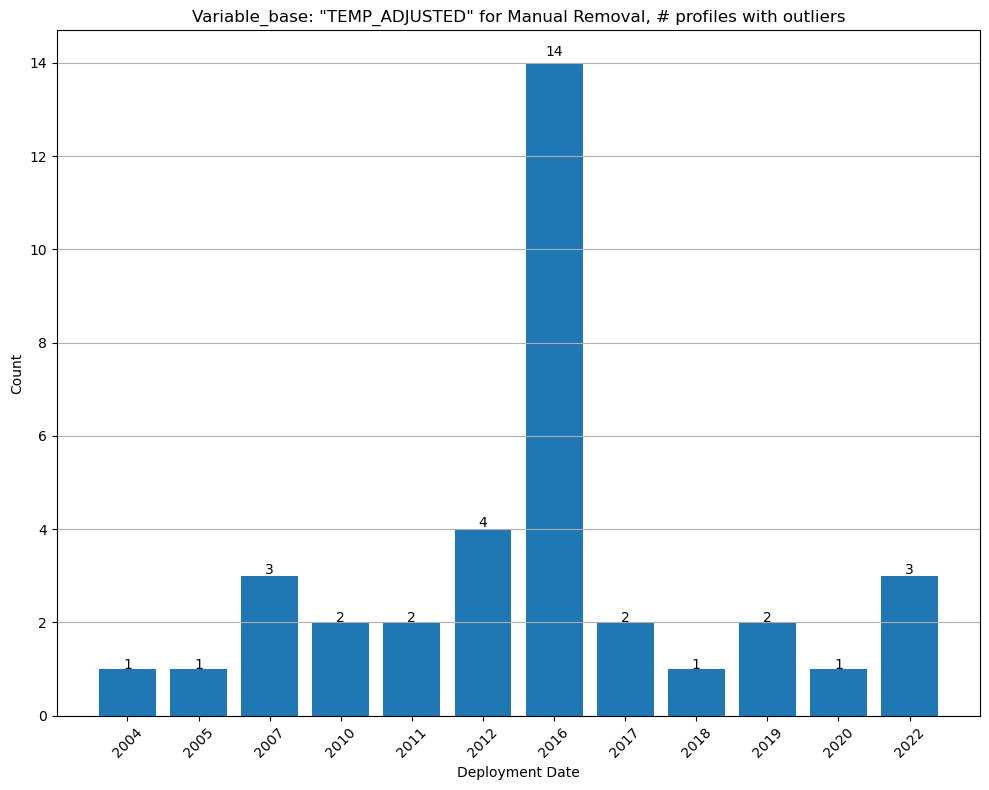

Surface Removal


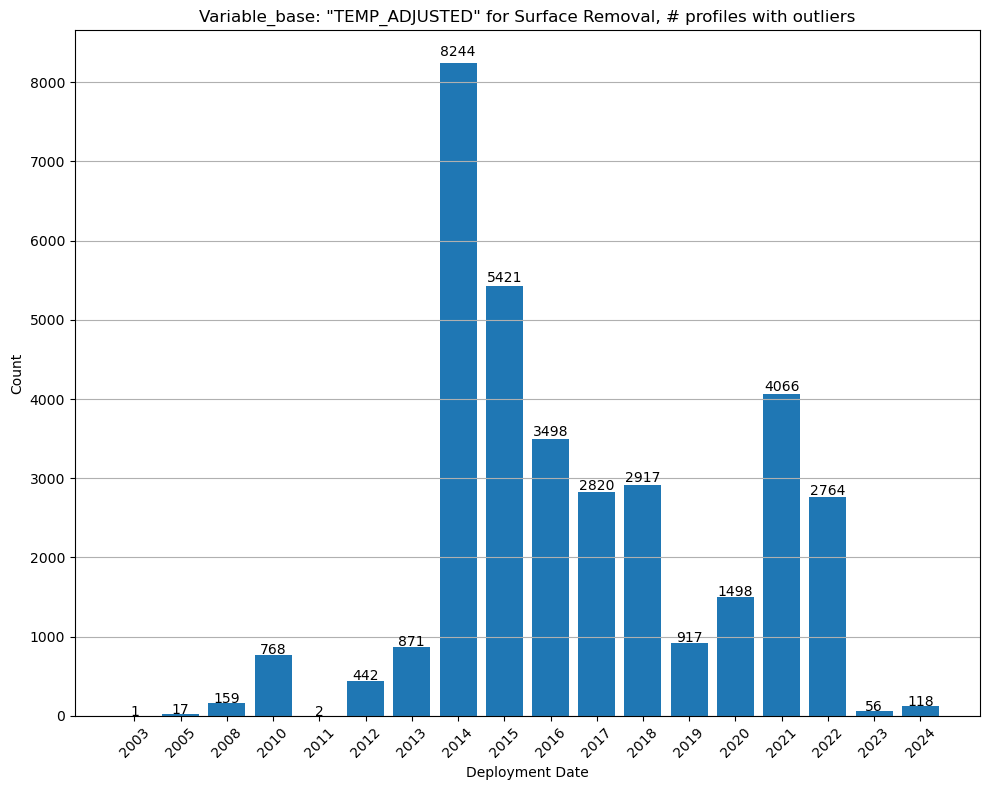

NITRATE_ADJUSTED
Manual Removal


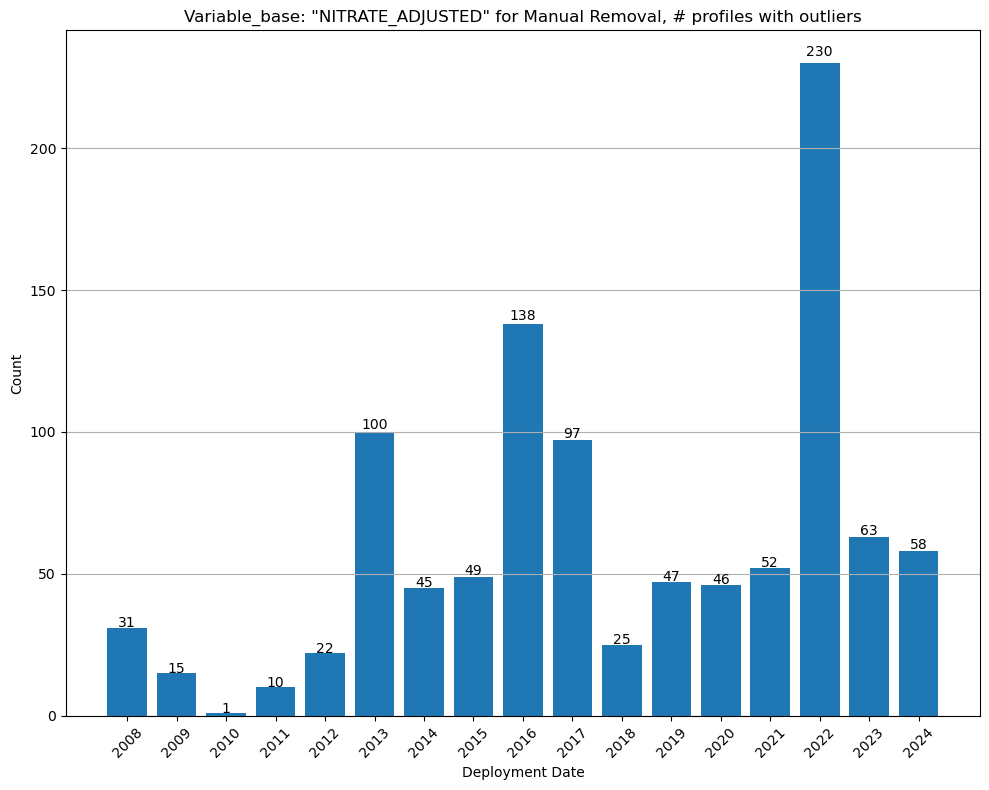

Surface Removal


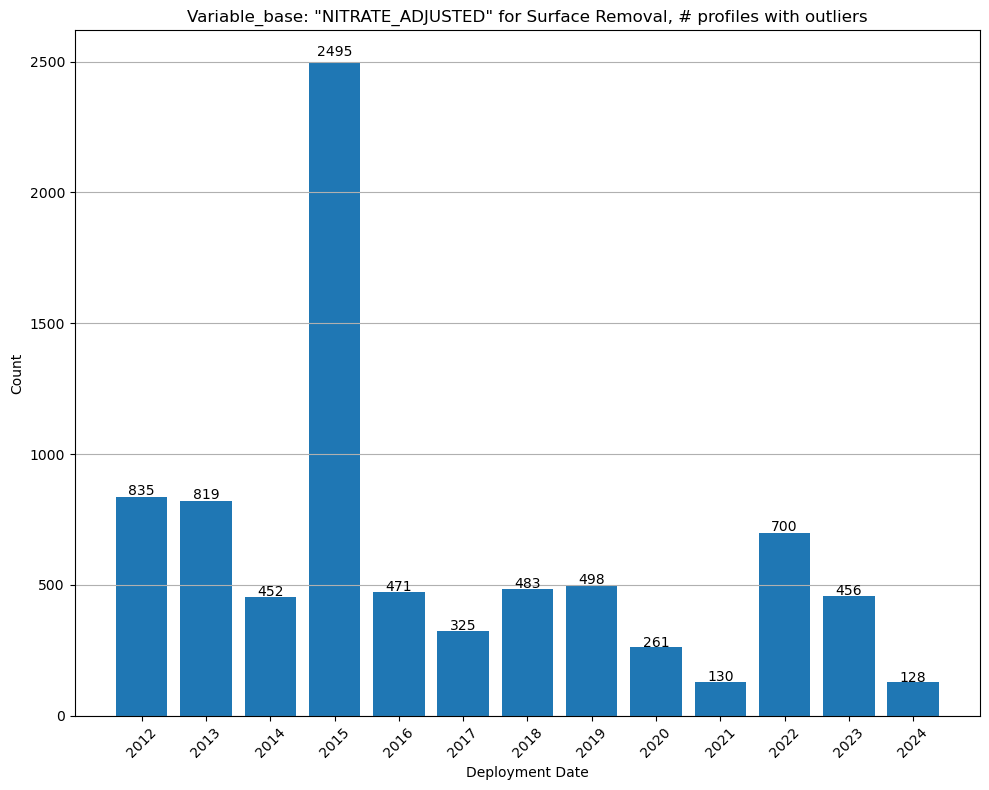

PH_IN_SITU_TOTAL_ADJUSTED
Manual Removal


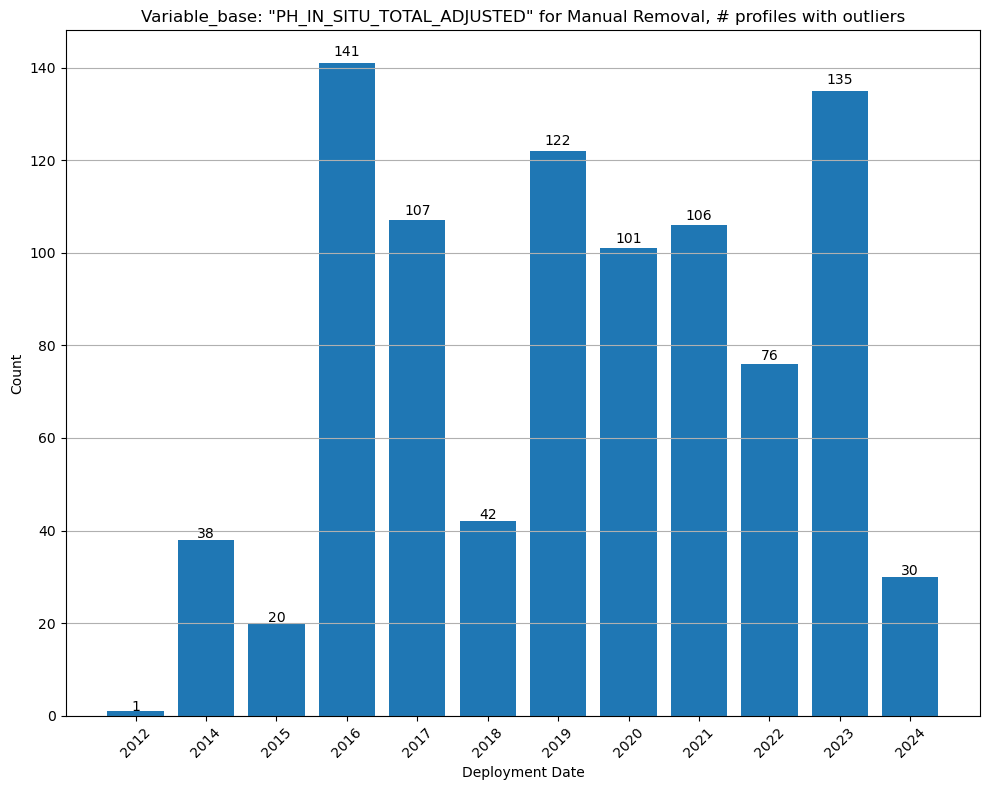

Surface Removal


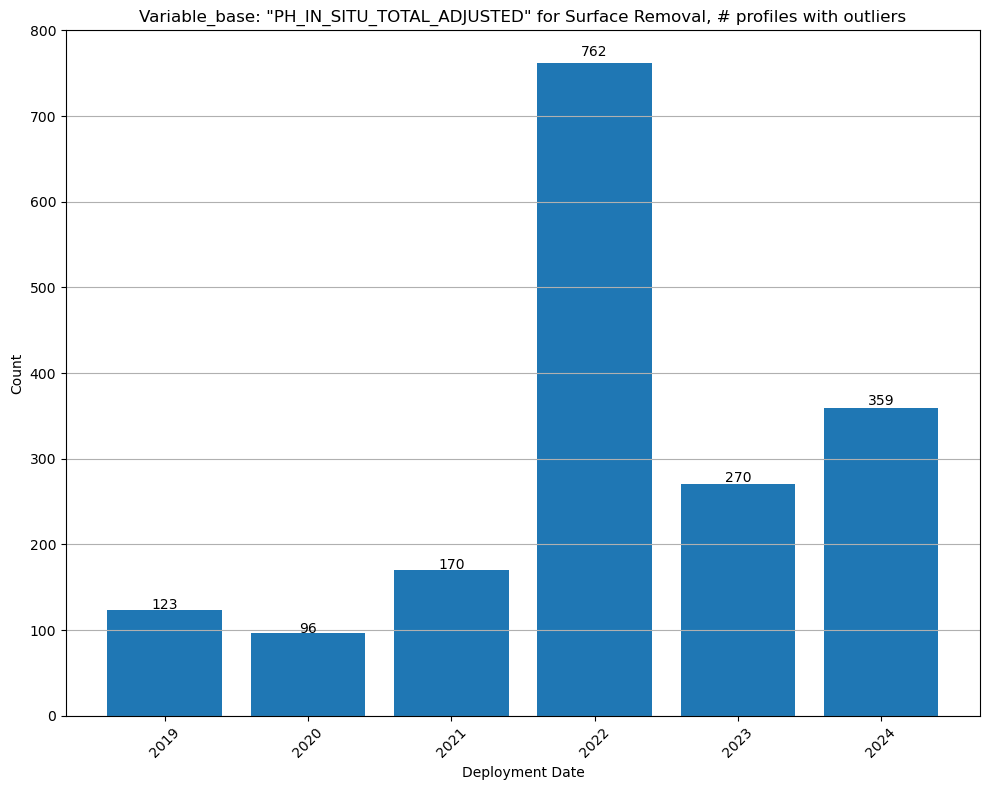

TEMP
Manual Removal


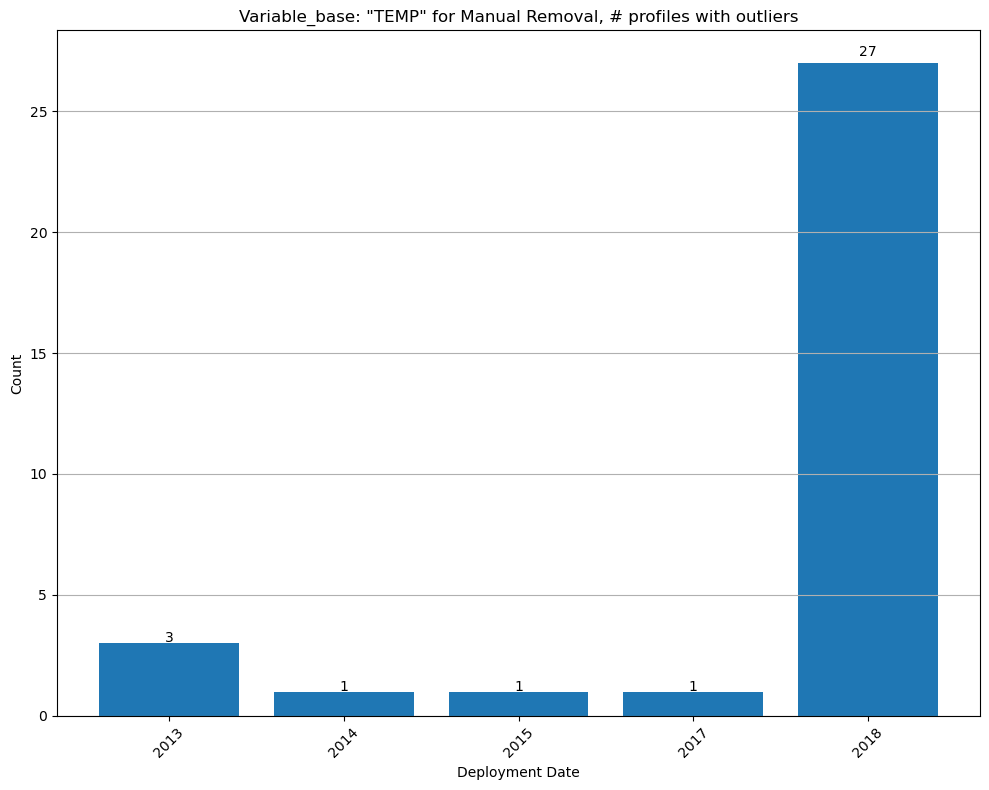

PSAL
Manual Removal


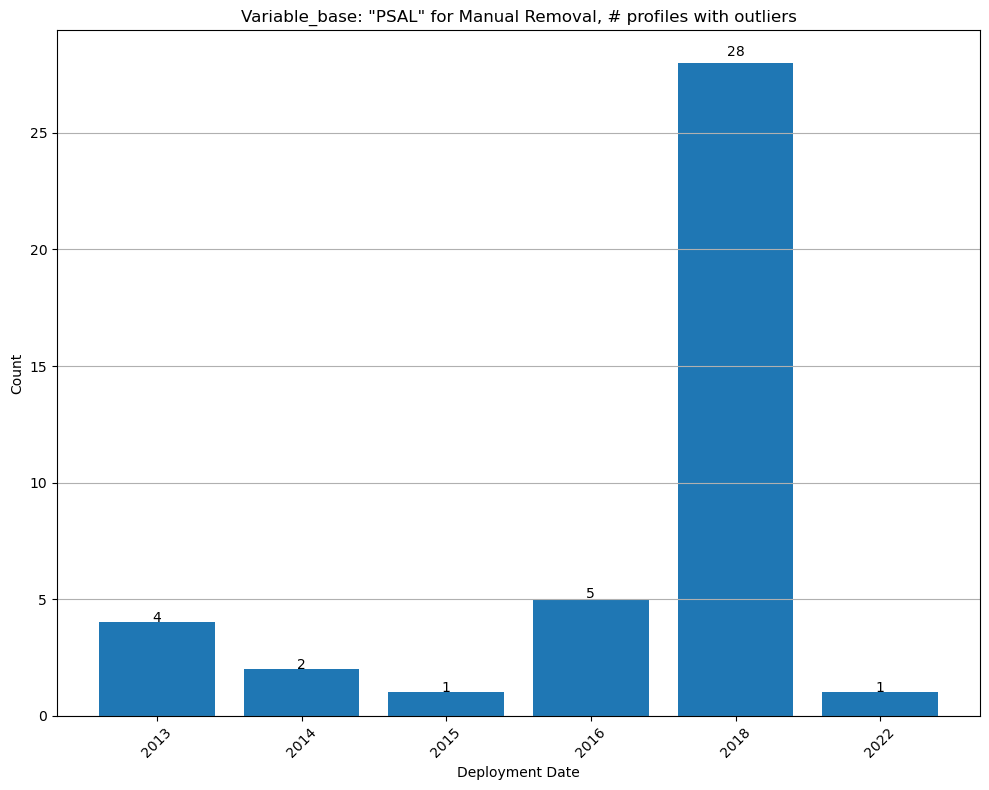

In [251]:
# print outlier counts by deployment year for two
filter_column = 'Variable_base' 
second_filter_column = 'Deletion reason'
for filter_type in merged_outlier_df[filter_column].unique():
    print(filter_type)
    filter_df = merged_outlier_df[merged_outlier_df[filter_column]==filter_type]
    for variable_filter in filter_df[second_filter_column].unique():
        if variable_filter in ['TEMP', 'PSAL']:
            continue
        print(variable_filter)
        second_filter_df = filter_df[filter_df[second_filter_column]==variable_filter]
            
            # break
        # variable_list = filter_df['Variable'].unique()
        # variable_list = []
        # variable_list.append(comparison_column)
        # for d in range(0, len(filter_df['Variable'].unique())):
        #     variable_list.append(filter_df['Variable'].unique()[d])
        # # print(variable_list)
        # variable_list = [var for var in variable_list if not (var=='TEMP' or var=='TEMP_ADJUSTED' or var=='PSAL' or var=='PSAL_ADJUSTED')]

        outliers_grouped_profiles = second_filter_df.drop_duplicates(['Float Number', 'Variable_base', 'N_PROF', 'pd Date'])[['Float Number', 'Variable_base', 'N_PROF', 'pd Date']]
        # break

        years = outliers_grouped_profiles.groupby(outliers_grouped_profiles["pd Date"].dt.year)
        keys = []
        counts = []
        for year, data in years:
            keys.append(year)
            counts.append(len(data))

        fig = plt.figure(figsize=(10, 8))
        plt.bar(np.arange(len(keys)), counts)
        plt.grid(axis='y')
        plt.xticks(np.arange(len(keys)), labels=keys, rotation=45)
        plt.title(filter_column + ': "' + filter_type + '" for ' + variable_filter + ', # profiles with outliers')
        # (filter_column + ': "' + filter_type + '", for ' + variable_filter + ', # profiles with outliers', fontsize=font_size+2)

        plt.ylabel("Count")
        plt.xlabel("Deployment Date")
        for i, value in enumerate(counts):
            plt.text(i, value + value*.01, str(value), ha='center', fontsize=10)
        plt.tight_layout()
        plt.savefig(manuscript_figs + "Outliers_by_Deployment_Date_" + filter_column + '_' + filter_type + '_' + variable_filter + ".png")
        plt.show()
        plt.close(fig)
    #     break
    # break
# print(filter_df.shape)
# print(outliers_grouped_profiles.shape)
# outliers_grouped_profiles

In [258]:
filter_df
outliers_grouped_profiles = filter_df.drop_duplicates(['Float Number', 'Variable_base', 'N_PROF', 'pd Date', second_filter_column])[['Float Number', 'Variable_base', 'N_PROF', 'pd Date', second_filter_column]]
outliers_grouped_profiles

,Float Number,Variable_base,N_PROF,pd Date,Deletion reason
0,1900650,PSAL_ADJUSTED,74.0,2006-06-20 23:40:01.632000000,Manual Removal
1,1900651,PSAL_ADJUSTED,41.0,2006-07-08 20:02:34.368000000,Manual Removal
2,1900651,PSAL_ADJUSTED,42.0,2006-07-08 20:02:34.368000000,Manual Removal
3,1900651,PSAL_ADJUSTED,91.0,2006-07-08 20:02:34.368000000,Manual Removal
10,1900722,PSAL_ADJUSTED,54.0,2006-10-22 02:16:24.000628736,Manual Removal
...,...,...,...,...,...
552575,7902112,PSAL_ADJUSTED,29.0,2024-07-10 20:16:44.002168832,Surface Removal
552580,7902112,PSAL_ADJUSTED,30.0,2024-07-10 20:16:44.002168832,Surface Removal
552587,7902112,PSAL_ADJUSTED,31.0,2024-07-10 20:16:44.002168832,Surface Removal
552589,7902112,PSAL_ADJUSTED,32.0,2024-07-10 20:16:44.002168832,Surface Removal


In [259]:
counts_dict

{'Density Inversion': [(2003, 1),
  (2004, 73),
  (2005, 10),
  (2006, 22),
  (2007, 134),
  (2008, 55),
  (2009, 18),
  (2010, 83),
  (2011, 58),
  (2012, 71),
  (2013, 138),
  (2014, 312),
  (2015, 98),
  (2016, 109),
  (2017, 121),
  (2018, 87),
  (2019, 153),
  (2020, 81),
  (2021, 177),
  (2022, 150),
  (2023, 30),
  (2024, 23)],
 'Surface Removal': [(2003, 1),
  (2005, 17),
  (2008, 159),
  (2010, 1),
  (2011, 1),
  (2012, 407),
  (2013, 856),
  (2014, 7708),
  (2015, 5259),
  (2016, 2857),
  (2017, 1615),
  (2018, 1633),
  (2019, 756),
  (2020, 351),
  (2021, 1436),
  (2022, 1970),
  (2023, 55),
  (2024, 115)],
 'Manual Removal': [(2004, 2),
  (2005, 5),
  (2006, 8),
  (2007, 11),
  (2008, 5),
  (2009, 7),
  (2010, 89),
  (2011, 11),
  (2012, 3),
  (2013, 15),
  (2014, 41),
  (2015, 67),
  (2016, 68),
  (2017, 56),
  (2018, 38),
  (2019, 18),
  (2020, 32),
  (2021, 15),
  (2022, 8),
  (2023, 4),
  (2024, 3)]}

In [262]:
keys

[2013, 2014, 2015, 2016, 2018, 2022]

In [263]:
reason_counts

[1,
 17,
 159,
 1,
 1,
 407,
 856,
 7708,
 5259,
 2857,
 1615,
 1633,
 756,
 351,
 1436,
 1970,
 55,
 115]

In [267]:
reason_counts = [count for (year, count) in counts_dict[reason]]
years_list = [year for (year, count) in counts_dict[reason]]
years_list

[2003,
 2005,
 2008,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024]

(2012,
        Float Number              Variable_base  N_PROF  \
 211702      5903893  PH_IN_SITU_TOTAL_ADJUSTED     0.0   
 
                              pd Date Deletion reason  
 211702 2012-10-03 06:07:14.999367424  Manual Removal  )

PSAL_ADJUSTED
DOXY_ADJUSTED
TEMP_ADJUSTED
NITRATE_ADJUSTED
PH_IN_SITU_TOTAL_ADJUSTED


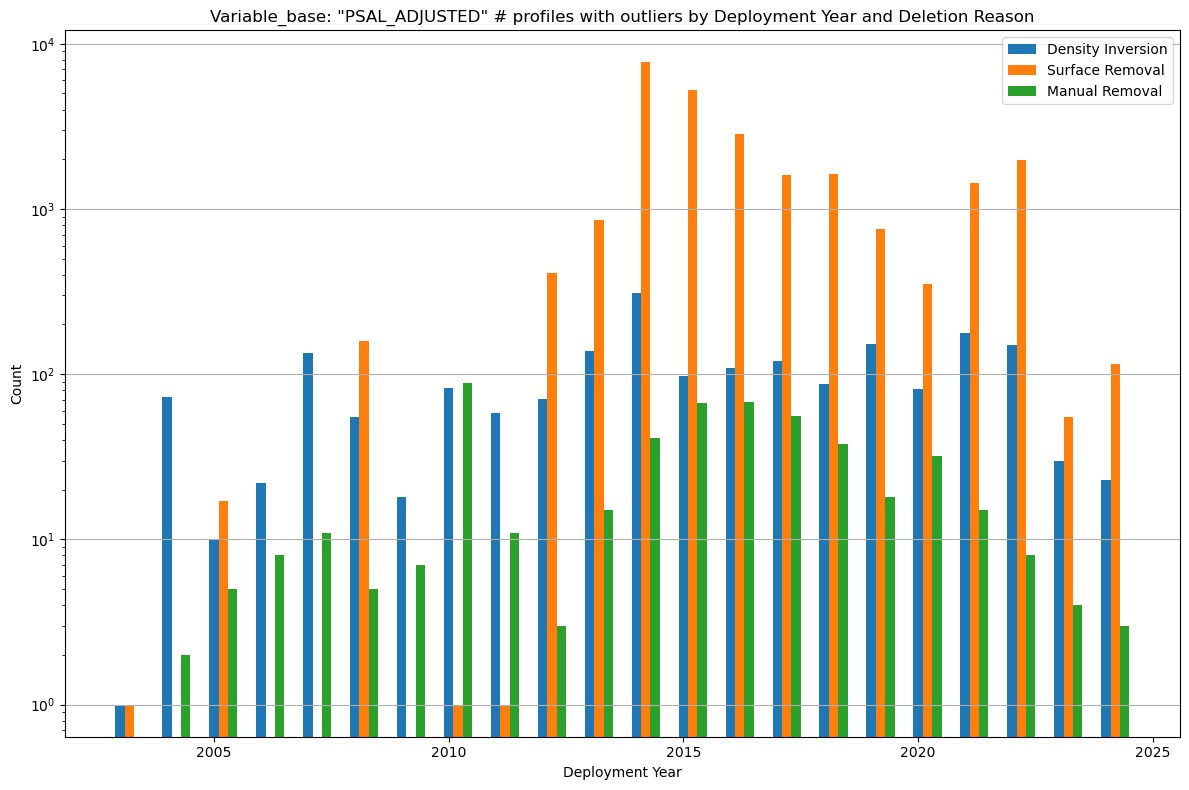

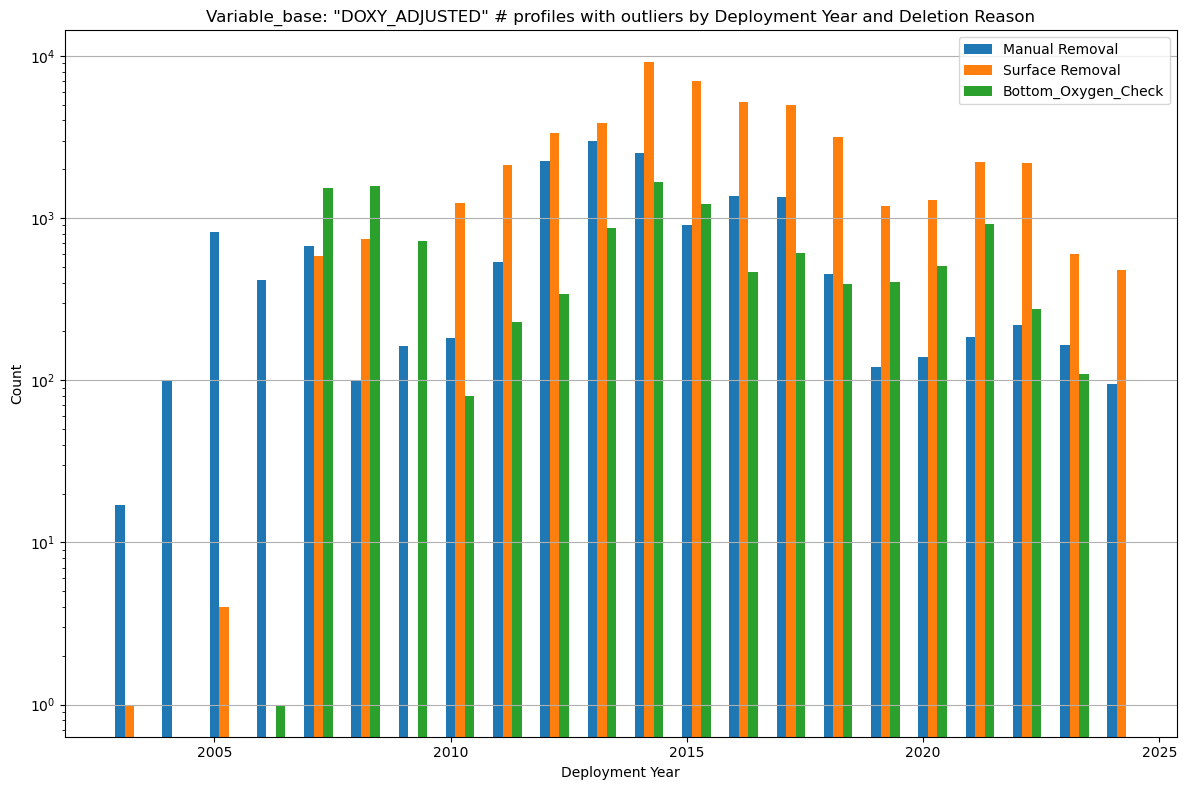

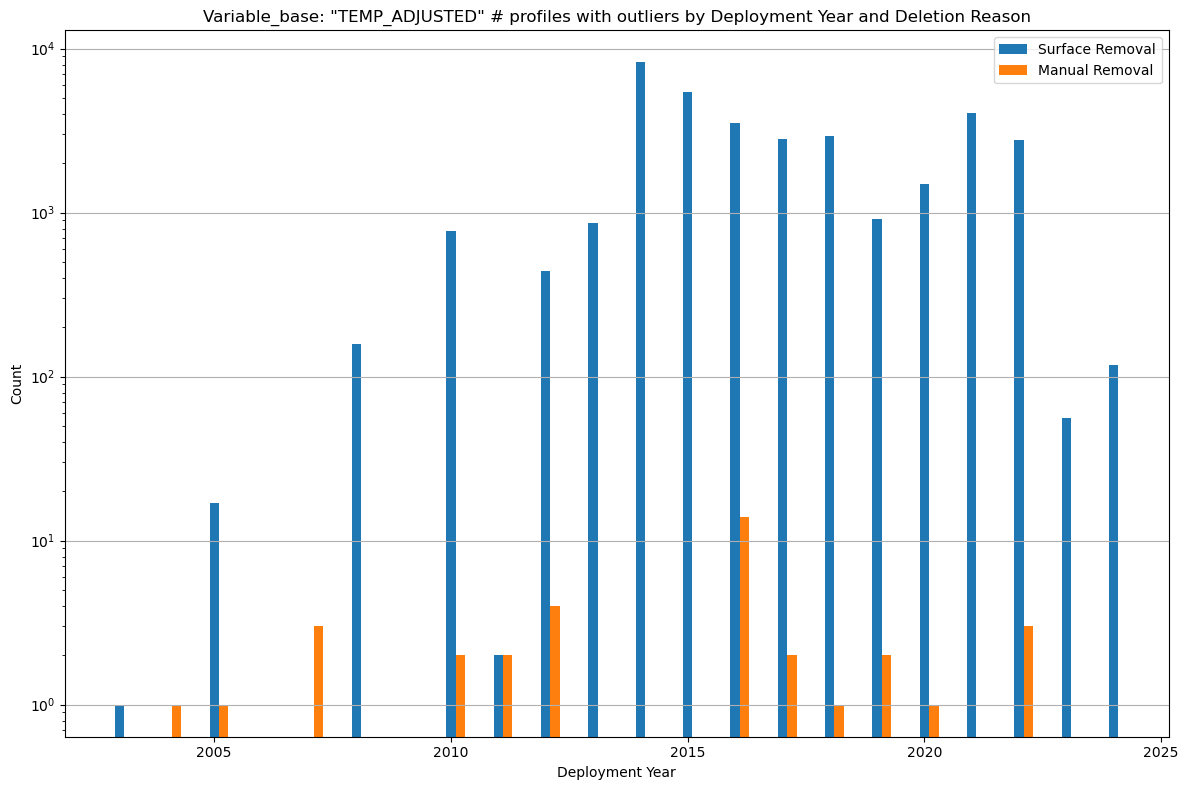

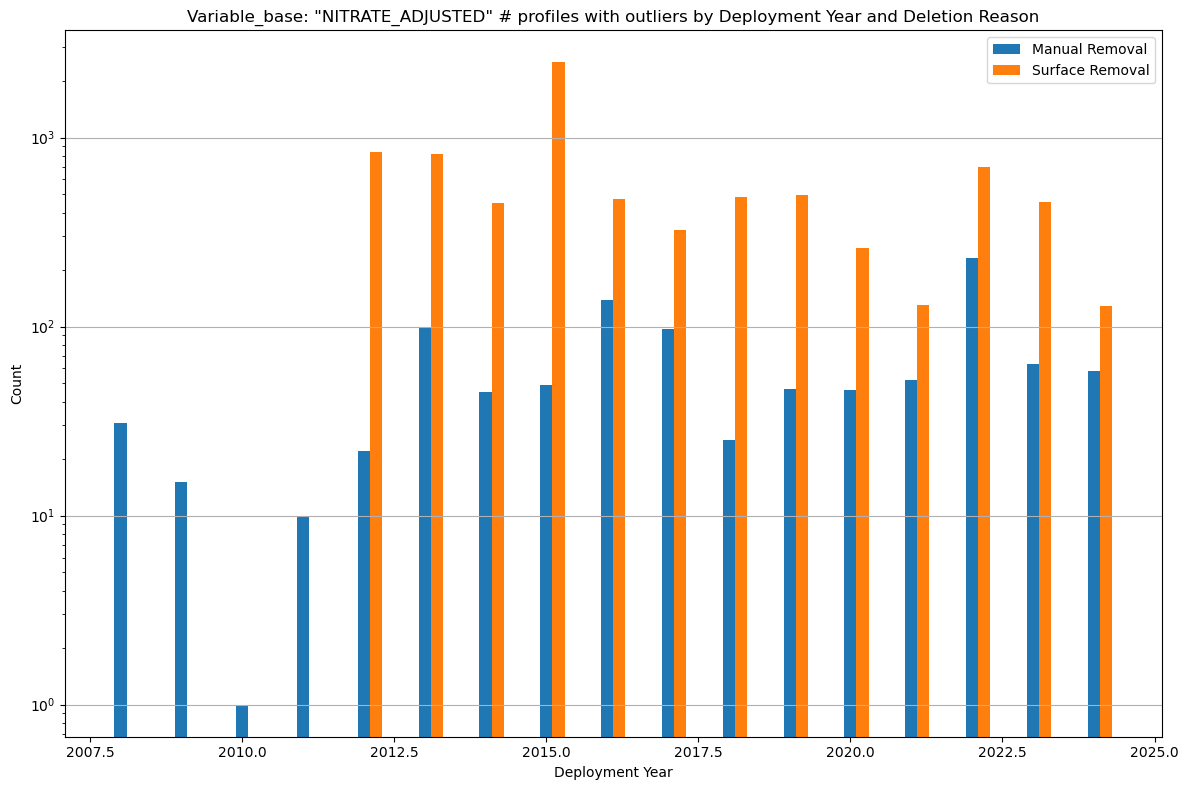

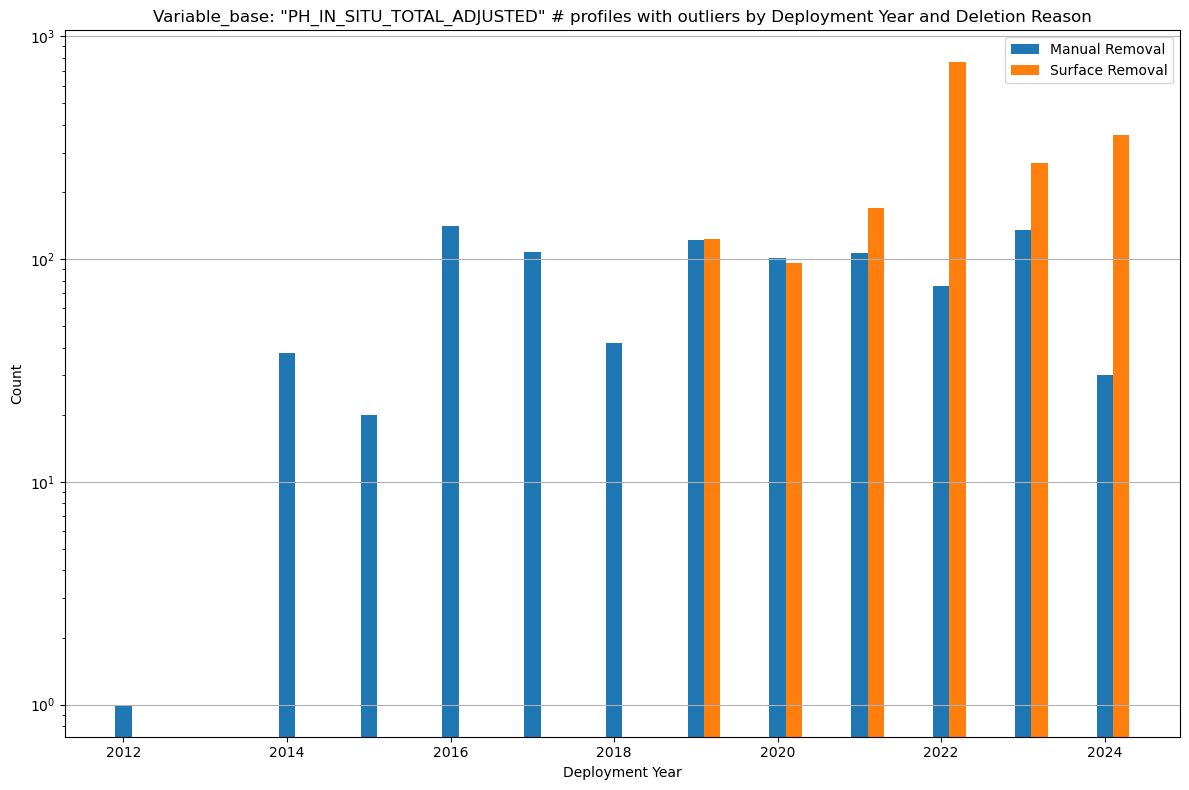

In [285]:
# similar to the above bar charts but do multiple bars per deployment year for the second filter columns
filter_column = 'Variable_base'
second_filter_column = 'Deletion reason'
for filter_type in merged_outlier_df[filter_column].unique():
    if filter_type in ['TEMP', 'PSAL']:
        continue
    print(filter_type)
    filter_df = merged_outlier_df[merged_outlier_df[filter_column]==filter_type]
    # break
    outliers_grouped_profiles = filter_df.drop_duplicates(['Float Number', 'Variable_base', 'N_PROF', 'pd Date', second_filter_column])[['Float Number', 'Variable_base', 'N_PROF', 'pd Date', second_filter_column]]
    # break

    years = outliers_grouped_profiles.groupby(outliers_grouped_profiles["pd Date"].dt.year)
    keys = []
    counts_dict = {}
    for year, data in years:
        keys.append(year)
        for reason in data[second_filter_column].unique():
            if reason not in counts_dict:
                counts_dict[reason] = []
            reason_count = len(data[data[second_filter_column]==reason])
            counts_dict[reason].append((year, reason_count))

    # create bar chart with multiple bars per year
    fig = plt.figure(figsize=(12, 8))
    bar_width = 0.2
    x = np.arange(len(keys))
    for idx, reason in enumerate(counts_dict.keys()):
        reason_counts = [count for (year, count) in counts_dict[reason]]
        years_list = [year for (year, count) in counts_dict[reason]]
        plt.bar(np.array(years_list) + idx * bar_width, reason_counts, width=bar_width, label=reason)

    plt.grid(axis='y')
    # plt.xticks(x + bar_width * (len(counts_dict)-1) / 2, labels=keys, rotation=45)
    plt.yscale('log')
    plt.title(filter_column + ': "' + filter_type + '" # profiles with outliers by Deployment Year and Deletion Reason')
    plt.ylabel("Count")
    plt.xlabel("Deployment Year")
    plt.legend()
    plt.tight_layout()
    plt.savefig(manuscript_figs + "Outliers_by_Deployment_Date_MultiBar_" + second_filter_column + '_' + filter_type + ".png")

### Maps of outliers removed

In [16]:
# first, need to add lat/lon for each profile...
# merged_outlier_df['Lat'] = np.nan
# merged_outlier_df['Lon'] = np.nan

latlon_records = []


# get list of unique floats in the outlier dataframe
unique_floats = merged_outlier_df['Float Number'].unique()

# open each float, find which profiles are in the outlier dataframe, get lat/lon for those profiles
for float_num in tqdm(unique_floats):
    float_file = output_dir + str(float_num) + '_Sprof_BGCArgoPlus_full.nc'
    if not os.path.exists(float_file):
        print(f"File not found: {float_file}")
        continue
    argo_n = xr.open_dataset(float_file)
    float_profiles = argo_n['N_PROF'].values
    float_lats = argo_n['LATITUDE'].values
    float_lons = argo_n['LONGITUDE'].values
    
    # Build a list of dicts for all profiles in this float
    for prof, lat, lon in zip(float_profiles, float_lats, float_lons):
        latlon_records.append({
            'Float Number': float_num,
            'N_PROF': prof,
            'Lat': lat,
            'Lon': lon
        })
    argo_n.close()

# Create a DataFrame for merging
latlon_df = pd.DataFrame(latlon_records)

# Merge lat/lon onto merged_outlier_df (left join to preserve all outliers)
merged_outlier_df = pd.merge(
    merged_outlier_df.drop(columns=['Lat', 'Lon'], errors='ignore'),
    latlon_df,
    on=['Float Number', 'N_PROF'],
    how='left'
)
    # float_outlier_df = merged_outlier_df[merged_outlier_df['Float Number']==float_num]
    # for outlier_prof in float_outlier_df['N_PROF'].unique():
    #     # print(outlier_prof)
    #     merged_outlier_df.loc[(merged_outlier_df['Float Number']==float_num) & (merged_outlier_df['N_PROF']==outlier_prof), 'Lat'] = float_lats[float_profiles==outlier_prof].item()
    #     merged_outlier_df.loc[(merged_outlier_df['Float Number']==float_num) & (merged_outlier_df['N_PROF']==outlier_prof), 'Lon'] = float_lons[float_profiles==outlier_prof].item()

    # # for idx, profile in enumerate(float_profiles):
    # # #     profile_outlier_df = float_outlier_df[float_outlier_df['N_PROF']==profile]
    # #     if profile_outlier_df.shape[0]>0:
    #         merged_outlier_df.loc[(merged_outlier_df['Float Number']==float_num) & (merged_outlier_df['N_PROF']==profile), 'Lat'] = float_lats[idx]
    #         merged_outlier_df.loc[(merged_outlier_df['Float Number']==float_num) & (merged_outlier_df['N_PROF']==profile), 'Lon'] = float_lons[idx]
    # argo_n.close()
    # break
    # break

100%|██████████| 1183/1183 [00:46<00:00, 25.42it/s]


In [17]:
# save dataset w/ lat and lon
merged_outlier_df.to_csv(manuscript_dir + "Dataset paper group folder/Data/merged_outlier_meta_with_latlon.csv", index=False)

In [288]:
merged_outlier_df

,Float Number,Variable,N_PROF,Date,N_LEVELS,Pressure (dbar),Deletion reason,Variable_short,unique_id,Variable_base,...,DOXY_MODEL,NITRATE_MODEL,PH_MODEL,Deployment_Date,Dep_Lat,Dep_Lon,Last_Date,pd Date,Lat,Lon
0,1900650,PSAL_ADJUSTED,74.0,2008-08-09 00:09:20.736,55.0,798.799988,Manual Removal,PSAL_ADJUSTED,1900650.0_PSAL_ADJUSTED_74.0_55.0,PSAL_ADJUSTED,...,AANDERAA_OPTODE_3830,NaN,NaN,2006-06-20 23:40:01.632000000,3.8920,-34.2760,2010-03-12 00:23:41.280000000,2006-06-20 23:40:01.632000000,9.9100,-18.5050
1,1900651,PSAL_ADJUSTED_RO,41.0,2007-09-01 18:48:46.368,18.0,89.500000,Manual Removal,PSAL_ADJUSTED,1900651.0_PSAL_ADJUSTED_41.0_18.0,PSAL_ADJUSTED,...,AANDERAA_OPTODE_3830,NaN,NaN,2006-07-08 20:02:34.368000000,-0.8160,-21.8530,2009-11-19 20:29:42.144000000,2006-07-08 20:02:34.368000000,2.8550,-23.9880
2,1900651,PSAL_ADJUSTED_RO,42.0,2007-09-11 20:19:12.288,13.0,59.400002,Manual Removal,PSAL_ADJUSTED,1900651.0_PSAL_ADJUSTED_42.0_13.0,PSAL_ADJUSTED,...,AANDERAA_OPTODE_3830,NaN,NaN,2006-07-08 20:02:34.368000000,-0.8160,-21.8530,2009-11-19 20:29:42.144000000,2006-07-08 20:02:34.368000000,2.1170,-22.7990
3,1900651,PSAL_ADJUSTED_RO,91.0,2009-01-13 20:29:51.648,0.0,4.700000,Manual Removal,PSAL_ADJUSTED,1900651.0_PSAL_ADJUSTED_91.0_0.0,PSAL_ADJUSTED,...,AANDERAA_OPTODE_3830,NaN,NaN,2006-07-08 20:02:34.368000000,-0.8160,-21.8530,2009-11-19 20:29:42.144000000,2006-07-08 20:02:34.368000000,4.5270,-30.6200
4,1900651,PSAL_ADJUSTED_RO,91.0,2009-01-13 20:29:51.648,1.0,6.600000,Manual Removal,PSAL_ADJUSTED,1900651.0_PSAL_ADJUSTED_91.0_1.0,PSAL_ADJUSTED,...,AANDERAA_OPTODE_3830,NaN,NaN,2006-07-08 20:02:34.368000000,-0.8160,-21.8530,2009-11-19 20:29:42.144000000,2006-07-08 20:02:34.368000000,4.5270,-30.6200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552590,7902112,TEMP_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,0.0,0.900000,Surface Removal,TEMP_ADJUSTED,7902112.0_TEMP_ADJUSTED_33.0_0.0,TEMP_ADJUSTED,...,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464,2024-07-10 20:16:44.002168832,40.2101,-148.7791
552591,7902112,TEMP_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,1.0,1.800000,Surface Removal,TEMP_ADJUSTED,7902112.0_TEMP_ADJUSTED_33.0_1.0,TEMP_ADJUSTED,...,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464,2024-07-10 20:16:44.002168832,40.2101,-148.7791
552592,7902112,PSAL_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,0.0,0.900000,Surface Removal,PSAL_ADJUSTED,7902112.0_PSAL_ADJUSTED_33.0_0.0,PSAL_ADJUSTED,...,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464,2024-07-10 20:16:44.002168832,40.2101,-148.7791
552593,7902112,PSAL_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,1.0,1.800000,Surface Removal,PSAL_ADJUSTED,7902112.0_PSAL_ADJUSTED_33.0_1.0,PSAL_ADJUSTED,...,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464,2024-07-10 20:16:44.002168832,40.2101,-148.7791


In [18]:
# make a map of outlier locations by type
import cartopy.crs as ccrs
import cartopy.feature as cfeature

title_font_size = 15
axis_label_font_size = 14

# filter_column = 'Data_Centre'
filter_column = 'Variable_base'
second_filter_column = 'Deletion reason'

for filter_type in merged_outlier_df[filter_column].unique():
    if filter_type in ['TEMP',  'PSAL']:
            continue
    print(filter_type)
    filter_df = merged_outlier_df[merged_outlier_df[filter_column]==filter_type]
    
    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(int(np.ceil((len(filter_df[second_filter_column].unique())+1)/2)),2,1, projection=ccrs.InterruptedGoodeHomolosine(central_longitude=-160, globe=None, emphasis='ocean'))
    ax.set_title('All outliers')
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))
    ax.set_global()
    gl = ax.gridlines(draw_labels=True, ylocs=[-60, -30, 0, 30, 60], xlocs=[-180, -120, -60, 0, 60, 120], x_inline=False)
    gl.left_labels = True
    gl.top_labels = False
    gl.bottom_labels=False

    ax.scatter(filter_df['Lon'], filter_df['Lat'], transform=ccrs.PlateCarree(), s=1, color='blue', alpha=0.5)
    for idx, second_filter in enumerate(filter_df[second_filter_column].unique()):
        second_filter_df = filter_df[filter_df[second_filter_column]==second_filter]
        
        ax = fig.add_subplot(int(np.ceil((len(filter_df[second_filter_column].unique())+1)/2)),2,idx+2, projection=ccrs.InterruptedGoodeHomolosine(central_longitude=-160, globe=None, emphasis='ocean'))
        ax.set_title(second_filter)
        ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))
        ax.set_global()
        gl = ax.gridlines(draw_labels=True, ylocs=[-60, -30, 0, 30, 60], xlocs=[-180, -120, -60, 0, 60, 120], x_inline=False)
        gl.left_labels = True
        gl.top_labels = False
        gl.bottom_labels=False

        ax.scatter(second_filter_df['Lon'], second_filter_df['Lat'], transform=ccrs.PlateCarree(), s=1, color='red', alpha=0.5)
    fig.suptitle(f'Locations of outliers for {filter_column}: {filter_type}', fontsize=title_font_size)
    
    plt.tight_layout()
    fig.savefig(manuscript_figs + 'maps/outlier_locations_by_' + filter_column + '_' + str(filter_type).replace(' ', '_') + plot_ver + '.png', dpi=300)
    plt.close(fig)
    # break


PSAL_ADJUSTED
DOXY_ADJUSTED
TEMP_ADJUSTED
NITRATE_ADJUSTED
PH_IN_SITU_TOTAL_ADJUSTED


In [20]:
second_filter_df

,Float Number,Variable,N_PROF,Date,N_LEVELS,Pressure (dbar),Deletion reason,Variable_short,Variable_base,Project,Data_Centre,DOXY_MODEL,NITRATE_MODEL,PH_MODEL,Deployment_Date,Dep_Lat,Dep_Lon,Last_Date,Lat,Lon
6264,1902368,PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus,0.0,2024-05-26 05:21:57,4.0,1.52,Surface Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,SEAFET,2024-05-26 05:21:57.000566784,57.4676,-148.0030,2024-12-18 20:30:20.002189312,57.46761,-148.00303
6267,1902368,PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus,1.0,2024-05-26 06:49:05,5.0,1.72,Surface Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,SEAFET,2024-05-26 05:21:57.000566784,57.4676,-148.0030,2024-12-18 20:30:20.002189312,57.47618,-147.99799
6269,1902368,PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus,2.0,2024-05-26 11:37:32,4.0,1.76,Surface Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,SEAFET,2024-05-26 05:21:57.000566784,57.4676,-148.0030,2024-12-18 20:30:20.002189312,57.49144,-147.99602
6272,1902368,PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus,3.0,2024-05-26 16:27:43,5.0,1.92,Surface Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,SEAFET,2024-05-26 05:21:57.000566784,57.4676,-148.0030,2024-12-18 20:30:20.002189312,57.48864,-148.00506
6275,1902368,PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus,4.0,2024-05-27 03:54:22,5.0,1.80,Surface Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,SEAFET,2024-05-26 05:21:57.000566784,57.4676,-148.0030,2024-12-18 20:30:20.002189312,57.49822,-148.02112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563969,7902112,PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus,28.0,2024-11-29 15:20:53,0.0,0.80,Surface Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464,40.33820,-148.98050
563970,7902112,PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus,28.0,2024-11-29 15:20:53,1.0,1.70,Surface Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464,40.33820,-148.98050
563974,7902112,PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus,29.0,2024-12-04 21:10:30,0.0,0.40,Surface Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464,40.32210,-148.92150
563981,7902112,PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus,30.0,2024-12-10 04:07:39,0.0,0.40,Surface Removal,PH_IN,PH_IN_SITU_TOTAL_ADJUSTED,GO-BGC,AO,SBE83_OPTODE,SUNA_V2,UNKNOWN,2024-07-10 20:16:44.002168832,40.5100,-149.9369,2024-12-26 00:43:09.000062464,40.30600,-148.90890


In [42]:
merged_outlier_df[merged_outlier_df['Data_Centre']=='ME']


,Float Number,Variable,N_PROF,Date,N_LEVELS,Pressure (dbar),Deletion reason,Variable_short,Variable_base,Project,Data_Centre,DOXY_MODEL,NITRATE_MODEL,PH_MODEL,Deployment_Date,Dep_Lat,Dep_Lon,Last_Date,Lat,Lon
192345,4900494,PSAL_ADJUSTED_BGCArgoPlus,1.0,2004-06-14 12:22:00,29.0,289.19998,Density Inversion,PSAL_ADJUSTED,PSAL_ADJUSTED,Argo Canada,ME,AANDERAA_OPTODE_3830,NaN,NaN,2004-06-04 12:35:00.000000000,59.9520,-50.1570,2008-07-23 13:03:00.000000000,59.566002,-48.840000
192346,4900494,PSAL_ADJUSTED_BGCArgoPlus,1.0,2004-06-14 12:22:00,15.0,149.00000,Density Inversion,PSAL_ADJUSTED,PSAL_ADJUSTED,Argo Canada,ME,AANDERAA_OPTODE_3830,NaN,NaN,2004-06-04 12:35:00.000000000,59.9520,-50.1570,2008-07-23 13:03:00.000000000,59.566002,-48.840000
192347,4900494,PSAL_ADJUSTED_BGCArgoPlus,4.0,2004-07-14 16:00:00,13.0,129.30000,Density Inversion,PSAL_ADJUSTED,PSAL_ADJUSTED,Argo Canada,ME,AANDERAA_OPTODE_3830,NaN,NaN,2004-06-04 12:35:00.000000000,59.9520,-50.1570,2008-07-23 13:03:00.000000000,59.103001,-48.667000
192348,4900494,PSAL_ADJUSTED_BGCArgoPlus,4.0,2004-07-14 16:00:00,21.0,209.50000,Density Inversion,PSAL_ADJUSTED,PSAL_ADJUSTED,Argo Canada,ME,AANDERAA_OPTODE_3830,NaN,NaN,2004-06-04 12:35:00.000000000,59.9520,-50.1570,2008-07-23 13:03:00.000000000,59.103001,-48.667000
192349,4900494,PSAL_ADJUSTED_BGCArgoPlus,4.0,2004-07-14 16:00:00,17.0,169.10000,Density Inversion,PSAL_ADJUSTED,PSAL_ADJUSTED,Argo Canada,ME,AANDERAA_OPTODE_3830,NaN,NaN,2004-06-04 12:35:00.000000000,59.9520,-50.1570,2008-07-23 13:03:00.000000000,59.103001,-48.667000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193212,4901784,DOXY_ADJUSTED_BGCArgoPlus,50.0,2016-11-16 10:46:59,524.0,2020.30000,Bottom_Oxygen_Check,DOXY_ADJUSTED,DOXY_ADJUSTED,Argo Canada,ME,SBE63_OPTODE,NaN,NaN,2015-07-05 12:48:00.000000000,46.4992,-129.0073,2021-11-30 10:50:00.000000256,44.761982,-132.490448
193213,4901784,DOXY_ADJUSTED_BGCArgoPlus,57.0,2017-01-25 10:46:00,519.0,2015.10000,Bottom_Oxygen_Check,DOXY_ADJUSTED,DOXY_ADJUSTED,Argo Canada,ME,SBE63_OPTODE,NaN,NaN,2015-07-05 12:48:00.000000000,46.4992,-129.0073,2021-11-30 10:50:00.000000256,44.212040,-132.467285
193214,4901784,DOXY_ADJUSTED_BGCArgoPlus,61.0,2017-03-06 10:43:00,516.0,2015.30000,Bottom_Oxygen_Check,DOXY_ADJUSTED,DOXY_ADJUSTED,Argo Canada,ME,SBE63_OPTODE,NaN,NaN,2015-07-05 12:48:00.000000000,46.4992,-129.0073,2021-11-30 10:50:00.000000256,44.022732,-132.244888
193215,4901784,DOXY_ADJUSTED_BGCArgoPlus,77.0,2017-08-23 10:48:00,526.0,2021.20000,Bottom_Oxygen_Check,DOXY_ADJUSTED,DOXY_ADJUSTED,Argo Canada,ME,SBE63_OPTODE,NaN,NaN,2015-07-05 12:48:00.000000000,46.4992,-129.0073,2021-11-30 10:50:00.000000256,43.737900,-132.831177


In [28]:
data_centre_list = merged_outlier_df['Data_Centre'].unique()
data_centre_list
merged_outlier_df[merged_outlier_df['Data_Centre']==data_centre_list[5]]
# remove nan values from data_centre_list
data_centre_list = [dc for dc in data_centre_list if pd.notna(dc)]
data_centre_list

['IF', 'AO', 'CS', 'IN', 'HZ', 'JA', 'BO', 'ME']

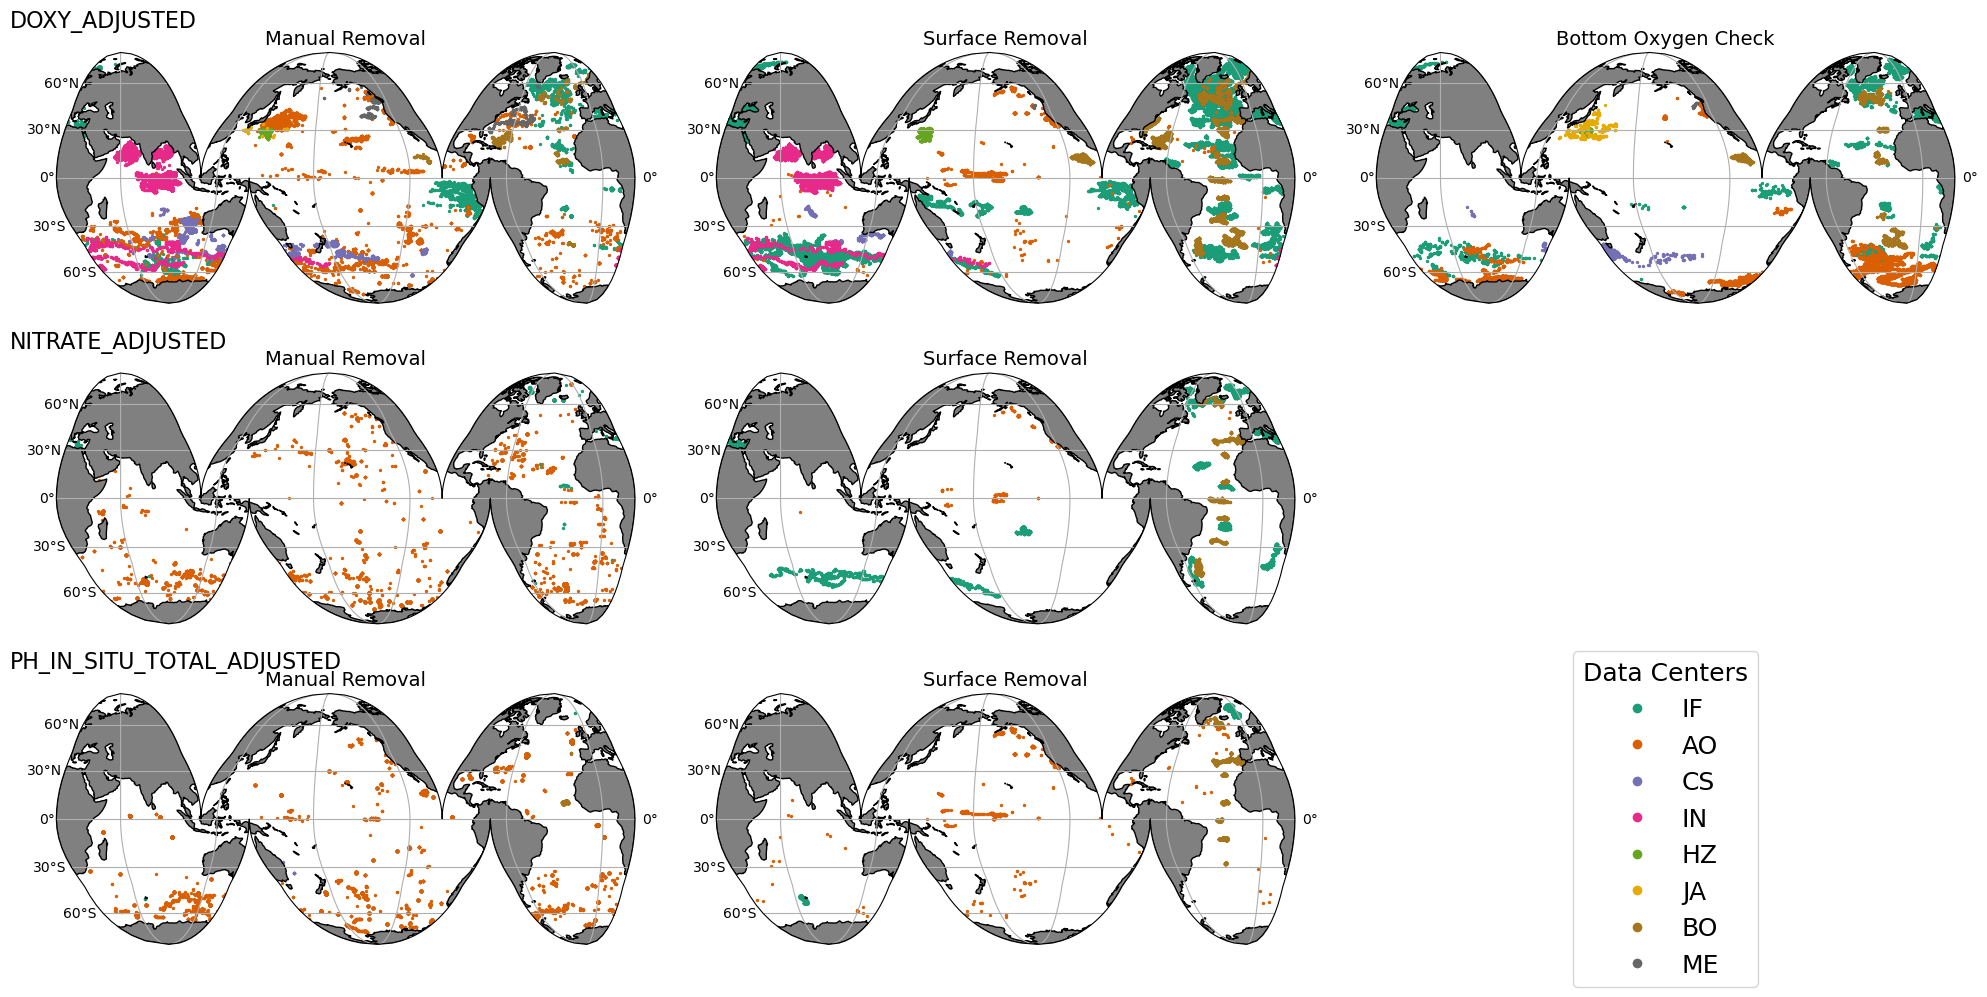

In [34]:
# one figure with maps of Manual, Surface, Bottom Oxygen for oxygen, nitrate, pH
color_map = plt.get_cmap('Dark2')
colors = [color_map(i) for i in np.arange(0, len(data_centre_list))]

filter_column = 'Variable_base'
second_filter_column = 'Deletion reason'
third_filter_column = 'Data_Centre'
fig = plt.figure(figsize=(20, 10))
for idx_f, filter_type in enumerate(['DOXY_ADJUSTED', 'NITRATE_ADJUSTED', 'PH_IN_SITU_TOTAL_ADJUSTED']):
    filter_df = merged_outlier_df[merged_outlier_df[filter_column]==filter_type]
    for idx, second_filter in enumerate(filter_df[second_filter_column].unique()):
        second_filter_df = filter_df[filter_df[second_filter_column]==second_filter]
        if second_filter=='Manual Removal':
            col_n = 1
            # color = colors[0]
        elif second_filter=='Surface Removal':
            col_n = 2
            # color = colors[1]
        else:
            col_n = 3
            # color = colors[3]
        ax = fig.add_subplot(3,3, idx_f*3 + col_n, projection=ccrs.InterruptedGoodeHomolosine(central_longitude=-160, globe=None, emphasis='ocean')) 
        ax.set_title(f'{second_filter}')
        if idx==0:
            ax.text(-.08, 1.1, f'{filter_type}', transform=ax.transAxes, ha='left', fontsize=16)
        
        if '_' in second_filter:
            second_filter = second_filter.replace('_', ' ')
        ax.set_title(second_filter, fontsize = 14)
        ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor=[.5, .5 ,.5]))
        ax.set_global()
        gl = ax.gridlines(draw_labels=True, ylocs=[-60, -30, 0, 30, 60], xlocs=[-180, -120, -60, 0, 60, 120], x_inline=False)
        gl.left_labels = True
        gl.top_labels = False
        gl.bottom_labels=False
        
        for idx_c, data_centre in enumerate(data_centre_list):
            data_centre_filter_df = second_filter_df[second_filter_df[third_filter_column]==data_centre]
            color = colors[idx_c]
            
            sc1 = ax.scatter(data_centre_filter_df['Lon'], data_centre_filter_df['Lat'], transform=ccrs.PlateCarree(), s=2, color=color, alpha=1, label=data_centre)

# Add legend in the lower right space (position 9)
legend_ax = fig.add_subplot(3, 3, 9)
legend_ax.axis('off')  # Turn off axis

# Create legend handles for all data centers
legend_handles = []
for idx_c, data_centre in enumerate(data_centre_list):
    color = colors[idx_c]
    handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=data_centre)
    legend_handles.append(handle)

# Add the legend
legend_ax.legend(handles=legend_handles, loc='center', fontsize=18, title='Data Centers', title_fontsize=18)
    
plt.tight_layout()
fig.savefig(manuscript_figs + 'maps/outlier_locations_summary_' + filter_column + '_' + second_filter_column + plot_ver + '.png', dpi=300)

# Float profile modes

## collect modes for all variables and every individual profile

In [3]:
filtered_list = []
for file in os.listdir(output_dir):
    if file.endswith('filtered.nc'):
        filtered_list.append(file)
filtered_list = np.sort(filtered_list)
print(len(filtered_list))

2229


In [4]:
file = filtered_list[1400]
argo_n = xr.open_dataset(output_dir + file)

In [5]:
argo_n

<xarray.Dataset> Size: 25MB
Dimensions:                                   (N_PROF: 156, N_PARAM: 7,
                                               N_CALIB: 1, N_LEVELS: 559)
Coordinates:
    JULD                                      (N_PROF) datetime64[ns] 1kB ...
    LATITUDE                                  (N_PROF) float64 1kB ...
    LONGITUDE                                 (N_PROF) float64 1kB ...
    PRES_ADJUSTED_RO                          (N_PROF, N_LEVELS) float32 349kB ...
Dimensions without coordinates: N_PROF, N_PARAM, N_CALIB, N_LEVELS
Data variables: (12/134)
    DATA_TYPE                                 object 8B ...
    FORMAT_VERSION                            object 8B ...
    HANDBOOK_VERSION                          object 8B ...
    REFERENCE_DATE_TIME                       object 8B ...
    DATE_CREATION                             object 8B ...
    DATE_UPDATE                               object 8B ...
    ...                                        ...
    PSAL_profile_mode                         (N_PROF) float64 1kB ...
    DOXY_profile_mode                         (N_PROF) float64 1kB ...
    CHLA_profile_mode                         (N_PROF) float64 1kB ...
    BBP700_profile_mode                       (N_PROF) float64 1kB ...
    PH_IN_SITU_TOTAL_profile_mode             (N_PROF) float64 1kB ...
    Sigma_theta_gsw                           (N_PROF, N_LEVELS) float64 698kB ...
Attributes:
    title:                Argo float vertical profile
    institution:          AOML
    source:               Argo float
    history:              2024-12-25T01:33:44Z creation (software version 1.1...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.18 (version 11.01.2024 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

In [6]:
# loop through each float, save out to a dataframe with parameter, date, profile type 
dict_var_list = ["WMO", "Data Center", "Profile Date", "Variable", "Profile Mode", "DOXY_ADJUSTED_VALID", "NITRATE_ADJUSTED_VALID", "PH_IN_SITU_TOTAL_ADJUSTED_VALID"]

sensors_to_check = ['DOXY_ADJUSTED', 'NITRATE_ADJUSTED', 'PH_IN_SITU_TOTAL_ADJUSTED']
float_profile_dict = {}

for key in dict_var_list:
    float_profile_dict[key] = []

for idx, file in enumerate(tqdm(filtered_list)):
    argo_n = xr.open_dataset(output_dir + file)
    argo_vars = list(argo_n.keys())

    float_profile_dates = argo_n.JULD.values
    data_centre = argo_n['DATA_CENTRE'].values #.decode('utf-8').strip()
    data_centre_decoded = [val.decode('utf-8').strip() for dx, val in enumerate(data_centre)]

    for var in argo_vars:
        if var.endswith("_profile_mode"):
            for i in range(len(argo_n['N_PROF'])):
                float_profile_dict["WMO"].append(argo_n.WMO_ID.values)
                float_profile_dict["Data Center"].append(data_centre_decoded[i])
                float_profile_dict["Profile Date"].append(float_profile_dates[i])
                float_profile_dict["Variable"].append(var[:-13])
                float_profile_dict["Profile Mode"].append(argo_n[var][i].values)
                for sensor in sensors_to_check:
                    if sensor in argo_n.variables:
                        float_profile_dict[sensor + "_VALID"].append(np.sum(~np.isnan(argo_n[sensor][i,:])).values)
                    else:
                        float_profile_dict[sensor + "_VALID"].append(np.nan)
                # break
    # if idx==5:
    #     break
float_mode_df = pd.DataFrame.from_dict(float_profile_dict)
float_mode_df

  0%|          | 5/2229 [00:02<21:22,  1.73it/s]


,WMO,Data Center,Profile Date,Variable,Profile Mode,DOXY_ADJUSTED_VALID,NITRATE_ADJUSTED_VALID,PH_IN_SITU_TOTAL_ADJUSTED_VALID
0,1900650,IF,2006-06-20 23:40:01.632000000,PRES,2.0,69,NaN,NaN
1,1900650,IF,2006-06-30 23:51:10.367999744,PRES,2.0,70,NaN,NaN
2,1900650,IF,2006-07-10 23:55:32.159999744,PRES,2.0,70,NaN,NaN
3,1900650,IF,2006-07-20 23:55:57.215999744,PRES,2.0,70,NaN,NaN
4,1900650,IF,2006-07-31 00:01:18.624000000,PRES,2.0,70,NaN,NaN
...,...,...,...,...,...,...,...,...
3331,1901134,CS,2015-09-30 05:39:36.999995136,DOXY,2.0,74,NaN,NaN
3332,1901134,CS,2015-10-10 05:00:50.999978240,DOXY,2.0,74,NaN,NaN
3333,1901134,CS,2015-10-20 04:32:19.000010496,DOXY,2.0,74,NaN,NaN
3334,1901134,CS,2015-10-30 00:37:33.000010496,DOXY,2.0,74,NaN,NaN


In [ ]:
var

'PH_IN_SITU_TOTAL_ADJUSTED'

In [79]:
np.sum(~np.isnan(argo_n['DOXY_ADJUSTED'][i,:])).values

array(388)

In [5]:
float_mode_df.to_csv(manuscript_dir + "Dataset paper group folder/Data/global_profile_modes_v2.csv")

In [17]:
float_mode_df = pd.read_csv(manuscript_dir + "Dataset paper group folder/Data/global_profile_modes_v2.csv", index_col=0)
float_mode_df

,WMO,Data Center,Profile Date,Variable,Profile Mode,DOXY_ADJUSTED_VALID,NITRATE_ADJUSTED_VALID,PH_IN_SITU_TOTAL_ADJUSTED_VALID
0,1900650,IF,2006-06-20 23:40:01.632000000,PRES,2.0,69.0,NaN,NaN
1,1900650,IF,2006-06-30 23:51:10.367999744,PRES,2.0,70.0,NaN,NaN
2,1900650,IF,2006-07-10 23:55:32.159999744,PRES,2.0,70.0,NaN,NaN
3,1900650,IF,2006-07-20 23:55:57.215999744,PRES,2.0,70.0,NaN,NaN
4,1900650,IF,2006-07-31 00:01:18.624000000,PRES,2.0,70.0,NaN,NaN
...,...,...,...,...,...,...,...,...
2159763,7902223,IF,2024-11-11 11:38:57.994707456,NITRATE,1.0,238.0,63.0,0.0
2159764,7902223,IF,2024-11-21 11:31:27.994872320,NITRATE,1.0,215.0,55.0,0.0
2159765,7902223,IF,2024-12-01 11:27:25.996482560,NITRATE,1.0,207.0,53.0,0.0
2159766,7902223,IF,2024-12-11 11:35:26.994790912,NITRATE,1.0,233.0,59.0,0.0


## Get profile mode for each variable into a time vs profile mode count

In [7]:
np.unique(float_mode_df["Variable"])

array(['BBP470', 'BBP532', 'BBP700', 'BBP700_2', 'BISULFIDE', 'CDOM',
       'CHLA', 'CHLA_FLUORESCENCE', 'CP660', 'DOWNWELLING_PAR',
       'DOWN_IRRADIANCE380', 'DOWN_IRRADIANCE412', 'DOWN_IRRADIANCE443',
       'DOWN_IRRADIANCE490', 'DOWN_IRRADIANCE555', 'DOWN_IRRADIANCE665',
       'DOWN_IRRADIANCE670', 'DOXY', 'DOXY2', 'DOXY3', 'NITRATE',
       'PH_IN_SITU_TOTAL', 'PRES', 'PSAL', 'TEMP', 'TURBIDITY',
       'UP_RADIANCE412', 'UP_RADIANCE443', 'UP_RADIANCE490',
       'UP_RADIANCE555'], dtype=object)

In [ ]:
float_mode_df['Variable'].str.contains('BBP', na=False)

0          False
1          False
2          False
3          False
4          False
           ...  
2159763    False
2159764    False
2159765    False
2159766    False
2159767    False
Name: Variable, Length: 2159768, dtype: bool

In [28]:
center_names = np.unique(float_mode_df["Data Center"])

In [32]:
# var_list = ['DOXY', 'NITRATE', 'PH_IN_SITU_TOTAL', 'BBP', 'CDOM', 'CHLA_FLUORESCENCE', 'CP', 'DOWNWELLING_PAR', 'DOWN_IRRADIANCE', ' PRES', 'PSAL', 'TEMP', 'TURBIDITY', 'UP_RADIANCE']
# var_list = ['DOXY', 'BBP', 'CDOM', 'CP', 'DOWNWELLING_PAR', 'DOWN_IRRADIANCE', 'UP_RADIANCE']
dac_filter = 0

if dac_filter==0:
    center_names = '_ALL'
else:
    center_names = np.unique(float_mode_df["Data Center"])

var_list = ['DOXY']
for var in var_list:
    print(var)
    for center in center_names:
        print(center)
        delayed_vec_count = []
        rta_vec_count = []
        real_time_vec_count = []
        date_vec = []

        # temp = float_mode_df.where(float_mode_df['Variable']==var).dropna(how='all')
        if dac_filter==0:
            temp = float_mode_df.where(float_mode_df['Variable'].str.contains(var, na=False)).dropna(how='all')
        else: 
            temp = float_mode_df.where(np.logical_and(float_mode_df['Variable'].str.contains(var, na=False), 
                               float_mode_df['Data Center'].str.contains(center, na=False))).dropna(how='all')
        
        temp_datetime = pd.to_datetime(temp['Profile Date'])
        for year_test in range(2002, 2025):
            # print(year_test)
            for month_test in range(1,13):
                month_day = temp.where(np.logical_and(temp_datetime.dt.year==year_test, temp_datetime.dt.month==month_test)).dropna(how='all')
                delayed_vec_count.append(np.sum(month_day["Profile Mode"]==2))
                rta_vec_count.append(np.sum(month_day["Profile Mode"]==1))
                real_time_vec_count.append(np.sum(month_day["Profile Mode"]==0))
                date_vec.append(pd.to_datetime({'year': [year_test], 'month': [month_test], 'day': [1]}).item())
            
        # print(delayed_vec_count)
        # print(rta_vec_count)
        # print(real_time_vec_count)

        fig = plt.figure(figsize=(6,4))
        plt.fill_between(date_vec, real_time_vec_count, 0, label = 'Real Time')
        plt.fill_between(date_vec, np.add(real_time_vec_count,rta_vec_count), real_time_vec_count, label='Real Time Adjusted')
        plt.fill_between(date_vec, np.add(np.add(real_time_vec_count,rta_vec_count),delayed_vec_count), np.add(real_time_vec_count,rta_vec_count), label='Delayed Mode')

        plt.legend()
        plt.ylabel('# of profiles per month')
        plt.title(var + ' profile mode designation over time for DAC: ' + center)
        plt.xlabel('Year')
        plt.tight_layout()

        plt.savefig(manuscript_figs + 'profile_mode/' + var + ' profile mode designation over time_DAC_' +  center + '.png')
        plt.close(fig)
        

DOXY
AO
BO
CS
HZ
IF
IN
JA
KM
KO
ME


In [320]:
print(center)
delayed_vec_count = []
rta_vec_count = []
real_time_vec_count = []
date_vec = []

# temp = float_mode_df.where(float_mode_df['Variable']==var).dropna(how='all')
if dac_filter==0:
    temp = float_mode_df.where(float_mode_df['Variable'].str.contains(var, na=False)).dropna(how='all')
else: 
    temp = float_mode_df.where(np.logical_and(float_mode_df['Variable'].str.contains(var, na=False), 
                        float_mode_df['Data Center'].str.contains(center, na=False))).dropna(how='all')

temp_datetime = pd.to_datetime(temp['Profile Date'])
for year_test in range(2002, 2025):
    # print(year_test)
    for month_test in range(1,13):
        month_day = temp.where(np.logical_and(temp_datetime.dt.year==year_test, temp_datetime.dt.month==month_test)).dropna(how='all')
        delayed_vec_count.append(np.sum(month_day["Profile Mode"]==2))
        rta_vec_count.append(np.sum(month_day["Profile Mode"]==1))
        real_time_vec_count.append(np.sum(month_day["Profile Mode"]==0))
        date_vec.append(pd.to_datetime({'year': [year_test], 'month': [month_test], 'day': [1]}).item())

ALL


In [339]:
month_day

,WMO,Data Center,Profile Date,Variable,Profile Mode,DOXY_ADJUSTED_VALID,NITRATE_ADJUSTED_VALID,PH_IN_SITU_TOTAL_ADJUSTED_VALID
51365,1902304.0,AO,2024-12-11 21:37:11.002307072,DOXY,2.0,508.0,85.0,0.0
54192,1902368.0,AO,2024-12-08 09:03:17.000969728,DOXY,1.0,395.0,76.0,395.0
54193,1902368.0,AO,2024-12-18 20:30:20.002189312,DOXY,1.0,395.0,75.0,395.0
54648,1902369.0,AO,2024-12-02 17:10:50.001838080,DOXY,2.0,395.0,77.0,395.0
54649,1902369.0,AO,2024-12-12 21:50:54.002325504,DOXY,1.0,395.0,76.0,395.0
...,...,...,...,...,...,...,...,...
2159472,7902215.0,IF,2024-12-12 23:19:00.000000000,DOXY2,0.0,0.0,NaN,NaN
2159473,7902215.0,IF,2024-12-23 06:57:59.999999488,DOXY2,0.0,0.0,NaN,NaN
2159555,7902223.0,IF,2024-12-01 11:27:25.996482560,DOXY,1.0,207.0,53.0,0.0
2159556,7902223.0,IF,2024-12-11 11:35:26.994790912,DOXY,1.0,233.0,59.0,0.0


## Profile Mode Manuscript Figure

DOXY
ALL
Mean DOXY % real time last 5 years: 8.211468
Mean DOXY % real time adjusted last 5 years: 41.484096
Mean DOXY % delayed mode last 5 years: 50.304436
NITRATE
ALL


/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_3738/1104556596.py:84: RuntimeWarning: invalid value encountered in divide
  percent_delayed = delayed_vec_count/total_profiles_per_year*100
/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_3738/1104556596.py:85: RuntimeWarning: invalid value encountered in divide
  percent_rta = rta_vec_count/total_profiles_per_year*100
/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_3738/1104556596.py:86: RuntimeWarning: invalid value encountered in divide
  percent_real_time = real_time_vec_count/total_profiles_per_year*100


Mean NITRATE % real time last 5 years: 8.868592
Mean NITRATE % real time adjusted last 5 years: 19.142093
Mean NITRATE % delayed mode last 5 years: 71.989315
PH_IN_SITU_TOTAL
ALL


/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_3738/1104556596.py:84: RuntimeWarning: invalid value encountered in divide
  percent_delayed = delayed_vec_count/total_profiles_per_year*100
/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_3738/1104556596.py:85: RuntimeWarning: invalid value encountered in divide
  percent_rta = rta_vec_count/total_profiles_per_year*100
/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_3738/1104556596.py:86: RuntimeWarning: invalid value encountered in divide
  percent_real_time = real_time_vec_count/total_profiles_per_year*100


Mean PH_IN_SITU_TOTAL % real time last 5 years: 23.414153
Mean PH_IN_SITU_TOTAL % real time adjusted last 5 years: 4.636569
Mean PH_IN_SITU_TOTAL % delayed mode last 5 years: 71.949278


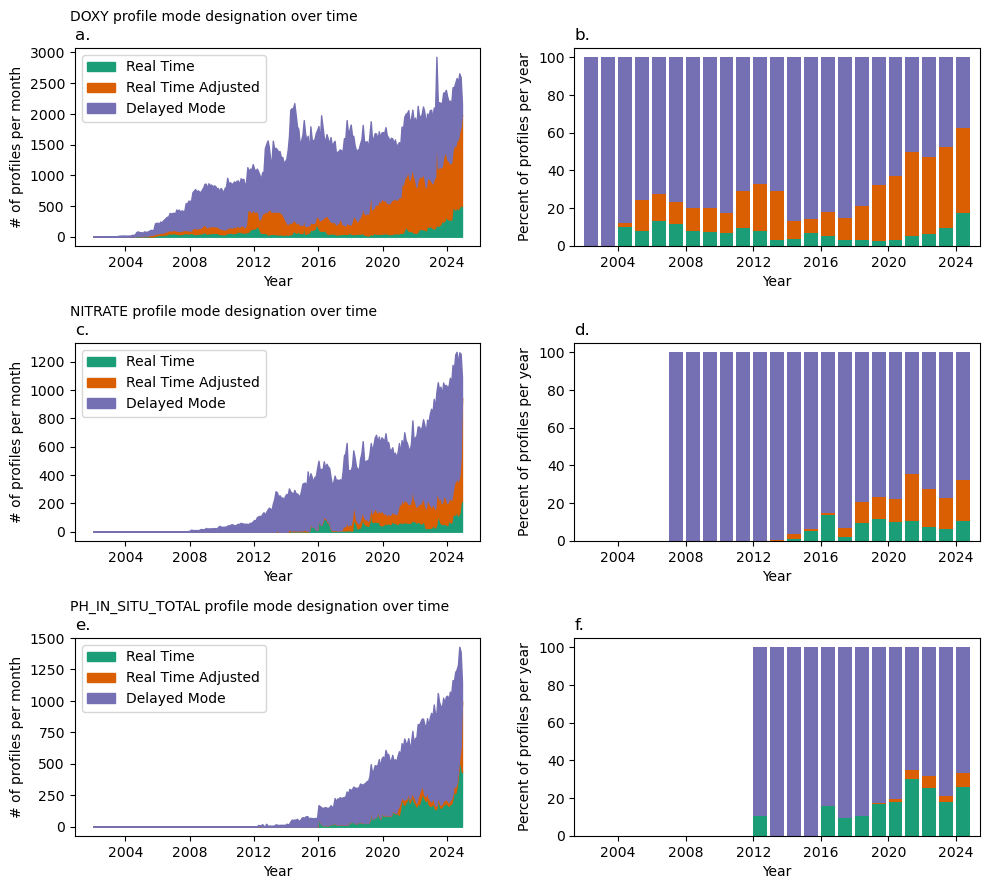

In [28]:
## Figure for manuscript
dac_filter = 0

if dac_filter==0:
    center_names = ['ALL']
else:
    center_names = np.unique(float_mode_df["Data Center"])

var_list = ['DOXY', 'NITRATE', 'PH_IN_SITU_TOTAL']
fig = plt.figure(figsize=(10,9))
color_map = plt.get_cmap('Dark2')
plot_count=0
for var in var_list:
    plot_count = plot_count + 1
    ax = fig.add_subplot(3,2,plot_count)
    print(var)
    for center in center_names:
        print(center)
        delayed_vec_count = []
        rta_vec_count = []
        real_time_vec_count = []
        date_vec = []

        # temp = float_mode_df.where(float_mode_df['Variable']==var).dropna(how='all')
        if dac_filter==0:
            temp = float_mode_df.where(float_mode_df['Variable'].str.contains(var, na=False)).dropna(how='all')
        else: 
            temp = float_mode_df.where(np.logical_and(float_mode_df['Variable'].str.contains(var, na=False), 
                               float_mode_df['Data Center'].str.contains(center, na=False))).dropna(how='all')
        
        temp_datetime = pd.to_datetime(temp['Profile Date'])
        for year_test in range(2002, 2025):
            # print(year_test)
            for month_test in range(1,13):
                month_day = temp.where(np.logical_and(temp_datetime.dt.year==year_test, temp_datetime.dt.month==month_test)).dropna(how='all')
                delayed_vec_count.append(np.sum(month_day["Profile Mode"]==2))
                rta_vec_count.append(np.sum(month_day["Profile Mode"]==1))
                real_time_vec_count.append(np.sum(month_day["Profile Mode"]==0))
                date_vec.append(pd.to_datetime({'year': [year_test], 'month': [month_test], 'day': [1]}).item())
            
        # print(delayed_vec_count)
        # print(rta_vec_count)
        # print(real_time_vec_count)

        plt.fill_between(date_vec, real_time_vec_count, 0, label = 'Real Time', color=color_map(0))
        plt.fill_between(date_vec, np.add(real_time_vec_count,rta_vec_count), real_time_vec_count, label='Real Time Adjusted', color=color_map(1))
        plt.fill_between(date_vec, np.add(np.add(real_time_vec_count,rta_vec_count),delayed_vec_count), np.add(real_time_vec_count,rta_vec_count), label='Delayed Mode', color=color_map(2))

        plt.legend()
        plt.ylabel('# of profiles per month')
        if plot_count==1:
            plt.title('a.', loc='left')
        elif plot_count==2:
            plt.title('b.', loc='left')
        elif plot_count==3: 
            plt.title('c.', loc='left')
        elif plot_count==4:
            plt.title('d.', loc='left')
        elif plot_count==5:
            plt.title('e.', loc='left')
        elif plot_count==6:
            plt.title('f.', loc='left')
        x_limits = ax.get_xlim()
        plt.text(x_limits[0]-100, max(np.add(np.add(real_time_vec_count,rta_vec_count),delayed_vec_count))*1.2, var + ' profile mode designation over time', ha='left')
        plt.xlabel('Year')

        # redo the counts per year for percent plots
        plot_count = plot_count + 1
        # break
        delayed_vec_count = []
        rta_vec_count = []
        real_time_vec_count = []
        date_vec = []
        ax = fig.add_subplot(3,2,plot_count)
        for year_test in range(2002, 2025):
            month_day = temp.where(temp_datetime.dt.year==year_test).dropna(how='all')
            delayed_vec_count.append(np.sum(month_day["Profile Mode"]==2))
            rta_vec_count.append(np.sum(month_day["Profile Mode"]==1))
            real_time_vec_count.append(np.sum(month_day["Profile Mode"]==0))
            date_vec.append(pd.to_datetime({'year': [year_test], 'month': [6], 'day': [1]}).item())
    

        total_profiles_per_year = np.add(np.add(real_time_vec_count,rta_vec_count),delayed_vec_count)
        percent_delayed = delayed_vec_count/total_profiles_per_year*100
        percent_rta = rta_vec_count/total_profiles_per_year*100
        percent_real_time = real_time_vec_count/total_profiles_per_year*100

        bar_width = 300
        plt.bar(date_vec, percent_real_time, width = bar_width, bottom=0, align="center", label = 'Real Time', color=color_map(0))
        plt.bar(date_vec, percent_rta, width = bar_width, bottom=percent_real_time, align="center", label = 'Real Time Adjusted', color=color_map(1))
        plt.bar(date_vec, percent_delayed, width = bar_width, bottom=np.add(percent_rta,percent_real_time), align="center", label = 'Delayed', color=color_map(2)) 

        print(f'Mean {var} % real time last 5 years: {np.nanmean(percent_real_time[-5:]):02f}')
        print(f'Mean {var} % real time adjusted last 5 years: {np.nanmean(percent_rta[-5:]):02f}')
        print(f'Mean {var} % delayed mode last 5 years: {np.nanmean(percent_delayed[-5:]):02f}')

        # l1 = plt.legend(loc="upper left")
        # l1.set_alpha(0.3)
        plt.ylabel('Percent of profiles per year')
        # plt.title(var + ' profile mode designation over time')
        plt.xlim([ pd.to_datetime({'year': [2001], 'month': [6], 'day': [1]}).item(), pd.to_datetime({'year': [2025], 'month': [6], 'day': [1]}).item()])
        plt.xlabel('Year')
        if plot_count==1:
            plt.title('a.', loc='left')
        elif plot_count==2:
            plt.title('b.', loc='left')
        elif plot_count==3: 
            plt.title('c.', loc='left')
        elif plot_count==4:
            plt.title('d.', loc='left')
        elif plot_count==5:
            plt.title('e.', loc='left')
        elif plot_count==6:
            plt.title('f.', loc='left')
    # break
plt.tight_layout()

plt.savefig(manuscript_figs + 'Figure_2_BGC_var_mode' + ' profile mode designation over time_DAC_' +  center + plot_ver +'.png')
# plt.close(fig)
        

In [ ]:
# Stacked bar version, using # per year:
var_list = ['DOXY', 'NITRATE', 'PH_IN_SITU_TOTAL', 'BBP', 'CDOM', 'CHLA_FLUORESCENCE', 'CP', 'DOWNWELLING_PAR', 'DOWN_IRRADIANCE', ' PRES', 'PSAL', 'TEMP', 'TURBIDITY', 'UP_RADIANCE']
# var_list = ['DOXY', 'BBP', 'CDOM', 'CP', 'DOWNWELLING_PAR', 'DOWN_IRRADIANCE', 'UP_RADIANCE']
# var_list = ['TURBIDITY']
for var in var_list:
    delayed_vec_count = []
    rta_vec_count = []
    real_time_vec_count = []
    date_vec = []

    # temp = float_mode_df.where(float_mode_df['Variable']==var).dropna(how='all')
    temp = float_mode_df.where(float_mode_df['Variable'].str.contains(var, na=False)).dropna(how='all')

    for year_test in range(2002, 2025):
        # print(year_test)
        # for month_test in range(1,13):
            month_day = temp.where(temp['Profile Date'].dt.year==year_test).dropna(how='all')
            delayed_vec_count.append(np.sum(month_day["Profile Mode"]==2))
            rta_vec_count.append(np.sum(month_day["Profile Mode"]==1))
            real_time_vec_count.append(np.sum(month_day["Profile Mode"]==0))
            date_vec.append(pd.to_datetime({'year': [year_test], 'month': [6], 'day': [1]}).item())
    
    total_profiles_per_month = np.add(np.add(real_time_vec_count,rta_vec_count),delayed_vec_count)
    percent_delayed = delayed_vec_count/total_profiles_per_month*100
    percent_rta = rta_vec_count/total_profiles_per_month*100
    percent_real_time = real_time_vec_count/total_profiles_per_month*100

    # print(delayed_vec_count)
    # print(rta_vec_count)
    # print(real_time_vec_count)

    fig = plt.figure(figsize=(6,4))
    plt.bar(date_vec, percent_real_time, width = 300, bottom=0, align="center", label = 'Real Time')
    plt.bar(date_vec, percent_rta, width = 300, bottom=percent_real_time, align="center", label = 'Real Time Adjusted')
    plt.bar(date_vec, percent_delayed, width = 300, bottom=np.add(percent_rta,percent_real_time), align="center", label = 'Delayed') 

    l1 = plt.legend(loc="upper left")
    l1.set_alpha(0.3)
    plt.ylabel('Percent of profiles per year')
    plt.title(var + ' profile mode designation over time')
    plt.xlim([ pd.to_datetime({'year': [2001], 'month': [6], 'day': [1]}).item(), pd.to_datetime({'year': [2025], 'month': [6], 'day': [1]}).item()])
    plt.xlabel('Year')
    plt.tight_layout()

    plt.savefig(manuscript_figs + 'profile_mode/' + var + ' percent profile mode designation over time.png')
    plt.close(fig)

/var/folders/7r/4f_w_nb56llcwh96t_pjq_qh0000gn/T/ipykernel_66213/3054239230.py:24: RuntimeWarning: invalid value encountered in divide
  percent_delayed = delayed_vec_count/total_profiles_per_month*100
/var/folders/7r/4f_w_nb56llcwh96t_pjq_qh0000gn/T/ipykernel_66213/3054239230.py:25: RuntimeWarning: invalid value encountered in divide
  percent_rta = rta_vec_count/total_profiles_per_month*100
/var/folders/7r/4f_w_nb56llcwh96t_pjq_qh0000gn/T/ipykernel_66213/3054239230.py:26: RuntimeWarning: invalid value encountered in divide
  percent_real_time = real_time_vec_count/total_profiles_per_month*100
/var/folders/7r/4f_w_nb56llcwh96t_pjq_qh0000gn/T/ipykernel_66213/3054239230.py:24: RuntimeWarning: invalid value encountered in divide
  percent_delayed = delayed_vec_count/total_profiles_per_month*100
/var/folders/7r/4f_w_nb56llcwh96t_pjq_qh0000gn/T/ipykernel_66213/3054239230.py:25: RuntimeWarning: invalid value encountered in divide
  percent_rta = rta_vec_count/total_profiles_per_month*100
/v

# Table of float and profile numbers w/ valid data of different modes

In [11]:
filtered_list = []
for file in os.listdir(output_dir):
    if file.endswith('Sprof_filtered.nc'):
        filtered_list.append(file)
filtered_list = np.sort(filtered_list)
print(len(filtered_list))

2429


In [12]:
outlier_list = []
for file in os.listdir(group_outlier_dir):
    if file.endswith('.csv'):
        outlier_list.append(file)
outlier_list = np.sort(outlier_list)

# print(len(outlier_list))

import io 

outlier_df = pd.read_csv(io.StringIO('\n'.join(outlier_list)), delimiter='_', header=None)
outlier_df.rename(columns={1: 'wmo', 4:'person', 5:'year', 6:'month', 7:'day', 8:'hour'}, inplace=True)

# remove all "bottomoxygen" files from the outlier_df:
outlier_df = outlier_df.where(outlier_df['person']!='bottomoxygen').dropna(how='all')
# remove all "automaticoutliers" files from the outlier_df:
outlier_df = outlier_df.where(outlier_df['person']!='automaticoutliers').dropna(how='all')

XXX_files = outlier_df.where(outlier_df['person']=='XXX').dropna(how='all')
print(str(len(np.unique(XXX_files['wmo']))) + ' files have missing/non-valid T, S, or BGC data')


1042 files have missing/non-valid T, S, or BGC data


In [154]:
import re

sensors_to_check = ['TEMP', 'PSAL', 'PRES', 'DOXY', 'NITRATE', 'PH_IN_SITU_TOTAL', 'BBP', 'CHLA', 'PAR']
total_floats_w_sensor = {} # total floats
total_floats_w_any_valid_adjusted_data = {} # total floats w/ adjusted data that is not all nan
total_floats_w_ANY_delayed_mode = {} # total floats with valid (non-nan) and any delayed mode profiles - these are the ones we have to QC
total_floats_w_nrt_but_no_DM = {} # these floats with any NRT profiles but not delayed mode. The assumption here is that if any data is getting put into delayed mode, then someone will either eventually put all into DM or there is a reason they do not. However, eventually we might want to QC these as well. 
total_floats_w_ALL_real_time = {}

total_profiles_w_sensor = {}
total_profiles_w_valid_adjusted_data = {}
total_profiles_w_delayed_mode = {}
total_profiles_w_nrt = {}
total_profiles_w_real_time = {}
doxy_wmo_list = []
# make a regex pattern to check against for argo_vars
pattern = '|'.join(sensors_to_check)
break_all=0
for var in sensors_to_check:
    total_floats_w_sensor[var]=[]
    total_floats_w_any_valid_adjusted_data[var]=[]
    total_floats_w_ANY_delayed_mode[var]=[]
    total_floats_w_nrt_but_no_DM[var]=[]
    total_floats_w_ALL_real_time[var]=[]

    total_profiles_w_sensor[var]=0
    total_profiles_w_valid_adjusted_data[var]=0
    total_profiles_w_delayed_mode[var]=0
    total_profiles_w_nrt[var]=0
    total_profiles_w_real_time[var]=0

for idx, file in enumerate(tqdm(filtered_list)):
    argo_n = xr.open_dataset(output_dir + file)
    argo_vars = list(argo_n.keys())

    # convert argo_vars to a series and look to see if there are matches to sensors_to_check
    argo_var_series = pd.Series(argo_vars)
    matches = argo_var_series[argo_var_series.str.contains(pattern)]

    profile_mode_vars = matches[matches.str.endswith('_profile_mode')]
    
    for pm_var in profile_mode_vars:
        # print(pm_var)
        # first, count existence of the float variable
        test = re.search(pattern, pm_var)
        if type(test)==re.Match:
            total_floats_w_sensor[test[0]].append(argo_n['WMO_ID'].values.item())
            total_profiles_w_sensor[test[0]]+= len(argo_n['N_PROF'])

            # find the actual variable name (in the case of BBP or PAR where there might be a few types)

            var_matches = argo_var_series[argo_var_series.str.endswith('_ADJUSTED')]
            try:
                var_name = var_matches[var_matches[var_matches.str.contains(test[0] + '_')].index[0]] # note - if multiple matches, just using the first
            except:
                var_name = var_matches[var_matches[var_matches.str.startswith(test[0])].index[0]] # note - if multiple matches, just using the first

            # check whether there is any valid data: 
            if np.sum(~np.isnan(argo_n[var_name]))>0:
                total_floats_w_any_valid_adjusted_data[test[0]].append(argo_n['WMO_ID'].values.item())

                # number of profiles w valid data:
                mask = ~np.isnan(argo_n[var_name]).values
                total_profiles_w_valid_adjusted_data[test[0]] += int(np.sum(np.any(mask, axis=1)))
            else:
                continue # if no valid data, do not count further
            # # check whether 95% of the variable profile modes are delayed mode:
            # if np.sum(argo_n[pm_var]==2)/len(argo_n['N_PROF'])>0.95:
            #     total_floats_w_mostly_delayed_mode[test[0]]+=1
            # check whether ANY variable profile modes are delayed mode w non nan data (these are ones we have to perform QC on):
            if np.sum(~np.isnan(argo_n[var_name].where(argo_n[pm_var]==2)))>0: #np.sum(argo_n[pm_var]==2)>0:
                # total_floats_w_ANY_delayed_mode[test[0]]+=1
                total_floats_w_ANY_delayed_mode[test[0]].append(argo_n['WMO_ID'].values.item())

                # now check if there is an 'XXX' file present for this float (looking at oxygen only)
                if test[0]=='DOXY':
                    doxy_wmo_list.append(argo_n['WMO_ID'].values)
                    if np.any(XXX_files['wmo'].values==argo_n['WMO_ID'].values):
                        print('XXX discrepancy for ' + str(argo_n['WMO_ID'].values) + ' variable: ' + test[0])
                        break_all=1
                        break
            else: # now check if there is any NRT with non-nan data but not DM
                if np.sum(~np.isnan(argo_n[var_name].where(argo_n[pm_var]==1)))>0:
                    total_floats_w_nrt_but_no_DM[test[0]].append(argo_n['WMO_ID'].values.item())

            # # check whether 95% of the variable profile modes are NRT:
            # if np.sum(argo_n[pm_var]==1)/len(argo_n['N_PROF'])>0.95:
            #     total_floats_w_mostly_nrt[test[0]]+=1

            # check whether all profile modes are real time:
            if np.sum(argo_n[pm_var]==0)==len(argo_n['N_PROF']):
                total_floats_w_ALL_real_time[test[0]].append(argo_n['WMO_ID'].values.item())
            
            # number of profiles of different modes:
            total_profiles_w_delayed_mode[test[0]]+= int(np.sum((argo_n[pm_var]==2).values))
            total_profiles_w_nrt[test[0]]+= int(np.sum((argo_n[pm_var]==1).values))
            total_profiles_w_real_time[test[0]]+= int(np.sum((argo_n[pm_var]==0).values))
    if break_all==1:
        break
    # if idx==10:
    #     break
    argo_n.close()
    
    # if total_floats_w_sensor['TEMP']<total_floats_w_sensor['DOXY']:
    #     break

print(total_floats_w_sensor)
print(total_floats_w_any_valid_adjusted_data)
print(total_floats_w_ANY_delayed_mode)
print(total_floats_w_nrt_but_no_DM)
print(total_floats_w_ALL_real_time)
print(' ')
print(total_profiles_w_sensor)
print(total_profiles_w_valid_adjusted_data)
print(total_profiles_w_delayed_mode)
print(total_profiles_w_nrt)
print(total_profiles_w_real_time)

100%|██████████| 2429/2429 [02:25<00:00, 16.74it/s]

{'TEMP': [1900650, 1900651, 1900652, 1900722, 1900943, 1901134, 1901135, 1901152, 1901153, 1901154, 1901155, 1901156, 1901157, 1901158, 1901159, 1901205, 1901206, 1901207, 1901208, 1901209, 1901210, 1901211, 1901212, 1901213, 1901214, 1901215, 1901217, 1901218, 1901329, 1901338, 1901339, 1901347, 1901348, 1901360, 1901361, 1901362, 1901363, 1901364, 1901365, 1901378, 1901379, 1901466, 1901467, 1901468, 1901498, 1901499, 1901501, 1901668, 1902303, 1902304, 1902332, 1902368, 1902369, 1902370, 1902371, 1902374, 1902380, 1902381, 1902382, 1902383, 1902384, 1902385, 1902453, 1902454, 1902455, 1902456, 1902457, 1902458, 1902459, 1902489, 1902490, 1902491, 1902492, 1902493, 1902494, 1902495, 1902496, 1902497, 1902498, 1902499, 1902500, 1902501, 1902578, 1902593, 1902594, 1902601, 1902602, 1902603, 1902604, 1902605, 1902621, 1902637, 1902643, 1902644, 1902646, 1902647, 1902648, 1902650, 1902651, 1902656, 1902657, 1902659, 1902662, 1902663, 1902666, 1902681, 1902682, 1902683, 1902685, 1902686, 

In [118]:
total_floats_w_any_valid_adjusted_data

{'TEMP': [1900650,
  1900651,
  1900652,
  1900722,
  1900943,
  1901134,
  1901135,
  1901152,
  1901153,
  1901154,
  1901155,
  1901156,
  1901157,
  1901158,
  1901159,
  1901205,
  1901206,
  1901207,
  1901208,
  1901209,
  1901210,
  1901211,
  1901212,
  1901213,
  1901214,
  1901215,
  1901217,
  1901218,
  1901329,
  1901338,
  1901339,
  1901347,
  1901348,
  1901360,
  1901361,
  1901362,
  1901363,
  1901364,
  1901365,
  1901378,
  1901379,
  1901466,
  1901467,
  1901468,
  1901498,
  1901499,
  1901501,
  1901668,
  1902303,
  1902304,
  1902332,
  1902380,
  1902381,
  1902382,
  1902383,
  1902384,
  1902385,
  1902453,
  1902454,
  1902455,
  1902456,
  1902457,
  1902458,
  1902459,
  1902489,
  1902490,
  1902491,
  1902492,
  1902493,
  1902494,
  1902495,
  1902496,
  1902497,
  1902498,
  1902499,
  1902500,
  1902501,
  1902593,
  1902602,
  1902603,
  1902604,
  1902621,
  1902643,
  1902644,
  1902646,
  1902647,
  1902648,
  1902650,
  1902651,
  1902662,
  

In [106]:
# DUPLICATE WMO ANALYSIS: Find why set(np.int64(doxy_wmo_list)) length decreases
from collections import defaultdict, Counter

print("=== DUPLICATE WMO FLOAT ANALYSIS ===")
print(f"Original doxy_wmo_list length: {len(doxy_wmo_list)}")

# Step 1: Convert to int64 and check for issues
int_values = []
conversion_errors = []
nan_count = 0

for i, wmo_array in enumerate(doxy_wmo_list):
    try:
        if np.isnan(wmo_array):
            nan_count += 1
        else:
            int_val = np.int64(wmo_array)
            int_values.append((i, int_val))  # Store index and value
    except Exception as e:
        conversion_errors.append((i, wmo_array, str(e)))

print(f"Successfully converted: {len(int_values)}")
print(f"NaN values found: {nan_count}")  
print(f"Conversion errors: {len(conversion_errors)}")

# Step 2: Find duplicates with their indices
value_to_indices = defaultdict(list)
for idx, int_val in int_values:
    value_to_indices[int_val].append(idx)

# Step 3: Identify duplicates
duplicate_groups = {val: indices for val, indices in value_to_indices.items() if len(indices) > 1}
unique_count = len(value_to_indices)

print(f"\nDUPLICATE ANALYSIS:")
print(f"Unique WMO values: {unique_count}")
print(f"Total duplicate groups: {len(duplicate_groups)}")

if duplicate_groups:
    total_duplicates = sum(len(indices) - 1 for indices in duplicate_groups.values())
    print(f"Total duplicate entries: {total_duplicates}")
    
    print(f"\n--- DUPLICATE WMO DETAILS ---")
    print("Showing first 10 duplicate groups:")
    
    for i, (wmo_val, indices) in enumerate(list(duplicate_groups.items())[:10]):
        print(f"\nWMO {wmo_val}: appears {len(indices)} times")
        print(f"  At indices: {indices}")
        
        # Show the actual array values to confirm they're identical
        actual_values = [doxy_wmo_list[idx] for idx in indices]
        print(f"  Actual values: {actual_values}")
        
        # Show if they're consecutive (might indicate a data loading issue)
        consecutive = all(indices[j] == indices[j-1] + 1 for j in range(1, len(indices)))
        if consecutive:
            print(f"  → Consecutive indices (possible data loading issue)")
    
    if len(duplicate_groups) > 10:
        print(f"\n... and {len(duplicate_groups) - 10} more duplicate groups")
    
    # Pattern analysis
    consecutive_pairs = sum(1 for indices in duplicate_groups.values() 
                          if len(indices) == 2 and indices[1] == indices[0] + 1)
    
    print(f"\nPATTERN ANALYSIS:")
    print(f"Consecutive duplicate pairs: {consecutive_pairs}")
    print(f"Other duplicate patterns: {len(duplicate_groups) - consecutive_pairs}")

# Step 4: Summary
print(f"\n=== SUMMARY ===")
print(f"Original length: {len(doxy_wmo_list)}")
print(f"After set conversion: {unique_count}")
print(f"Length decrease: {len(doxy_wmo_list) - unique_count}")
print(f"  - Due to NaN: {nan_count}")
print(f"  - Due to duplicates: {len(doxy_wmo_list) - nan_count - len(conversion_errors) - unique_count}")
print(f"  - Due to conversion errors: {len(conversion_errors)}")

# Verification
set_length = len(set(np.int64([wmo for wmo in doxy_wmo_list if not np.isnan(wmo)])))
print(f"Verification - direct set conversion: {set_length}")

=== DUPLICATE WMO FLOAT ANALYSIS ===
Original doxy_wmo_list length: 1402
Successfully converted: 1402
NaN values found: 0
Conversion errors: 0

DUPLICATE ANALYSIS:
Unique WMO values: 1381
Total duplicate groups: 17
Total duplicate entries: 21

--- DUPLICATE WMO DETAILS ---
Showing first 10 duplicate groups:

WMO 4900476: appears 2 times
  At indices: [310, 311]
  Actual values: [array(4900476), array(4900476)]
  → Consecutive indices (possible data loading issue)

WMO 4900477: appears 2 times
  At indices: [312, 313]
  Actual values: [array(4900477), array(4900477)]
  → Consecutive indices (possible data loading issue)

WMO 4900482: appears 2 times
  At indices: [316, 317]
  Actual values: [array(4900482), array(4900482)]
  → Consecutive indices (possible data loading issue)

WMO 4900484: appears 2 times
  At indices: [319, 320]
  Actual values: [array(4900484), array(4900484)]
  → Consecutive indices (possible data loading issue)

WMO 4900485: appears 2 times
  At indices: [321, 322]


In [120]:
len(set(np.unique(total_floats_w_any_valid_adjusted_data['DOXY'])))

1901

In [122]:
len(set(total_floats_w_any_valid_adjusted_data[sensor]))


124

## Create Pandas dataframes with appropriate values

In [147]:
# create a table with sensor type counts
# initialize dataframe with columns for each sensor and rows for each count type
count_types = ['Total Floats', 'Valid "ADJUSTED"', 'Any Valid DM', 'RTA but no DM', 'All RT']
summary_df = pd.DataFrame(index=count_types, columns=sensors_to_check)
# fill in the dataframe
for sensor in sensors_to_check:
    summary_df.at['Total Floats', sensor] = len(set(total_floats_w_sensor[sensor]))
    summary_df.at['Valid "ADJUSTED"', sensor] = len(set(total_floats_w_any_valid_adjusted_data[sensor]))
    summary_df.at['Any Valid DM', sensor] = len(set(total_floats_w_ANY_delayed_mode[sensor]))
    summary_df.at['RTA but no DM', sensor] = len(set(total_floats_w_nrt_but_no_DM[sensor]))
    summary_df.at['All RT', sensor] = len(set(total_floats_w_ALL_real_time[sensor]))

print(summary_df)

                  TEMP  PSAL  PRES  DOXY NITRATE PH_IN_SITU_TOTAL   BBP  CHLA  \
Total Floats      2429  2429  2429  2244     807              724  1129  1144   
Valid "ADJUSTED"  2039  2029  2039  1901     715              532   958  1100   
Any Valid DM      1608  1594  1608  1381     619              480    93    54   
RTA but no DM      402   406   402   519      96               52   865  1097   
All RT              29    29    29     4       0                0    15     2   

                  PAR  
Total Floats      356  
Valid "ADJUSTED"  124  
Any Valid DM      124  
RTA but no DM       0  
All RT              0  


In [124]:
# get float dictionaires into pandas dataframe
# total_floats_w_sensor_df = pd.DataFrame(total_floats_w_sensor, index = ['Total floats'], columns=sensors_to_check)
# total_floats_w_any_valid_adjusted_data_df = pd.DataFrame(total_floats_w_any_valid_adjusted_data, index = ['Valid "ADJUSTED"'], columns=sensors_to_check)
# total_floats_w_mostly_delayed_mode_df = pd.DataFrame(total_floats_w_mostly_delayed_mode, index = [r'>\SI{95}{\percent} Delayed Mode'], columns=sensors_to_check)
# total_floats_w_mostly_nrt_df = pd.DataFrame(total_floats_w_mostly_nrt, index = [r'>\SI{95}{\percent} Real Time Adjusted'], columns=sensors_to_check)
# total_floats_w_mostly_real_time_df = pd.DataFrame(total_floats_w_mostly_real_time, index = [r'>\SI{95}{\percent} Real Time'], columns=sensors_to_check)

# float_numbers_df = pd.concat([total_floats_w_sensor_df, total_floats_w_any_valid_adjusted_data_df, total_floats_w_mostly_delayed_mode_df, total_floats_w_mostly_nrt_df, total_floats_w_mostly_real_time_df])
# float_numbers_df

ValueError: Length of values (2429) does not match length of index (1)

In [148]:
# get profile dictionaires into pandas dataframe
total_profiles_w_sensor_df = pd.DataFrame(total_profiles_w_sensor, index = ['Total profiles'], columns=sensors_to_check)
total_profiles_w_valid_adjusted_data_df = pd.DataFrame(total_profiles_w_valid_adjusted_data, index = ['Valid "ADJUSTED"'], columns=sensors_to_check)
total_profiles_w_delayed_mode_df = pd.DataFrame(total_profiles_w_delayed_mode, index = [r'DM'], columns=sensors_to_check)
total_profiles_w_nrt_df = pd.DataFrame(total_profiles_w_nrt, index = [r'RTA'], columns=sensors_to_check)
total_profiles_w_real_time_df = pd.DataFrame(total_profiles_w_real_time, index = [r'RT'], columns=sensors_to_check)

profile_numbers_df = pd.concat([total_profiles_w_sensor_df, total_profiles_w_valid_adjusted_data_df, total_profiles_w_delayed_mode_df, total_profiles_w_nrt_df, total_profiles_w_real_time_df])
profile_numbers_df

,TEMP,PSAL,PRES,DOXY,NITRATE,PH_IN_SITU_TOTAL,BBP,CHLA,PAR
Total profiles,332914,332914,332914,323788,91118,68650,166412,274706,68844
"Valid ""ADJUSTED""",293142,281321,293822,277543,73037,34199,114952,238696,26299
DM,241618,240046,241618,210880,67756,46278,17042,8960,26873
RTA,50944,50944,50944,84123,11534,2536,95344,227258,0
RT,5604,5604,5604,2708,401,541,8299,9409,586


## Save dataframes as csvs for later use

In [149]:
# save out for later use:
summary_df.to_csv(manuscript_dir + 'Dataset paper group folder/Data/' + 'float_mode_info' + plot_ver + '.csv', index=True )
profile_numbers_df.to_csv(manuscript_dir + 'Dataset paper group folder/Data/' + 'profile_mode_info' + plot_ver + '.csv', index=True )

## Optional: load existing dataframes to avoid re-processing the entire float dataset

In [150]:
# load the saved tables 
float_numbers_df = pd.read_csv(manuscript_dir + 'Dataset paper group folder/Data/' + 'float_mode_info' + plot_ver + '.csv', index_col=0 )
profile_numbers_df = pd.read_csv(manuscript_dir + 'Dataset paper group folder/Data/' + 'profile_mode_info' + plot_ver + '.csv', index_col=0 )
print(float_numbers_df)
print(profile_numbers_df)

                  TEMP  PSAL  PRES  DOXY  NITRATE  PH_IN_SITU_TOTAL   BBP  \
Total Floats      2429  2429  2429  2244      807               724  1129   
Valid "ADJUSTED"  2039  2029  2039  1901      715               532   958   
Any Valid DM      1608  1594  1608  1381      619               480    93   
RTA but no DM      402   406   402   519       96                52   865   
All RT              29    29    29     4        0                 0    15   

                  CHLA  PAR  
Total Floats      1144  356  
Valid "ADJUSTED"  1100  124  
Any Valid DM        54  124  
RTA but no DM     1097    0  
All RT               2    0  
                    TEMP    PSAL    PRES    DOXY  NITRATE  PH_IN_SITU_TOTAL  \
Total profiles    332914  332914  332914  323788    91118             68650   
Valid "ADJUSTED"  293142  281321  293822  277543    73037             34199   
DM                241618  240046  241618  210880    67756             46278   
RTA                50944   50944   50944 

In [25]:
float_numbers_df.index

Index(['Total floats', 'Valid "ADJUSTED"', '>\SI{95}{\percent} Delayed Mode',
       '>\SI{95}{\percent} Real Time Adjusted',
       '>\SI{95}{\percent} Real Time'],
      dtype='object')

In [13]:
column_name = 'PH_IN_SITU_TOTAL'
# check if column_name contains underscores and add backslashes for LaTeX if so
if '_' in column_name:
    column_name_latex = column_name.replace('_', r'\_')
else:
    column_name_latex = column_name

## Table 1

In [151]:
# create a table for manuscript in latex
# print(r"\multicolumn{1}{l}{\\textbf{Float numbers}} \\\\ \midrule")
print(r"\small")
print(r'\begin{center}')
print(r'\begin{table}')
print(r'\caption{Numbers of floats and profiles with different sensors and data modes}')
print(r'\begin{tabular}{ r', end='')

sensor_names = float_numbers_df.keys()
for s in sensor_names:
    print('|c', end='')
print(r'}')
# print(r'\textbf{Float numbers}: & & & & & & & & \\')
print(r'\multicolumn{10}{l}{Numbers of floats with sensor types:}\\')
print(r'\hline')

# print(r'\\')

# print header row
print(' ' + ' & ', end='') 
for c_idx, column_name in enumerate(float_numbers_df.columns):
    if '_' in column_name:
        column_name_latex = column_name.replace('_', r'\_')
    else:
        column_name_latex = column_name
    print(column_name_latex , end='')
    if c_idx<len(float_numbers_df.columns)-1:
        print(' & ', end='')
print(r'\\')
print(r'\hline')

for idx, row_name in enumerate(float_numbers_df.index):
    values = float_numbers_df.loc[row_name,:]

    row_name = row_name.replace('Valid ', '')
    row_name = row_name.replace('Delayed Mode', 'DM')
    row_name = row_name.replace('Real Time Adjusted', 'RTA')
    row_name = row_name.replace('Real Time', 'RT')

    # print each row of data
    print(row_name + ' & ', end='') 

    for c_idx, column_name in enumerate(values.keys()):
        print(f"{values[column_name]:,d}",end='')
        if c_idx<len(values.keys())-1:
            print(' & ', end='')
    print(r'\\')


# Profile numbers 
print(r'\multicolumn{10}{l}{ }\\')
print(r'\multicolumn{10}{l}{Numbers of profiles with sensor types:}\\')
print(r'\hline')
# print header row
print(' ' + ' & ', end='') 
for c_idx, column_name in enumerate(float_numbers_df.columns):
    if '_' in column_name:
        column_name_latex = column_name.replace('_', r'\_')
    else:
        column_name_latex = column_name
    print(column_name_latex , end='')
    if c_idx<len(float_numbers_df.columns)-1:
        print(' & ', end='')
print(r'\\')
print(r'\hline')
# print(r'\\')

for idx, row_name in enumerate(profile_numbers_df.index):
    values = profile_numbers_df.loc[row_name,:]

    row_name = row_name.replace('Valid ', '')
    row_name = row_name.replace('Delayed Mode', 'DM')
    row_name = row_name.replace('Real Time Adjusted', 'RTA')
    row_name = row_name.replace('Real Time', 'RT')

    print(row_name + ' & ', end='') 

    for c_idx, column_name in enumerate(values.keys()):
        # print(str(values[column_name]) , end='')
        print(f"{values[column_name]:,d}",end='')
        if c_idx<len(values.keys())-1:
            print(' & ', end='')
    print(r'\\')


print(r'\end{tabular}')
print(r'\belowtable{DM = Delayed Mode, RTA = Real Time Adjusted, RT = Real Time}')
print(r'\label{tab:float_profile_mode_counts}')
print(r'\end{table}')
print(r'\end{center}')
print(r'\normalsize')


\small
\begin{center}
\begin{table}
\caption{Numbers of floats and profiles with different sensors and data modes}
\begin{tabular}{ r|c|c|c|c|c|c|c|c|c}
\multicolumn{10}{l}{Numbers of floats with sensor types:}\\
\hline
  & TEMP & PSAL & PRES & DOXY & NITRATE & PH\_IN\_SITU\_TOTAL & BBP & CHLA & PAR\\
\hline
Total Floats & 2,429 & 2,429 & 2,429 & 2,244 & 807 & 724 & 1,129 & 1,144 & 356\\
"ADJUSTED" & 2,039 & 2,029 & 2,039 & 1,901 & 715 & 532 & 958 & 1,100 & 124\\
Any DM & 1,608 & 1,594 & 1,608 & 1,381 & 619 & 480 & 93 & 54 & 124\\
RTA but no DM & 402 & 406 & 402 & 519 & 96 & 52 & 865 & 1,097 & 0\\
All RT & 29 & 29 & 29 & 4 & 0 & 0 & 15 & 2 & 0\\
\multicolumn{10}{l}{ }\\
\multicolumn{10}{l}{Numbers of profiles with sensor types:}\\
\hline
  & TEMP & PSAL & PRES & DOXY & NITRATE & PH\_IN\_SITU\_TOTAL & BBP & CHLA & PAR\\
\hline
Total profiles & 332,914 & 332,914 & 332,914 & 323,788 & 91,118 & 68,650 & 166,412 & 274,706 & 68,844\\
"ADJUSTED" & 293,142 & 281,321 & 293,822 & 277,543 & 73,03

# Evaluating pH / pCO2 dataset for any improvment due to outlier removal

In [3]:
#### Load pH list saved from Float_Processing
float_pH_list = np.load('../plotting_scripts/pH_file_list.npy')
print(len(float_pH_list))

438


In [ ]:
wmo = '5904841'
argo_n = xr.open_dataset(output_dir +  wmo + '_Sprof_BGCArgoPlus_full.nc')
argo_orig = xr.open_dataset(output_dir +  wmo + '_Sprof_processed_flags_mode_only.nc')

In [26]:
pH_BGCArgoPlus = argo_n['PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus'].values
pH_orig = argo_orig['PH_IN_SITU_TOTAL_ADJUSTED_RO'].values

# check for any differences:
for i in range(len(argo_n['N_PROF'])):
    pH_BGCArgoPlus_profile = pH_BGCArgoPlus[i,:]
    pH_orig_profile = pH_orig[i,:]
    if not np.array_equal(pH_BGCArgoPlus_profile, pH_orig_profile):
        print(f'Differences found in profile {i} of float {wmo}')
        # print('BGCArgoPlus pH values: ', pH_BGCArgoPlus_profile)
        # print('Original pH values: ', pH_orig_profile)


Differences found in profile 0 of float 5904841
Differences found in profile 1 of float 5904841
Differences found in profile 2 of float 5904841
Differences found in profile 3 of float 5904841
Differences found in profile 4 of float 5904841
Differences found in profile 5 of float 5904841
Differences found in profile 6 of float 5904841
Differences found in profile 7 of float 5904841
Differences found in profile 8 of float 5904841
Differences found in profile 9 of float 5904841
Differences found in profile 10 of float 5904841
Differences found in profile 11 of float 5904841
Differences found in profile 12 of float 5904841
Differences found in profile 13 of float 5904841
Differences found in profile 14 of float 5904841
Differences found in profile 15 of float 5904841
Differences found in profile 16 of float 5904841
Differences found in profile 17 of float 5904841
Differences found in profile 18 of float 5904841
Differences found in profile 19 of float 5904841
Differences found in profile 2

In [30]:
argo_n['PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus_flag'].values

array('F_DMonly_S_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_OR_',
      dtype='<U221')

In [32]:
argo_n['PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus'][0,:].values

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

In [33]:
argo_orig['PH_IN_SITU_TOTAL_ADJUSTED_RO'][0,:].values

array([      nan,       nan, 8.021789 ,       nan,       nan, 8.025506 ,
             nan,       nan,       nan, 8.029939 ,       nan,       nan,
       8.030637 ,       nan,       nan,       nan, 8.032225 ,       nan,
             nan, 8.031385 ,       nan,       nan, 8.031591 ,       nan,
             nan, 8.03309  ,       nan,       nan,       nan, 8.031741 ,
             nan,       nan, 8.035286 ,       nan,       nan,       nan,
       8.036502 ,       nan,       nan, 8.038743 ,       nan,       nan,
             nan, 8.041023 ,       nan,       nan, 8.03907  ,       nan,
             nan,       nan, 8.036597 ,       nan,       nan, 8.033586 ,
             nan,       nan,       nan, 8.031106 ,       nan,       nan,
       8.029848 ,       nan,       nan,       nan, 8.021545 ,       nan,
             nan, 8.015701 ,       nan,       nan,       nan,       nan,
             nan, 8.006095 ,       nan,       nan,       nan,       nan,
             nan, 7.9987197,       nan,       nan, 

In [51]:
prof_diff = pH_BGCArgoPlus[0,:] - pH_orig[0,:]

np.nanmax(prof_diff)

float_profile_dates = argo_n.JULD.values

# save out uppder 10m values for all profiles 
for i in range(len(argo_n['N_PROF'])):
    # get upper 10m mean for BGCArgoPlus pH
    pH_data = argo_n['PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus'][i,:].values
    pH_data_orig = argo_orig['PH_IN_SITU_TOTAL_ADJUSTED_RO'][i,:].values

    pCO2_data = argo_n['PCO2_BGCArgoPlus'][i,:].values
    pCO2_data_orig = argo_orig['pCO2_ADJUSTED_RO'][i,:].values

    prof_depths = argo_n['PRES'][i,:].values
    upper_10m_mask = prof_depths <=10
    if np.sum(~np.isnan(pH_data_orig[upper_10m_mask]))>0:
        upper_10m_mean = np.nanmean(pH_data[upper_10m_mask])
        upper_10m_mean_orig = np.nanmean(pH_data_orig[upper_10m_mask])

        if ~np.isnan(pCO2_data[upper_10m_mask]).all():
            upper_10m_pCO2_mean = np.nanmean(pCO2_data[upper_10m_mask])
        else:
            upper_10m_pCO2_mean = np.nan

        if ~np.isnan(pCO2_data_orig[upper_10m_mask]).all():
            upper_10m_mean_pCO2_orig = np.nanmean(pCO2_data_orig[upper_10m_mask])
        else:
            upper_10m_mean_pCO2_orig = np.nan
    else:
        continue
    break
print(i)
print(upper_10m_mean)
print(upper_10m_mean_orig)


0
nan
8.021789


/var/folders/7r/4f_w_nb56llcwh96t_pjq_qh0000gn/T/ipykernel_96574/4017381457.py:3: RuntimeWarning: All-NaN slice encountered
  np.nanmax(prof_diff)
/var/folders/7r/4f_w_nb56llcwh96t_pjq_qh0000gn/T/ipykernel_96574/4017381457.py:19: RuntimeWarning: Mean of empty slice
  upper_10m_mean = np.nanmean(pH_data[upper_10m_mask])


In [48]:
pH_data[upper_10m_mask]
pH_data_orig[upper_10m_mask]

array([     nan,      nan, 8.021789,      nan,      nan], dtype=float32)

In [63]:
# loop through each float, save out a dataframe with wmo, date, lat/lon, PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus (from BGCArgoPlus files)
# PH_IN_SITU_TOTAL_ADJUSTED_RO from flag/mode only files
dict_var_list = ["WMO", "Profile Date", "Lat", "Lon", "PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus", "PH_IN_SITU_TOTAL_ADJUSTED_orig", "PCO2_BGCArgoPlus", "PCO2_orig"]

float_pH_dict = {}
for key in dict_var_list:
    float_pH_dict[key] = []
for idx, file in enumerate(tqdm(float_pH_list)):
    try:
        argo_n = xr.open_dataset(output_dir +  file[0:7] + '_Sprof_BGCArgoPlus_full.nc')
        argo_orig = xr.open_dataset(output_dir +  file[0:7] + '_Sprof_BGCArgoPlus_flags_mode_only.nc')
    except:
        print(f'Could not open files for float {file[0:7]}')
        continue
    float_profile_dates = argo_n.JULD.values

    # save out uppder 10m values for all profiles 
    for i in range(len(argo_n['N_PROF'])):
        # get upper 10m mean for BGCArgoPlus pH
        pH_data = argo_n['PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus'][i,:].values
        pH_data_orig = argo_orig['PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus'][i,:].values

        pCO2_data = argo_n['PCO2_BGCArgoPlus'][i,:].values
        pCO2_data_orig = argo_orig['PCO2_BGCArgoPlus'][i,:].values

        prof_depths = argo_n['PRES'][i,:].values
        upper_10m_mask = prof_depths <=10
        if np.sum(~np.isnan(pH_data_orig[upper_10m_mask]))>0:
            if ~np.isnan(pH_data[upper_10m_mask]).all():
                upper_10m_mean = np.nanmean(pH_data[upper_10m_mask])
            else:
                upper_10m_mean = np.nan
            upper_10m_mean_orig = np.nanmean(pH_data_orig[upper_10m_mask])

            if ~np.isnan(pCO2_data[upper_10m_mask]).all():
                upper_10m_pCO2_mean = np.nanmean(pCO2_data[upper_10m_mask])
            else:
                upper_10m_pCO2_mean = np.nan

            if ~np.isnan(pCO2_data_orig[upper_10m_mask]).all():
                upper_10m_mean_pCO2_orig = np.nanmean(pCO2_data_orig[upper_10m_mask])
            else:
                upper_10m_mean_pCO2_orig = np.nan
        else:
            continue

        float_pH_dict["WMO"].append(argo_n.WMO_ID.values)
        float_pH_dict["Profile Date"].append(float_profile_dates[i])
        float_pH_dict["Lat"].append(argo_n['LATITUDE'][i].values)
        float_pH_dict["Lon"].append(argo_n['LONGITUDE'][i].values)
        
        float_pH_dict["PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus"].append(upper_10m_mean)
        float_pH_dict["PH_IN_SITU_TOTAL_ADJUSTED_orig"].append(upper_10m_mean_orig)
        float_pH_dict["PCO2_BGCArgoPlus"].append(upper_10m_pCO2_mean)
        float_pH_dict["PCO2_orig"].append(upper_10m_mean_pCO2_orig)
    
    argo_n.close()
    argo_orig.close()

    if idx==10:
        break
float_pH_df = pd.DataFrame.from_dict(float_pH_dict)
float_pH_df

  2%|▏         | 10/438 [00:04<02:55,  2.43it/s]


,WMO,Profile Date,Lat,Lon,PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus,PH_IN_SITU_TOTAL_ADJUSTED_orig,PCO2_BGCArgoPlus,PCO2_orig
0,1902303,2021-05-06 02:03:16.000218880,49.236,-14.742,8.081067,8.081067,376.227964,368.234090
1,1902303,2021-05-06 19:32:57.002084864,49.096,-14.617,8.080843,8.080843,376.461881,368.433919
2,1902303,2021-05-07 20:05:38.002153216,48.914,-14.606,8.081219,8.081219,376.162304,368.123487
3,1902303,2021-05-08 22:42:52.002421248,48.794,-14.689,8.072054,8.072054,385.279765,377.167987
4,1902303,2021-05-09 20:29:00.002187776,48.719,-14.795,8.072094,8.072094,385.248649,377.139489
...,...,...,...,...,...,...,...,...
480,1902385,2023-01-09 10:13:02.001091584,25.283,-59.316,8.054578,8.054578,407.694499,397.458922
481,1902385,2023-01-19 10:32:31.001119488,25.24,-59.002,8.047913,8.047913,415.394292,405.009630
482,1902385,2023-01-29 09:37:58.001018880,25.088,-58.816,8.053720,8.053720,409.694113,399.464809
483,1902385,2023-02-08 10:47:30.001141248,24.693,-58.634,8.047148,8.047148,419.351436,408.955306


In [10]:
float_pH_df = pd.DataFrame.from_dict(float_pH_dict)
float_pH_df

,WMO,Profile Date,Lat,Lon,PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus,PH_IN_SITU_TOTAL_ADJUSTED_orig,PCO2_BGCArgoPlus,PCO2_orig
0,1902303,2021-05-06 02:03:16.000218880,49.236,-14.742,8.081067,8.081067,376.227964,365.103201
1,1902303,2021-05-06 19:32:57.002084864,49.096,-14.617,8.080843,8.080843,376.461881,NaN
2,1902303,2021-05-07 20:05:38.002153216,48.914,-14.606,8.081219,8.081219,376.162304,366.858080
3,1902303,2021-05-08 22:42:52.002421248,48.794,-14.689,8.072054,8.072054,385.279765,374.118129
4,1902303,2021-05-09 20:29:00.002187776,48.719,-14.795,8.072094,8.072094,385.248649,375.408585
...,...,...,...,...,...,...,...,...
25856,5907061,2024-11-13 18:16:46.001954304,21.7437,-152.6271,8.016894,8.016894,NaN,NaN
25857,5907061,2024-11-18 23:55:33.002547200,21.6271,-152.6434,8.019913,8.019913,NaN,NaN
25858,5907061,2024-11-24 06:02:59.000646656,21.5532,-152.6588,8.013269,8.013269,NaN,NaN
25859,5907061,2024-11-29 10:33:07.001120768,21.5451,-152.6498,8.014861,8.014861,NaN,NaN


In [21]:
PH_diff = float_pH_df['PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus'] - float_pH_df['PH_IN_SITU_TOTAL_ADJUSTED_orig']
np.max(PH_diff)

0.0

(0.0, 45.0)

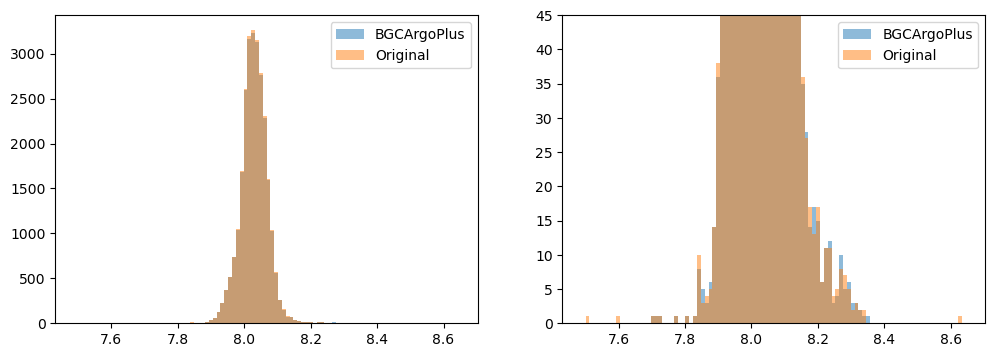

In [62]:
range_min = np.nanmin(np.concatenate((float_pH_df['PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus'].values, float_pH_df['PH_IN_SITU_TOTAL_ADJUSTED_orig'].values)))
range_max = np.nanmax(np.concatenate((float_pH_df['PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus'].values, float_pH_df['PH_IN_SITU_TOTAL_ADJUSTED_orig'].values)))

fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(1,2,1)
ax.hist(float_pH_df['PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus'], range=(range_min-.02,range_max+.02), bins=100, alpha=0.5, label='BGCArgoPlus')
ax.hist(float_pH_df['PH_IN_SITU_TOTAL_ADJUSTED_orig'], range=(range_min-.02,range_max+.02), bins=100, alpha=0.5, label='Original')
ax.legend()
ax.set_yscale('linear')

ax2 = fig.add_subplot(1,2,2)
ax2.hist(float_pH_df['PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus'], range=(range_min-.02,range_max+.02), bins=100, alpha=0.5, label='BGCArgoPlus')
ax2.hist(float_pH_df['PH_IN_SITU_TOTAL_ADJUSTED_orig'], range=(range_min-.02,range_max+.02), bins=100, alpha=0.5, label='Original')
ax2.legend()
ax2.set_yscale('linear')
ax2.set_ylim([0,45])

In [ ]:
# split by month and by hemisphere to see if there are seasonal differences
float_pH_df['Month'] = pd.to_datetime(float_pH_df['Profile Date']).dt.month
float_pH_df['Hemisphere'] = np.where(float_pH_df['Lat']>=0, 'Northern', 'Southern')
for hemisphere in ['Northern', 'Southern']:
    print(hemisphere)
    for month in range(1,13):
        print(month)
        month_mask = float_pH_df['Month']==month
        hemisphere_mask = float_pH_df['Hemisphere']==hemisphere
        combined_mask = np.logical_and(month_mask, hemisphere_mask)
        plt.figure(figsize=(6,4))
        plt.hist(float_pH_df['PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus'][combined_mask], range=(range_min-.02,range_max+.02), bins=50, alpha=0.5, label='BGCArgoPlus')
        plt.hist(float_pH_df['PH_IN_SITU_TOTAL_ADJUSTED_orig'][combined_mask], range=(range_min-.02,range_max+.02), bins=50, alpha=0.5, label='Original')
        plt.legend()
        plt.title(f'pH Distribution in {hemisphere} Hemisphere - Month {month}')
        plt.yscale('log')
        plt.xlabel('Upper 10m Mean pH')
        plt.ylabel('Number of Profiles')
        plt.tight_layout()
        plt.savefig(manuscript_figs + f'pH_distribution_{hemisphere}_month_{month}.png')
        plt.close()

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 2.,
        1., 0., 0., 1., 2., 0., 2., 1., 3., 0., 0., 0., 2., 1., 2., 1., 0.,
        1., 1., 2., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0.,
        0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([8.05233097, 8.052742  , 8.05315399, 8.05356503, 8.05397606,
        8.05438805, 8.05479908, 8.05521011, 8.0556221 , 8.05603313,
        8.05644417, 8.05685616, 8.05726719, 8.05767918, 8.05809021,
        8.05850124, 8.05891323, 8.05932426, 8.0597353 , 8.06014729,
        8.06055832, 8.06096935, 8.06138134, 8.06179237, 8.06220341,
        8.06261539, 8.06302643, 8.06343746, 8.06384945, 8.06426048,
        8.06467247, 8.0650835 , 8.06549454, 8.06590652, 8.06631756,
        8.06672859, 8.06714058, 8.06755161, 8.06796265, 8.06837463,
      

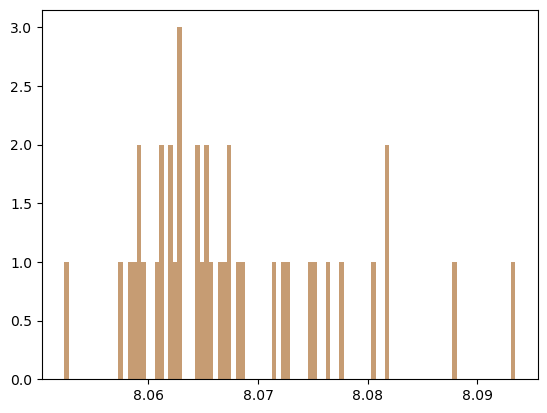

In [383]:
plt.hist(argo_n['PH_IN_SITU_TOTAL_ADJUSTED_BGCArgoPlus'][:,0], bins=100, alpha=0.5, label='Outlier removed')
plt.hist(argo_orig['PH_IN_SITU_TOTAL_ADJUSTED_RO'][:,0], bins=100, alpha=0.5, label='Orig')

# Assessing prevalence of surface outliers

In [3]:
argolist = []
for file in os.listdir(output_dir):
    if file.endswith('Sprof_flags_mode_only.nc'):
        argolist.append(file)
print(len(argolist))

2229


In [102]:
file = '6901519_Sprof_flags_mode_only.nc'

argo_n = xr.open_dataset(output_dir + file)
argo_n

<xarray.Dataset> Size: 104MB
Dimensions:                                       (N_PROF: 177, N_PARAM: 12,
                                                   N_CALIB: 1, N_LEVELS: 1366)
Dimensions without coordinates: N_PROF, N_PARAM, N_CALIB, N_LEVELS
Data variables: (12/175)
    DATA_TYPE                                     object 8B ...
    FORMAT_VERSION                                object 8B ...
    HANDBOOK_VERSION                              object 8B ...
    REFERENCE_DATE_TIME                           object 8B ...
    DATE_CREATION                                 object 8B ...
    DATE_UPDATE                                   object 8B ...
    ...                                            ...
    DOWN_IRRADIANCE490_profile_mode               (N_PROF) float64 1kB ...
    DOWNWELLING_PAR_profile_mode                  (N_PROF) float64 1kB ...
    CHLA_profile_mode                             (N_PROF) float64 1kB ...
    CHLA_FLUORESCENCE_profile_mode                (N_PROF) float64 1kB ...
    BBP700_profile_mode                           (N_PROF) float64 1kB ...
    CDOM_profile_mode                             (N_PROF) float64 1kB ...
Attributes:
    title:                Argo float vertical profile
    institution:          CORIOLIS
    source:               Argo float
    history:              2024-12-24T11:28:47Z creation (software version 1.1...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.18 (version 11.01.2024 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

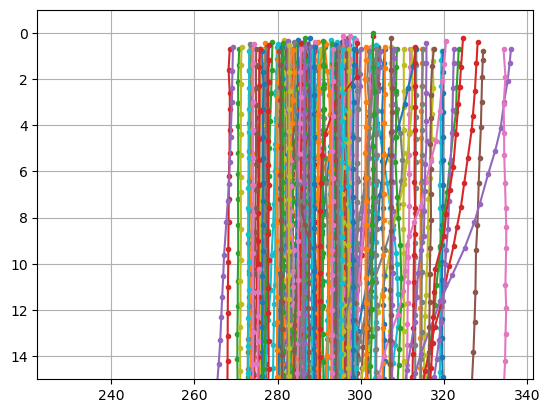

In [104]:
ax1 = plt.subplot(1, 1, 1)
var = 'DOXY'
var_type = '_ADJUSTED_BGCArgoPlus'

for prof in np.arange(0,len(argo_n['N_PROF'])):
    data_p = argo_n[var + var_type].isel(N_PROF=prof)
    pres = argo_n['PRES' + var_type].isel(N_PROF=prof)
    msk = np.isfinite(data_p) & np.isfinite(pres)
    ax1.plot(data_p[msk], pres[msk], marker='.', label=f'{prof}')
ax1.set_ylim([15, -1])
ax1.grid('on')
# ax1.set_xlim([195,225])
# ax1.legend()

In [30]:
argo_n['PLATFORM_TYPE'][0].values.item().decode('utf-8').strip()

'PROVOR_III'

In [9]:
all_float_wmo_ids

[array(6901519)]

In [22]:
# for each profile, check upper values against 5-20db mean
pressure_bin_checks = [7, 4, 2, 0, -2]
reference_pressure = [12,7]
var = 'DOXY'
var_type = '_ADJUSTED_BGCArgoPlus'

# create a pandas dataframe to keep statistics for each float

float_stats_df = pd.DataFrame(columns=['WMO_ID', 'Pressure Bin', 'Mean Difference', 'STD Difference', 'Median Difference','Project', 'Platform Type'])

for f_idx, file in enumerate(tqdm(argolist)):
    # file = '6901519_Sprof_flags_mode_only.nc'

    argo_n = xr.open_dataset(output_dir + file)
    # check that variable exists
    if var + var_type not in argo_n.keys():
        argo_n.close()
        continue
    stored_diffs = np.zeros((len(pressure_bin_checks)-1, len(argo_n['N_PROF'])))
    stored_diffs[:] = np.nan
    for prof in np.arange(0,len(argo_n['N_PROF'])):
        for idx, pressure_bin in enumerate(pressure_bin_checks[:-1]):
            data_p = argo_n[var + var_type].isel(N_PROF=prof)
            pres = argo_n['PRES' + var_type].isel(N_PROF=prof)
            # msk = np.isfinite(data_p) & np.isfinite(pres)
            var_depth = data_p.where(pres<=pressure_bin_checks[idx]).where(pres>pressure_bin_checks[idx+1]).mean().values
            var_reference = data_p.where(pres<=reference_pressure[0]).where(pres>=reference_pressure[1]).mean().values
            stored_diffs[idx, prof] = np.abs(var_depth - var_reference)

    # print(var_depth)
    # print(var_reference)

    # statistics for each float
    for idx, pressure_bin in enumerate(pressure_bin_checks[:-1]):
        if np.isnan(stored_diffs[idx,:]).all():
            mean,std,median = np.nan, np.nan, np.nan
        else:
            mean = np.nanmean(stored_diffs[idx,:])
            std = np.nanstd(stored_diffs[idx,:])
            median = np.nanmedian(stored_diffs[idx,:])
        # add wmo, mean, std,median to dataframe for each pressure bin
        float_stats_df.loc[len(float_stats_df)] = {'WMO_ID': argo_n['WMO_ID'].values,
                                                'Pressure Bin': f'{pressure_bin_checks[idx+1]}-{pressure_bin_checks[idx]} dbar',
                                                'Mean Difference': mean,
                                                'STD Difference': std,
                                                'Median Difference': median,
                                                'Project': argo_n['PROJECT_NAME'][0].values.item().decode('utf-8').strip(),
                                                'Platform Type': argo_n['PLATFORM_TYPE'][0].values.item().decode('utf-8').strip()}

    argo_n.close()
    # if f_idx==10:
    #     break
float_stats_df




100%|██████████| 2229/2229 [1:54:13<00:00,  3.07s/it]  


,WMO_ID,Pressure Bin,Mean Difference,STD Difference,Median Difference,Project,Platform Type
0,6901437,4-7 dbar,0.102615,0.113755,0.076050,RemOcean,PROVOR_III
1,6901437,2-4 dbar,0.141413,0.167604,0.086609,RemOcean,PROVOR_III
2,6901437,0-2 dbar,0.177605,0.190029,0.125641,RemOcean,PROVOR_III
3,6901437,-2-0 dbar,NaN,NaN,NaN,RemOcean,PROVOR_III
4,5906027,4-7 dbar,0.384881,1.005935,0.124146,"UW, Argo",APEX
...,...,...,...,...,...,...,...
8907,5905984,-2-0 dbar,NaN,NaN,NaN,"UW, SOCCOM, Argo equivalent",APEX
8908,3902608,4-7 dbar,NaN,NaN,NaN,CROSSROAD,ARVOR_D
8909,3902608,2-4 dbar,NaN,NaN,NaN,CROSSROAD,ARVOR_D
8910,3902608,0-2 dbar,NaN,NaN,NaN,CROSSROAD,ARVOR_D


In [26]:
float_stats_df.to_csv(manuscript_dir + 'Dataset paper group folder/Data/' + 'float_upper_depth_vs_10m_' + var + plot_ver + '.csv', index=False )


-2-0 dbar
0-2 dbar
2-4 dbar
4-7 dbar


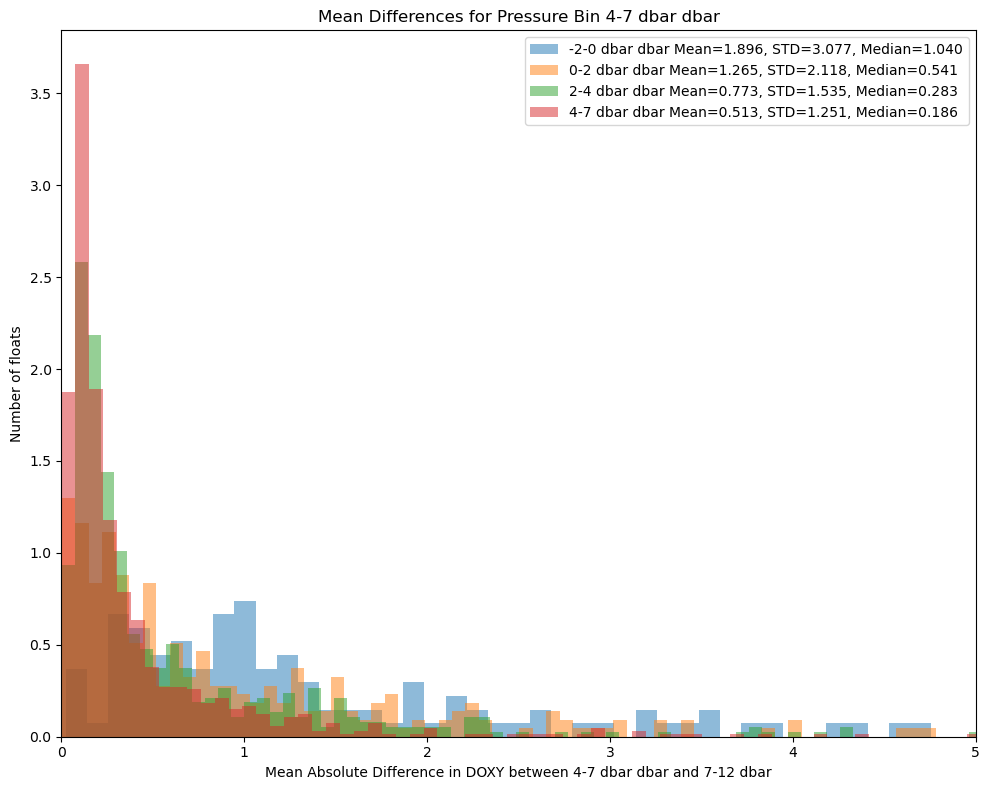

In [25]:
plt.figure(figsize=(10,8))

for pressure_grp in pressure_groups:
    print(pressure_grp[0])
    grp_df = pressure_grp[1]
    mean_all = np.nanmean(grp_df['Mean Difference'])
    std_all = np.nanstd(grp_df['Mean Difference'])
    median_all = np.nanmedian(grp_df['Mean Difference'])
    plt.hist(grp_df['Mean Difference'], bins=250, alpha=0.5, label=f'{pressure_grp[0]} dbar Mean={mean_all:.3f}, STD={std_all:.3f}, Median={median_all:.3f}', density=True)
plt.title(f'Mean Differences for Pressure Bin {pressure_grp[0]} dbar')
plt.legend()
plt.xlabel(f'Mean Absolute Difference in {var} between {pressure_grp[0]} dbar and {reference_pressure[1]}-{reference_pressure[0]} dbar')
plt.ylabel('Number of floats')
plt.xlim([0, 5])
plt.tight_layout()
plt.savefig(manuscript_figs + f'{var}_mean_differences_pressure_bin_{pressure_grp[0].replace(" ","").replace("-","_").replace("dbar","")}.png')
    # plt.close()

Pressure Bin: 4-7 dbar
Project Counts:
Project
UW, SOCCOM, Argo equivalent    222
US ARGO PROJECT                186
UW, GO-BGC                      86
Argo Australia                  62
GO-BGC, WHOI                    52
                              ... 
Argo UK                          1
UW, GOBGC, Argo equivalent       1
GMMC - GEOVIDE                   1
Bioargo-Italy                    1
PERSEUS                          1
Name: count, Length: 84, dtype: int64
Platform Type Counts:
Platform Type
APEX            738
PROVOR_III      117
PROVOR           88
NAVIS_EBR        82
NAVIS_A          65
ARVOR_D          53
PROVOR_IV        18
ARVOR            12
NOVA              5
SOLO_W            4
SOLO_BGC          4
SOLO_BGC_MRV      1
Name: count, dtype: int64
 
Pressure Bin: 2-4 dbar
Project Counts:
Project
UW, SOCCOM, Argo equivalent    87
US ARGO PROJECT                86
GO-BGC, WHOI                   50
Argo Australia                 39
remOcean                       33
         

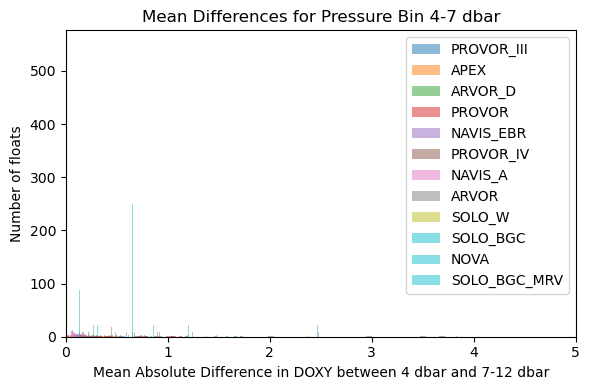

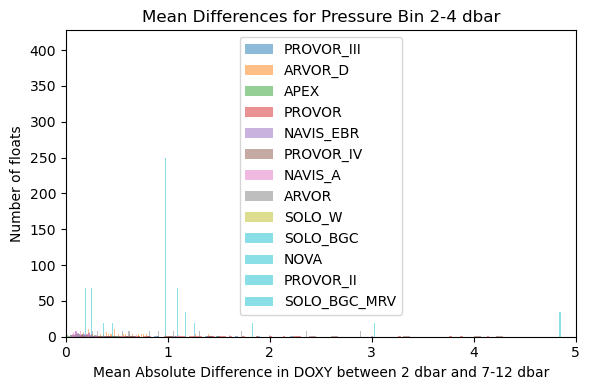

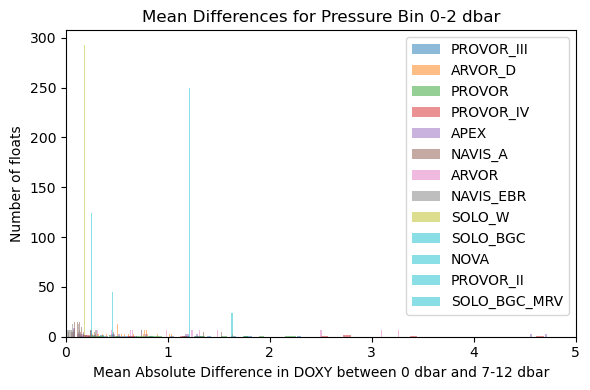

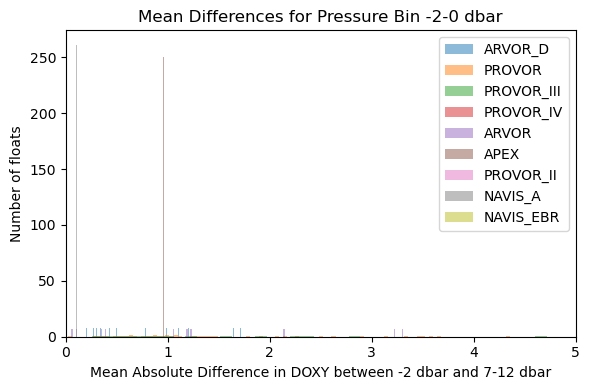

In [32]:
# get counts of each project and platform type with non-nan mean differences for pressure_bin in pressure_bin_checks[:-1]:
pressure_groups = []
for pressure_bin in pressure_bin_checks[:-1]:
    grp_df = float_stats_df.where(float_stats_df['Pressure Bin']==f'{pressure_bin_checks[pressure_bin_checks.index(pressure_bin)+1]}-{pressure_bin} dbar').dropna(how='all')
    grp_df = grp_df.where(~np.isnan(grp_df['Mean Difference'])).dropna(how='all')
    pressure_groups.append((pressure_bin, grp_df))
    print(f'Pressure Bin: {pressure_bin_checks[pressure_bin_checks.index(pressure_bin)+1]}-{pressure_bin} dbar')
    print('Project Counts:')
    print(grp_df['Project'].value_counts())
    print('Platform Type Counts:')
    print(grp_df['Platform Type'].value_counts())
    print(' ')
    # save counts to a csv file
    counts_df = pd.DataFrame({
        'Project': grp_df['Project'].value_counts(),
        'Platform Type': grp_df['Platform Type'].value_counts()
    })
    counts_df.to_csv(manuscript_figs + f'{var}_counts_pressure_bin_{pressure_bin_checks[pressure_bin_checks.index(pressure_bin)+1]}_{pressure_bin}.csv')
    fig = plt.figure(figsize=(6,4))
    color_map = plt.get_cmap('tab10')
    for idx, platform_type in enumerate(grp_df['Platform Type'].unique()):
        platform_mask = grp_df['Platform Type']==platform_type
        plt.hist(grp_df['Mean Difference'][platform_mask], bins=250, alpha=0.5, label=f'{platform_type}', density=True, color=color_map(idx))
    plt.title(f'Mean Differences for Pressure Bin {pressure_bin_checks[pressure_bin_checks.index(pressure_bin)+1]}-{pressure_bin} dbar')
    plt.legend()
    plt.xlabel(f'Mean Absolute Difference in {var} between {pressure_bin_checks[pressure_bin_checks.index(pressure_bin)+1]} dbar and {reference_pressure[1]}-{reference_pressure[0]} dbar')
    plt.ylabel('Number of floats')
    plt.xlim([0, 5])
    plt.tight_layout()
    plt.savefig(manuscript_figs + f'{var}_mean_differences_pressure_bin_{pressure_bin_checks[pressure_bin_checks.index(pressure_bin)+1]}_{pressure_bin}.png')
    # plt.close()

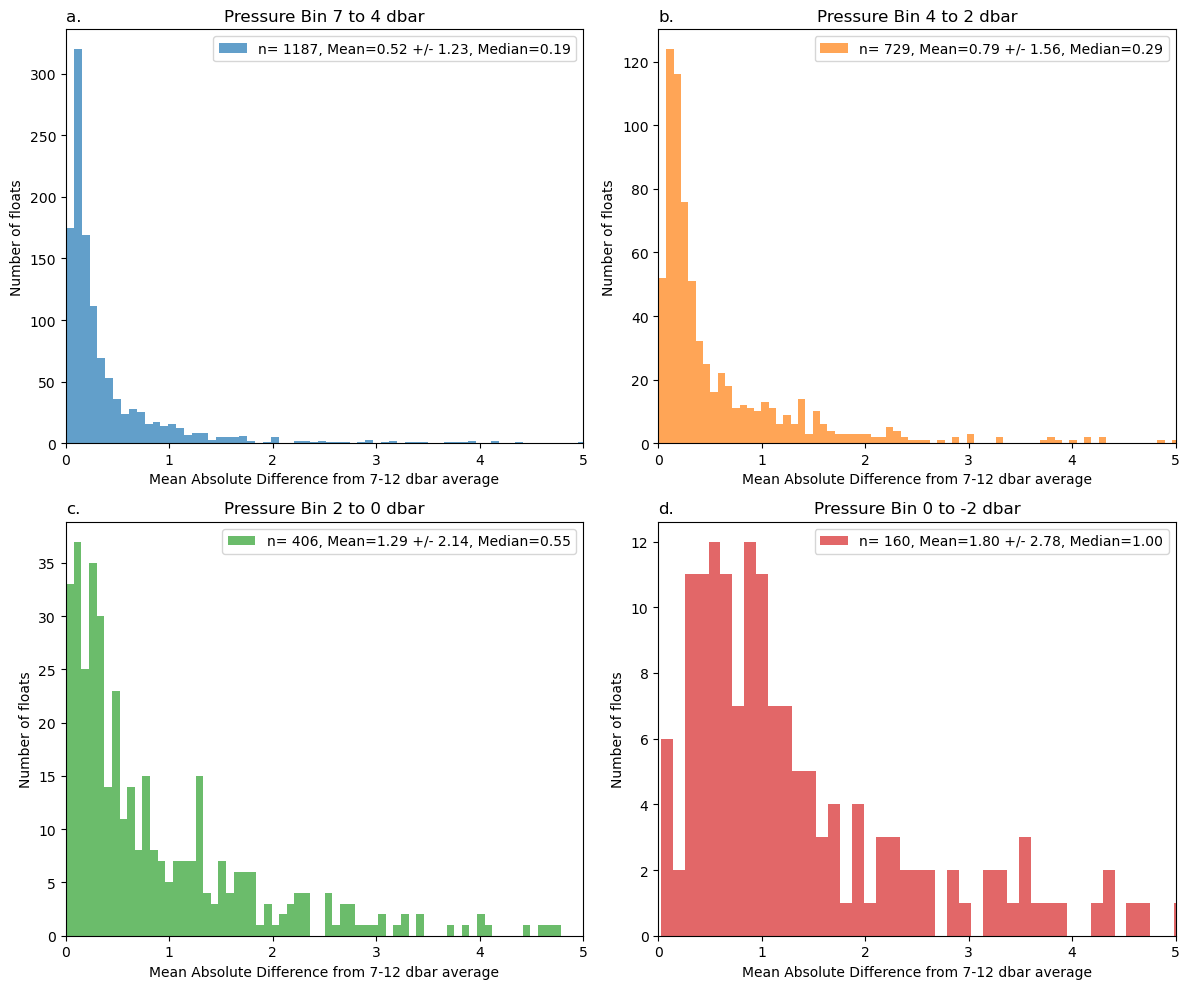

In [63]:
# find which projects and platform types have non-nan data in the different pressure bins with counts
pressure_groups = []
for pressure_bin in pressure_bin_checks[:-1]:
    grp_df = float_stats_df.where(float_stats_df['Pressure Bin']==f'{pressure_bin_checks[pressure_bin_checks.index(pressure_bin)+1]}-{pressure_bin} dbar').dropna(how='all')
    pressure_groups.append((pressure_bin, grp_df))
fig = plt.figure(figsize=(12,10))
plot_count = 0
for pressure_grp in pressure_groups:
    plot_count+=1
    plt.subplot(2,2,plot_count)
    grp_df = pressure_grp[1]
    mean_all = np.nanmean(grp_df['Mean Difference'])
    std_all = np.nanstd(grp_df['Mean Difference'])
    median_all = np.nanmedian(grp_df['Mean Difference'])
    plt.hist(grp_df['Mean Difference'], bins=250, alpha=0.7, label=f'n= {grp_df['Mean Difference'].dropna().count()}, Mean={mean_all:.2f} +/- {std_all:.2f}, Median={median_all:.2f}', density=False, color='C'+str(plot_count-1))
    plt.title(f'Pressure Bin {pressure_grp[0]} to {pressure_bin_checks[pressure_bin_checks.index(pressure_grp[0])+1]} dbar')
    plt.legend()
    plt.xlabel(f'Mean Absolute Difference from {reference_pressure[1]}-{reference_pressure[0]} dbar average')
    plt.ylabel('Number of floats')
    plt.xlim([0, 5])
    if plot_count==1:
        plt.title('a.', loc='left')
    elif plot_count==2:
        plt.title('b.', loc='left')
    elif plot_count==3: 
        plt.title('c.', loc='left')
    elif plot_count==4:
        plt.title('d.', loc='left')
plt.tight_layout()
plt.savefig(manuscript_figs + f'{var}_mean_differences_all_pressure_bins.png')


In [61]:
grp_df['Mean Difference'].dropna().count()

np.int64(160)

In [ ]:
pressure_bin_checks[pressure_bin_checks.index(pressure_grp[0])+1]

0

In [40]:
argo_n['PRES_ADJUSTED_BGCArgoPlus'].values

array([[  15.,   25.,   35., ...,   nan,   nan,   nan],
       [   0.,    6.,   16., ..., 1985.,   nan,   nan],
       [   0.,    6.,   16., ..., 1989., 2002.,   nan],
       ...,
       [   0.,    6.,   16., ..., 1978.,   nan,   nan],
       [   0.,    6.,   16., ..., 1989., 2002.,   nan],
       [   0.,    6.,   16., ..., 1988., 2014.,   nan]],
      shape=(125, 113), dtype=float32)

In [16]:
float_stats_df.loc[len(float_stats_df)] = {'WMO_ID': argo_n['WMO_ID'].values,
                                            'Pressure Bin': f'{pressure_bin_checks[idx+1]}-{pressure_bin_checks[idx]} dbar',
                                            'Mean Difference': mean,
                                            'STD Difference': std,
                                            'Median Difference': median}

In [17]:
float_stats_df

,WMO_ID,Pressure Bin,Mean Difference,STD Difference,Median Difference
0,6901519,4-7 dbar,0.563256,1.111401,0.143555


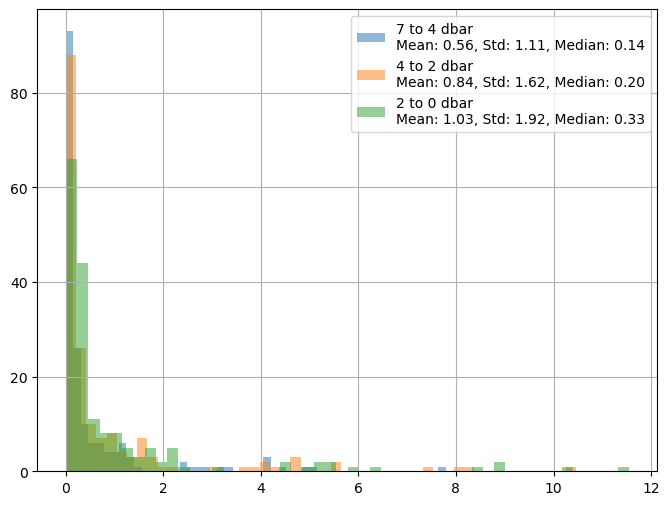

In [8]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1,1)
for idx, pressure_bin in enumerate(pressure_bin_checks[:-1]):
    if np.isnan(stored_diffs[idx,:]).all():
        continue
    mean = np.nanmean(stored_diffs[idx,:])
    std = np.nanstd(stored_diffs[idx,:])
    median = np.nanmedian(stored_diffs[idx,:])
    ax.hist(stored_diffs[idx,:], bins=50, alpha=0.5, label=f'{pressure_bin} to {pressure_bin_checks[idx+1]} dbar \nMean: {mean:.2f}, Std: {std:.2f}, Median: {median:.2f}')

ax.legend()
ax.grid('on')

In [45]:
data_p[0:100].values

array([219.75919, 218.23251,       nan, 219.05525,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
       220.92978,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan, 221.1669 ,       nan,       nan,
             nan,       nan,       nan,       nan, 221.64944, 221.78024,
             nan,       nan,       nan,       nan,       nan,       nan,
       222.47482,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan, 223.61345,       nan,       nan,
             nan,       nan, 224.68146,       nan,       nan,       nan,
             nan,       nan,       nan, 227.04904,       nan,       nan,
             nan,       nan,       nan,       nan, 228.17027,       nan,
             nan,       nan,       nan, 228.34462,       nan, 228.87944,
             nan, 229.33609,       nan, 229.74014, 230.41692, 231.13557,
             nan, 231.79984,       nan, 232.72954, 

In [49]:
pres.where((pres<=reference_pressure[0]))[0:100].values

array([-0.6 ,  0.3 ,  0.6 ,  0.8 ,  1.  ,  1.1 ,  1.2 ,  1.3 ,  1.5 ,
        1.6 ,  1.7 ,  1.8 ,  2.  ,  2.1 ,  2.2 ,  2.3 ,  2.4 ,  2.5 ,
        2.7 ,  2.8 ,  2.9 ,  3.  ,  3.2 ,  3.4 ,  3.5 ,  3.6 ,  3.7 ,
        3.8 ,  3.9 ,  4.1 ,  4.3 ,  4.4 ,  4.5 ,  4.6 ,  4.7 ,  4.8 ,
        5.  ,  5.1 ,  5.2 ,  5.3 ,  5.4 ,  5.5 ,  5.6 ,  5.7 ,  5.8 ,
        5.92,  6.1 ,  6.2 ,  6.3 ,  6.4 ,  6.6 ,  6.7 ,  6.9 ,  7.2 ,
        7.3 ,  7.5 ,  7.7 ,  7.9 ,  8.  ,  8.22,  8.4 ,  8.5 ,  8.9 ,
        9.  ,  9.2 ,  9.4 ,  9.6 ,  9.7 , 10.  , 10.1 , 10.5 , 10.9 ,
       11.5 , 11.8 , 12.5 , 12.6 , 13.4 , 14.2 , 14.5 , 14.9 ,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan], dtype=float32)

In [53]:
data_p.where(pres<=reference_pressure[0]).where(pres>=reference_pressure[1]).mean().values

array(227.97014, dtype=float32)

# Old

['Variable', 'Manual Removal', 'Surface Removal', 'Density Inversion', 'Bottom_Oxygen_Check']


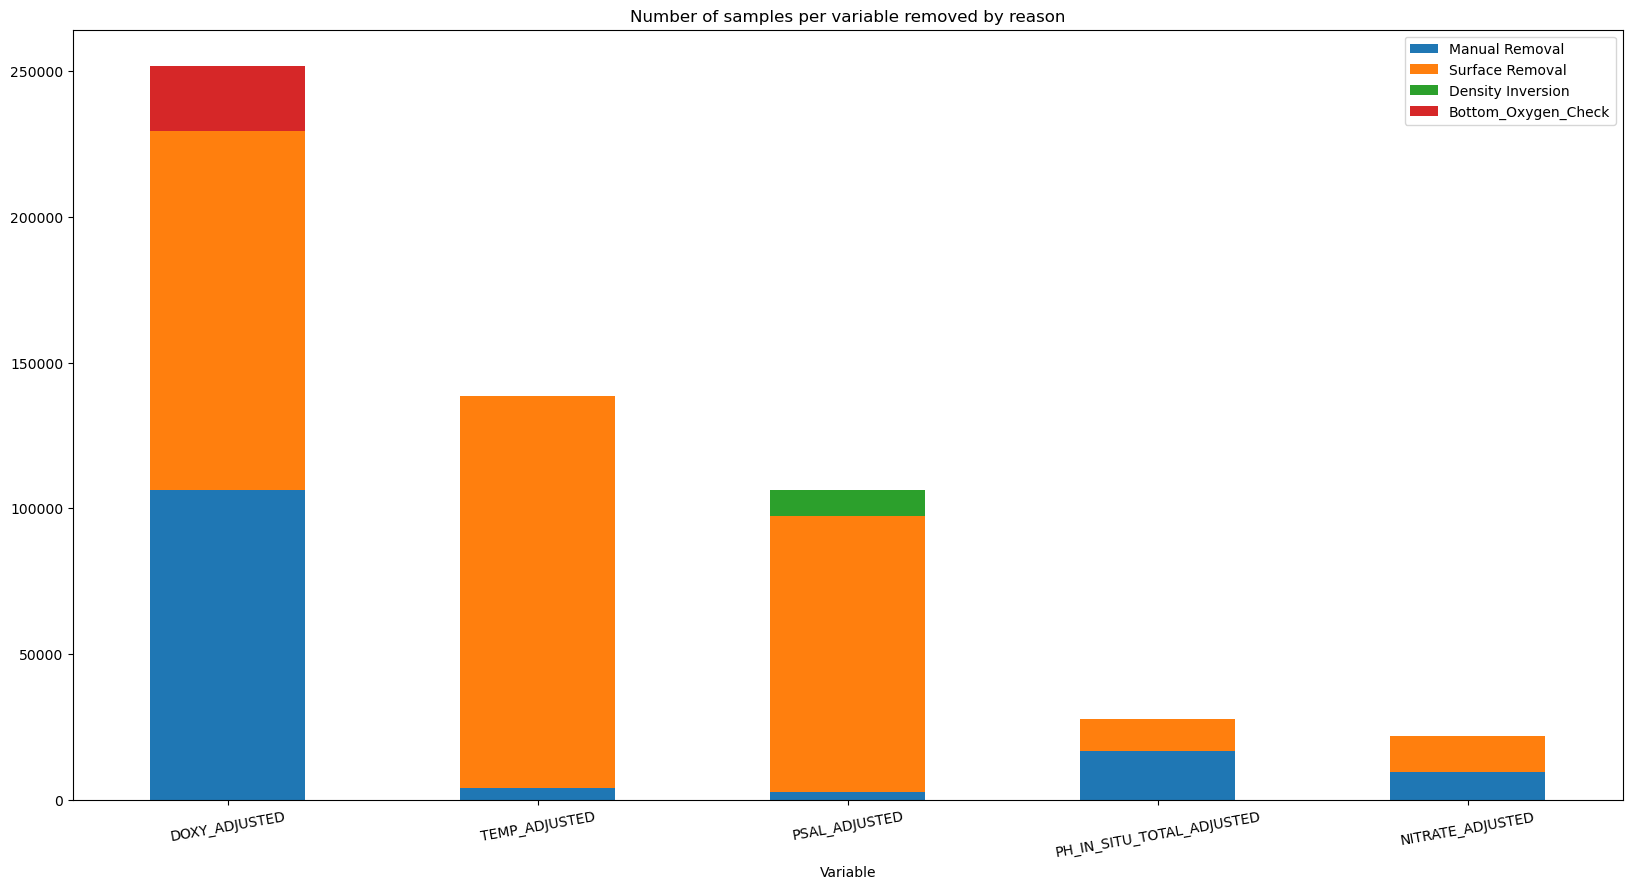

In [ ]:
# number of variables removed by reason

fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(1,1,1)
total_outlier_counts_by_variable = cleaned_outlier_df["Variable"].value_counts()

variables_removed = total_outlier_counts_by_variable.keys().tolist()
trimmed_variables_removed = []
for var in variables_removed:
    if var.endswith('_RO'):
        var = var[:-3]
        # print(var)
        trimmed_variables_removed.append(var)

    elif var.endswith('_BGCArgoPlus'): 
        var = var[:-12]
        # print(var)
        trimmed_variables_removed.append(var)
    elif var.endswith('_ADJUSTED'): 
        trimmed_variables_removed.append(var)

trimmed_variables_removed = list(set(trimmed_variables_removed))  # Remove duplicates

deletion_reasons = cleaned_outlier_df['Deletion reason'].unique()
column_labels = []
column_labels.append('Variable')
for d in range(0, len(deletion_reasons)):
    column_labels.append(deletion_reasons[d])
print(column_labels)


reasons = np.zeros((len(trimmed_variables_removed), len(deletion_reasons)))
for idx, var in enumerate(trimmed_variables_removed):
    # variable_outliers = cleaned_outlier_df['Deletion reason'][cleaned_outlier_df['Variable']==trimmed_variables_removed[idx]].value_counts()
    variable_outliers = cleaned_outlier_df['Deletion reason'][np.logical_or(cleaned_outlier_df['Variable']==trimmed_variables_removed[idx] + '_RO',
                                                    cleaned_outlier_df['Variable']==trimmed_variables_removed[idx] + '_BGCArgoPlus')].value_counts()
    outlier_types = variable_outliers.keys()

    for idx_r, reason in enumerate(deletion_reasons):
        if reason in outlier_types:
            reasons[idx, idx_r] = variable_outliers[reason]
    

temp = []
temp.append(trimmed_variables_removed[0])
for i in range(reasons.shape[1]):
    temp.append(reasons[0,i])
df_bar = pd.DataFrame([temp], columns=column_labels)
# pd.concat
for v in range(1, len(trimmed_variables_removed)):
    temp = []
    temp.append(trimmed_variables_removed[v])
    for i in range(reasons.shape[1]):
        temp.append(reasons[v,i])
    df_bar_n = pd.DataFrame([temp], columns=column_labels)
    df_bar = pd.concat((df_bar, df_bar_n))

df_bar['Total'] = df_bar.iloc[:, 1:].sum(axis=1)  # Sum all columns except 'Variable'
df_bar = df_bar.sort_values(by='Total', ascending=False)
df_bar = df_bar.drop(columns=['Total'])  # Remove the helper column

df_bar.plot(x='Variable', kind='bar', stacked=True, title='Number of samples per variable removed by reason', ax=ax, rot=10)
# df_bar.plot(x='Variable', kind='bar', stacked=True, title='Number of samples per variable removed by reason', ax=ax, rot=20)
fig.savefig(manuscript_figs + 'variables_removed_by_reason' + plot_ver + '.png')

In [ ]:
# # create a version of the outliers removed dataframe that removes the 'RO' and 'BGCArgoPlus' suffixes for variable names
# cleaned_outlier_df['Variable_base'] = cleaned_outlier_df['Variable']
# variables_base = []
# for idx, var in enumerate(cleaned_outlier_df['Variable'].values):
#     if var.endswith('_RO'):
#         var = var[:-3]
#         # print(var)
#         variables_base.append(var)

#     elif var.endswith('_BGCArgoPlus'): 
#         var = var[:-12]
#         # print(var)
#         variables_base.append(var)
#     else:
#         variables_base.append(var)
# cleaned_outlier_df['Variable_base'] = variables_base
# cleaned_outlier_df

,Float Number,Variable,N_PROF,Date,N_LEVELS,Pressure (dbar),Deletion reason,Variable_short,Variable_base
0,1900650.0,PSAL_ADJUSTED,74.0,2008-08-09 00:09:20.736,55.0,798.799988,Manual Removal,PSAL_ADJUSTED,PSAL_ADJUSTED
4,1900651.0,PSAL_ADJUSTED_RO,41.0,2007-09-01 18:48:46.368,18.0,89.500000,Manual Removal,PSAL_ADJUSTED,PSAL_ADJUSTED
5,1900651.0,PSAL_ADJUSTED_RO,42.0,2007-09-11 20:19:12.288,13.0,59.400002,Manual Removal,PSAL_ADJUSTED,PSAL_ADJUSTED
6,1900651.0,PSAL_ADJUSTED_RO,91.0,2009-01-13 20:29:51.648,0.0,4.700000,Manual Removal,PSAL_ADJUSTED,PSAL_ADJUSTED
7,1900651.0,PSAL_ADJUSTED_RO,91.0,2009-01-13 20:29:51.648,1.0,6.600000,Manual Removal,PSAL_ADJUSTED,PSAL_ADJUSTED
...,...,...,...,...,...,...,...,...,...
610589,7902112.0,TEMP_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,0.0,0.900000,Surface Removal,TEMP_ADJUSTED,TEMP_ADJUSTED
610590,7902112.0,TEMP_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,1.0,1.800000,Surface Removal,TEMP_ADJUSTED,TEMP_ADJUSTED
610591,7902112.0,PSAL_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,0.0,0.900000,Surface Removal,PSAL_ADJUSTED,PSAL_ADJUSTED
610592,7902112.0,PSAL_ADJUSTED_BGCArgoPlus,33.0,2024-12-26 00:43:09,1.0,1.800000,Surface Removal,PSAL_ADJUSTED,PSAL_ADJUSTED


In [ ]:
### Plotting of processed figures

In [ ]:
# Plotting summary figures for each float
from importlib import reload
reload(fl_flags)

num_processes = 18

# plot_vars_all = ['TEMP_ADJUSTED', 'PSAL_ADJUSTED', 'sigma0', 'gamma', 'DOXY_ADJUSTED', 'NITRATE_ADJUSTED', 
#                  'PH_IN_SITU_TOTAL_ADJUSTED', 'TALK_LIAR', 'DIC', 'CHLA_ADJUSTED', 'BBP700_ADJUSTED', 'CDOM_ADJUSTED',
#                  'DOWNWELLING_PAR_ADJUSTED', 'DOWN_IRRADIANCE380_ADJUSTED', 'DOWN_IRRADIANCE412_ADJUSTED', 'DOWN_IRRADIANCE490_ADJUSTED',
#                  'CP660_ADJUSTED']
# plot Sprof files
# output_dir = sprof_path # non-interpolated files
# file_string = 'Sprof.nc'

# plot processed files
output_dir = output_dir # non-interpolated files
file_string = 'Sprof_processed.nc'
# get list of filtered files saved out
processed_list = []
for file in os.listdir(output_dir):
    if file.endswith(file_string):
        processed_list.append(file)

print(len(processed_list))

NameError: name 'fl_flags' is not defined

In [ ]:

if __name__ == "__main__":
    
    with Pool(processes=num_processes) as pool:
        # Create a list of arguments for pool.starmap
        plot_args = [(file, output_dir, processed_fig_dir) for n, file in enumerate(processed_list)]
        
        # Use pool.starmap with the list of arguments
        pool.starmap(fl_flags.plot_processed_files, plot_args)
    


## Plotting of outliers removed

In [ ]:
def outlier_plotting(argo_n, output_dir, matched_file_list, verbose):

    reviewer_symbols = ['xr', 'ob', '+k', '^m', 'sg']
    group_outlier_dir= output_dir+ '../outlier_file_collection/'
    # print(argo_file[:7])

    wmo_n = str(argo_n['WMO_ID'].values)

    # wmo = argo_file[:7]
    # find all outlier files that match the WMO, if any
    # matched_file_list = [outlier_file for outlier_file in outlier_files if np.logical_and(wmo_n in outlier_file, not os.path.isdir(group_outlier_output_dir+ outlier_file))]
    # print(matched_file_list)

    # if len(matched_file_list)> 0: # only apply outliers if any are found 
    # argo_n = xr.open_dataset(output_output_dir+ argo_file)
    # create a copy to use for plotting removed points
    argo_n_orig = argo_n.copy(deep=True)

    outliers_removed = False
    # open all outlier files that match the WMO
    for file_n in matched_file_list: 
        if verbose:
            print('Looking at contents of outlier file ' + file_n)
        # file_n = matched_file_list[o]
        # print(file_n)
        with open(group_outlier_dir+file_n) as csvfile:
            df_out = pd.read_csv(csvfile)

            var = df_out['Variable'].values
            nprof = df_out['N_PROF'].values
            nlevel = df_out['N_LEVELS'].values

            if len(nprof) > 0: 
                df_out['reviewer_initials'] = file_n.split('_')[4]
                if 'df_all' in locals():
                    df_all = pd.concat([df_all, df_out])
                else:
                    df_all = df_out

                outliers_removed=True # sets to True if any values are being changed
                # for i in range(0, len(nprof)): # go through each row, setting all values to nans
                #     # Replace the data with nans
                #     if type(var[i])==str:
                #         argo_n[var[i]].loc[{'N_PROF':int(nprof[i]), 'N_LEVELS':int(nlevel[i])}] = np.nan

    # if there were outliers removed and plot_changes is set to True, then plot profiles that were removed     
    if outliers_removed:

        # make a removed profile directory for this float if one doesn't exist
        float_RO_profile_dir= group_outlier_dir+ '/' + wmo_n + '/'
        if not os.path.isdir(float_RO_profile_dir):
            os.mkdir(float_RO_profile_dir)

        outlier_profiles = np.sort(df_all['N_PROF'].unique())
        for idx_p in range(0, len(outlier_profiles)):
            if np.isnan(outlier_profiles[idx_p]):
                continue 
            plot_filename = wmo_n + '_profile_' +  str(outlier_profiles[idx_p])

            prof_index = df_all['N_PROF']==outlier_profiles[idx_p]
            var_all = df_all['Variable'][prof_index]
            unique_variables = np.unique(var_all).tolist()
            if 'TEMP_ADJUSTED_RO' not in unique_variables:
                unique_variables.append('TEMP_ADJUSTED_RO')
            if 'PSAL_ADJUSTED_RO' not in unique_variables:
                unique_variables.append('PSAL_ADJUSTED_RO')                
            unique_reviewers = np.unique(df_all['reviewer_initials'])

            fig = plt.figure(figsize=(len(unique_variables)*10,10),)

            for idx_v in range(0, len(unique_variables)):


                # loop through all removed variables types for that profile
                # first plot that profile, plus ones before and after:
                ax = fig.add_subplot(1, len(unique_variables), idx_v+1)

                # make sure we don't exceed the limits of available profiles
                first_profile = int(outlier_profiles[idx_p]-2)
                last_profile = int(outlier_profiles[idx_p]+3)
                if first_profile<0:
                    first_profile=0
                if last_profile>len(argo_n_orig['N_PROF'].values)-1:
                    last_profile = argo_n_orig['N_PROF'][-1].values

                for prof_plot in range(first_profile,last_profile):
                    # print(prof_plot)
                    ax.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':prof_plot}].values, \
                        argo_n_orig['PRES'].loc[{'N_PROF':prof_plot}].values, label = prof_plot)
                    
                # plt.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':outlier_profiles[idx_p]}].values, \
                #          argo_n_orig['PRES'].loc[{'N_PROF':outlier_profiles[idx_p]}].values, label =)
                ax.set_title(unique_variables[idx_v] + ' Profile: ' + str(outlier_profiles[idx_p]))

                # plot removed variables:

                df_prof_var = df_all[prof_index].where(df_all['Variable'][prof_index]==unique_variables[idx_v]) 
                df_prof_var = df_prof_var.drop_duplicates().dropna(how='all').reset_index()

                # add an index item for the reviewers present in the profile
                prof_reviewers = np.unique(df_prof_var['reviewer_initials'])
                for pr in range(0, len(prof_reviewers)):
                    reviewer_match = unique_reviewers==prof_reviewers[pr]
                    rev_index = [i for i, x in enumerate(reviewer_match) if x] # get an index for the reviewer so that you have different legend values 

                    ax.plot(np.nan, np.nan, reviewer_symbols[rev_index[0]], label=unique_reviewers[rev_index])
                label=df_prof_var['reviewer_initials']
                # loop through rows and plot outlier points
                for RO_n in range(0, len(df_prof_var)):
                    reviewer_match = unique_reviewers==df_prof_var['reviewer_initials'][RO_n] 
                    rev_index = [i for i, x in enumerate(reviewer_match) if x] # get an index for the reviewer so that you have different legend values 
                    
                    # print(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':outlier_profiles[idx_p], 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values)
                    ax.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':int(outlier_profiles[idx_p]), 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values, \
                        argo_n_orig['PRES'].loc[{'N_PROF':int(outlier_profiles[idx_p]), 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values, reviewer_symbols[rev_index[0]] )
                    
                ax.invert_yaxis()
                ax.legend()
            plt.tight_layout()
            plt.savefig(f'{float_RO_profile_dir}{plot_filename}.png')
            plt.close(fig)
    argo_n_orig.close()
    # # save intermediate file
    # print('here')
    # argo_n.to_netcdf(output_output_dir+ argo_file[:-3] + '_RO.nc')
    # argo_n.close()        
    return


In [ ]:
argolist = []
for file in os.listdir(output_dir):
    if file.endswith('filtered.nc'):
        argolist.append(file)
argolist = np.sort(argolist)

print(str(len(argolist)) + ' files found')

2229 files found


In [ ]:
argolist[0].item()

'1900650_Sprof_filtered.nc'

In [ ]:
argolist[24].item()

'1901214_Sprof_filtered.nc'

In [ ]:
for file in argolist:
    file = argolist[24]


    argo_n = xr.open_dataset(output_dir+ file.item())
    if 'WMO_ID' not in argo_n.keys():
        print('missing wmo id: ' + file)
        break
    wmo_n = argo_n['WMO_ID'].values

    outlier_list = []
    for file in os.listdir(group_outlier_dir):
        if file.endswith('.csv'):
            outlier_list.append(file)
    outlier_list = np.sort(outlier_list)

    outlier_df = pd.read_csv(io.StringIO('\n'.join(outlier_list)), delimiter='_', header=None)
    outlier_df.rename(columns={1: 'wmo', 4:'person', 5:'year', 6:'month', 7:'day', 8:'hour'}, inplace=True)
    # remove all outlier files w/ bottom oxygen
    # outlier_df = outlier_df.where(outlier_df['person']!='bottomoxygen').dropna(how='all')
    # remove all outlier files w/ bottom oxygen
    # outlier_df = outlier_df.where(outlier_df['person']!='automaticoutliers').dropna(how='all')
    # remove all outlier files w/ XXX as the name
    outlier_df = outlier_df.where(outlier_df['person']!='XXX').dropna(how='all')
    matched_df = outlier_df.where(outlier_df['wmo']==wmo_n).dropna(how='all')
    break


In [ ]:
matched_df

,0,wmo,2,3,person,year,month,day,hour
64,outliers,1901214.0,Sprof,filtered,automaticoutliers,XXXX,X,X,X.csv
65,outliers,1901214.0,Sprof,filtered,smb,2025,4,28,15.csv


In [ ]:
if len(matched_df)>0:
    matched_file_list = outlier_list[matched_df.index]
    outlier_plotting(argo_n, output_dir, matched_file_list, verbose=False)

In [ ]:
matched_file_list = outlier_list[matched_df.index]


Looking at contents of outlier file outliers_1901214_Sprof_filtered_automaticoutliers_XXXX_X_X_X.csv
Looking at contents of outlier file outliers_1901214_Sprof_filtered_smb_2025_4_28_15.csv


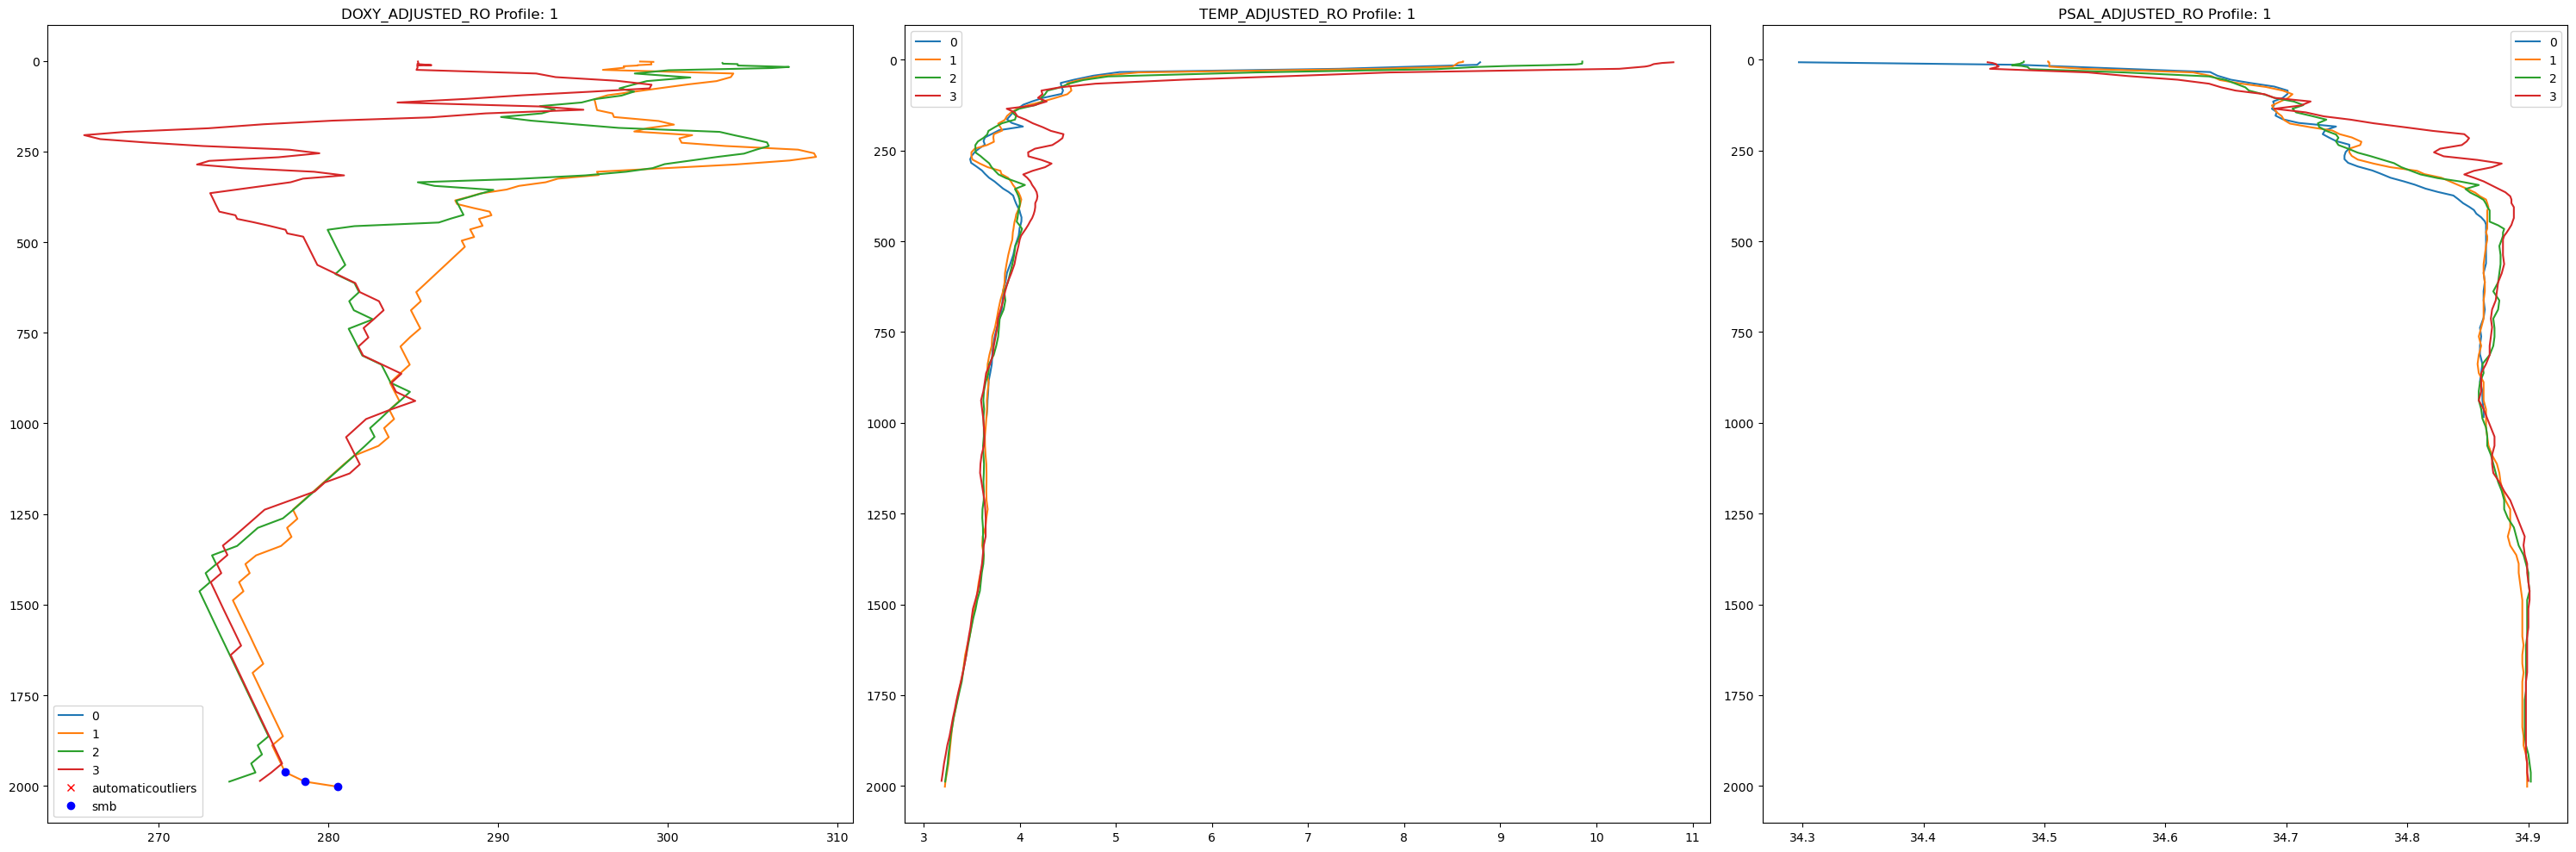

In [ ]:
verbose = True

reviewer_symbols = ['xr', 'ob', '+k', '^m', 'sg']
# print(argo_file[:7])

wmo_n = str(argo_n['WMO_ID'].values)

# wmo = argo_file[:7]
# find all outlier files that match the WMO, if any
# matched_file_list = [outlier_file for outlier_file in outlier_files if np.logical_and(wmo_n in outlier_file, not os.path.isdir(group_outlier_output_dir+ outlier_file))]
# print(matched_file_list)

# if len(matched_file_list)> 0: # only apply outliers if any are found 
# argo_n = xr.open_dataset(output_output_dir+ argo_file)
# create a copy to use for plotting removed points
argo_n_orig = argo_n.copy(deep=True)

outliers_removed = False
# open all outlier files that match the WMO
for file_n in matched_file_list: 
    if verbose:
        print('Looking at contents of outlier file ' + file_n)
    # file_n = matched_file_list[o]
    # print(file_n)
    with open(group_outlier_dir+file_n) as csvfile:
        df_out = pd.read_csv(csvfile)

        var = df_out['Variable'].values
        nprof = df_out['N_PROF'].values
        nlevel = df_out['N_LEVELS'].values

        if len(nprof) > 0: 
            df_out['reviewer_initials'] = file_n.split('_')[4]
            if 'df_all' in locals():
                df_all = pd.concat([df_all, df_out])
            else:
                df_all = df_out

            outliers_removed=True # sets to True if any values are being changed
            # for i in range(0, len(nprof)): # go through each row, setting all values to nans
            #     # Replace the data with nans
            #     if type(var[i])==str:
            #         argo_n[var[i]].loc[{'N_PROF':int(nprof[i]), 'N_LEVELS':int(nlevel[i])}] = np.nan

# if there were outliers removed and plot_changes is set to True, then plot profiles that were removed     
if outliers_removed:

    # make a removed profile directory for this float if one doesn't exist
    float_RO_profile_dir= group_outlier_dir+ '/' + wmo_n + '/'
    if not os.path.isdir(float_RO_profile_dir):
        os.mkdir(float_RO_profile_dir)

    outlier_profiles = np.sort(df_all['N_PROF'].unique())
    # let's plot in 5 profile chunks, with all outliers for each set present. only plot sets of profiles if there are outliers removed. 
    # start with first profile, then do the next 5 profiles, whether or not they have outliers present. If there are outliers, then plot them.
    # make sure you are plotting the "ADJUSTED" not "ADJUSTED_RO" data
    for idx_p in range(0, len(outlier_profiles)):
        if np.isnan(outlier_profiles[idx_p]):
            continue 
        plot_filename = wmo_n + '_profile_' +  str(outlier_profiles[idx_p])

        prof_index = df_all['N_PROF']==outlier_profiles[idx_p]
        var_all = df_all['Variable'][prof_index]
        unique_variables = np.unique(var_all).tolist()
        if 'TEMP_ADJUSTED_RO' not in unique_variables:
            unique_variables.append('TEMP_ADJUSTED_RO')
        if 'PSAL_ADJUSTED_RO' not in unique_variables:
            unique_variables.append('PSAL_ADJUSTED_RO')                
        unique_reviewers = np.unique(df_all['reviewer_initials'])

        fig = plt.figure(figsize=(len(unique_variables)*10,10),)

        for idx_v in range(0, len(unique_variables)):


            # loop through all removed variables types for that profile
            # first plot that profile, plus ones before and after:
            ax = fig.add_subplot(1, len(unique_variables), idx_v+1)

            # make sure we don't exceed the limits of available profiles
            first_profile = int(outlier_profiles[idx_p]-2)
            last_profile = int(outlier_profiles[idx_p]+3)
            if first_profile<0:
                first_profile=0
            if last_profile>len(argo_n_orig['N_PROF'].values)-1:
                last_profile = argo_n_orig['N_PROF'][-1].values

            for prof_plot in range(first_profile,last_profile):
                # print(prof_plot)
                ax.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':prof_plot}].values, \
                    argo_n_orig['PRES'].loc[{'N_PROF':prof_plot}].values, label = prof_plot)
                
            # plt.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':outlier_profiles[idx_p]}].values, \
            #          argo_n_orig['PRES'].loc[{'N_PROF':outlier_profiles[idx_p]}].values, label =)
            ax.set_title(unique_variables[idx_v] + ' Profile: ' + str(outlier_profiles[idx_p]))

            # plot removed variables:

            df_prof_var = df_all[prof_index].where(df_all['Variable'][prof_index]==unique_variables[idx_v]) 
            df_prof_var = df_prof_var.drop_duplicates().dropna(how='all').reset_index()

            # add an index item for the reviewers present in the profile
            prof_reviewers = np.unique(df_prof_var['reviewer_initials'])
            for pr in range(0, len(prof_reviewers)):
                reviewer_match = unique_reviewers==prof_reviewers[pr]
                rev_index = [i for i, x in enumerate(reviewer_match) if x] # get an index for the reviewer so that you have different legend values 

                ax.plot(np.nan, np.nan, reviewer_symbols[rev_index[0]], label=unique_reviewers[rev_index])
            label=df_prof_var['reviewer_initials']
            # loop through rows and plot outlier points
            for RO_n in range(0, len(df_prof_var)):
                reviewer_match = unique_reviewers==df_prof_var['reviewer_initials'][RO_n] 
                rev_index = [i for i, x in enumerate(reviewer_match) if x] # get an index for the reviewer so that you have different legend values 
                
                # print(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':outlier_profiles[idx_p], 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values)
                ax.plot(argo_n_orig[unique_variables[idx_v]].loc[{'N_PROF':int(outlier_profiles[idx_p]), 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values, \
                    argo_n_orig['PRES'].loc[{'N_PROF':int(outlier_profiles[idx_p]), 'N_LEVELS':int(df_prof_var['N_LEVELS'][RO_n])}].values, reviewer_symbols[rev_index[0]] )
                
            ax.invert_yaxis()
            ax.legend()
        plt.tight_layout()
        plt.savefig(f'{float_RO_profile_dir}{plot_filename}.png')
        # plt.close(fig)
        break
    
argo_n_orig.close()

In [6]:
# Count number of floats with each mode and valid data
wmo_list = np.unique(float_mode_df['WMO'])
wmo_list

array([array(1900650), array(1900651), array(1900652), ...,
       array(7902203), array(7902215), array(7902223)],
      shape=(2229,), dtype=object)

In [29]:
### there is a mistake here for some reason ###
idx = 100
wmo_list[100]
floats_w_valid_doxy = 0
floats_w_valid_no3 = 0
floats_w_valid_ph = 0

for idx, wmo in enumerate(tqdm(wmo_list)):
    float_df_n = float_mode_df.where(float_mode_df['WMO']==wmo_list[idx]).dropna(how='all')
    if (float_df_n['DOXY_ADJUSTED_VALID']>0).any():
        floats_w_valid_doxy = floats_w_valid_doxy + 1
    if (float_df_n['NITRATE_ADJUSTED_VALID']>0).any():
        floats_w_valid_no3 = floats_w_valid_no3 + 1
    if (float_df_n['PH_IN_SITU_TOTAL_ADJUSTED_VALID']>0).any():
        floats_w_valid_ph = floats_w_valid_ph + 1

print('n doxy = ' + str(floats_w_valid_doxy))
print('n nitrate = ' + str(floats_w_valid_no3))
print('n pH = ' + str(floats_w_valid_ph))



100%|██████████| 2229/2229 [56:53<00:00,  1.53s/it]    

n doxy = 1892
n nitrate = 715
n pH = 532


In [ ]:
# Why is there a discrepancy between numbers counted above and valid floats considered for outlier detection?
print('number of floats with delayed mode oxygen available')
print(len(np.unique(float_mode_df['WMO'][(float_mode_df['Variable']=='DOXY') & (float_mode_df['Profile Mode']==2)  & (float_mode_df['DOXY_ADJUSTED_VALID']>0)])))

print('number of floats with delayed mode nitrate available')
print(len(np.unique(float_mode_df['WMO'][(float_mode_df['Variable']=='NITRATE') & (float_mode_df['Profile Mode']==2)  & (float_mode_df['NITRATE_ADJUSTED_VALID']>0)])))

print('number of floats with delayed mode pH available')
print(len(np.unique(float_mode_df['WMO'][(float_mode_df['Variable']=='PH_IN_SITU_TOTAL') & (float_mode_df['Profile Mode']==2)  & (float_mode_df['PH_IN_SITU_TOTAL_ADJUSTED_VALID']>0)])))


In [62]:
# get list of wmos with "XXX" files and compare to list of WMOs w valid DOXY
outlier_list = []
for file in os.listdir(group_outlier_dir):
    if file.endswith('.csv'):
        outlier_list.append(file)
outlier_list = np.sort(outlier_list)

# print(len(outlier_list))

import io 

outlier_df = pd.read_csv(io.StringIO('\n'.join(outlier_list)), delimiter='_', header=None)
outlier_df.rename(columns={1: 'wmo', 4:'person', 5:'year', 6:'month', 7:'day', 8:'hour'}, inplace=True)

# remove all "bottomoxygen" files from the outlier_df:
outlier_df = outlier_df.where(outlier_df['person']!='bottomoxygen').dropna(how='all')
# remove all "automaticoutliers" files from the outlier_df:
outlier_df = outlier_df.where(outlier_df['person']!='automaticoutliers').dropna(how='all')

XXX_files = outlier_df.where(outlier_df['person']=='XXX').dropna(how='all')
print(str(len(np.unique(XXX_files['wmo']))) + ' files have missing/non-valid T, S, or BGC data')


843 files have missing/non-valid T, S, or BGC data


In [63]:
wmo_bad_list = np.unique(XXX_files['wmo'])

In [54]:
wmo_good_list = np.unique(float_mode_df['WMO'][(float_mode_df['Variable']=='DOXY') & (float_mode_df['Profile Mode']==2)  & (float_mode_df['DOXY_ADJUSTED_VALID']>0)])

In [64]:
for i in range(0, len(wmo_good_list)):
    if wmo_good_list[i] in wmo_bad_list:
        print(wmo_good_list[i])
        break

In [61]:
XXX_files[wmo_bad_list==wmo_good_list[i]]

,0,wmo,2,3,person,year,month,day,hour
114,outliers,1902368.0,Sprof,filtered,XXX,2025,7,8,12.csv
